# Projet Machine Learning - Analyse exploratoire et modélisation

## Introduction

Ce notebook constitue l'analyse exploratoire et la modélisation en Python du jeu de données Cardiovascular Disease Risk Prediction Dataset (Kaggle).

**Objectif du projet :**
- Classification : prédire la variable `Heart_Disease_Risk` (risque d'accident cardiaque : 0 = faible, 1 = élevé) à partir de toutes les autres variables.
- Régression : prédire la variable `Cholesterol_LDL` ("mauvais" cholestérol) à partir de toutes les autres variables (sauf `Heart_Disease_Risk`).

**Plan de l'analyse exploratoire :**
1. Chargement et vérification des données
2. Analyse univariée (variables quantitatives et qualitatives)
3. Analyse bivariée (corrélations, boxplots, mosaicplots)
4. Analyse en composantes principales (ACP)
5. Synthèse et préparation pour la modélisation

In [1]:
import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from scipy import stats

from sklearn import linear_model
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    AdaBoostClassifier,
    AdaBoostRegressor,
    BaggingClassifier,
    BaggingRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.feature_selection import RFECV, SelectFromModel
from sklearn.linear_model import LassoCV, LinearRegression, LogisticRegression, RidgeCV
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    auc,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.utils import resample

warnings.filterwarnings('ignore')


## 1. Chargement et vérification des données

On commence par charger le jeu de données et vérifier sa structure : dimensions, types des variables, valeurs manquantes. C'est une étape indispensable avant toute analyse.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuration des graphiques
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

# Chargement des données
path = "../divers/"
data = pd.read_csv(path + "healthcare_synthetic_data.csv", sep=",", header=0)
print(f"Dimensions du jeu de données : {data.shape[0]} lignes, {data.shape[1]} colonnes")
data.head()

Dimensions du jeu de données : 15000 lignes, 19 colonnes


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


In [46]:
# Vérification des types et des valeurs manquantes
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               15000 non-null  object 
 1   Age                      15000 non-null  int64  
 2   Gender                   15000 non-null  int64  
 3   Height_cm                15000 non-null  float64
 4   Weight_kg                15000 non-null  float64
 5   BMI                      15000 non-null  float64
 6   Systolic_BP              15000 non-null  int64  
 7   Diastolic_BP             15000 non-null  int64  
 8   Cholesterol_Total        15000 non-null  int64  
 9   Cholesterol_LDL          15000 non-null  int64  
 10  Cholesterol_HDL          15000 non-null  int64  
 11  Fasting_Blood_Sugar      15000 non-null  int64  
 12  Smoking_Status           15000 non-null  int64  
 13  Alcohol_Consumption      15000 non-null  int64  
 14  Physical_Activity_Leve

**Interprétation :**
- 15000 lignes, 19 colonnes : le jeu de données est complet, conforme à la description du sujet.
- Toutes les colonnes affichent `15000 non-null` : aucune valeur manquante, pas besoin d'imputation.
- Les types détectés sont `int64`, `float64` et `str` : pandas interprète tout comme numérique (sauf `Patient_ID`). Les variables qualitatives (`Gender`, `Smoking_Status`, etc.) sont encodées en entiers dans le CSV, il faudra les convertir explicitement en `Categorical` à l'étape suivante.

### Suppression de Patient_ID

La colonne `Patient_ID` est un identifiant unique par patient. Elle n'a aucune valeur prédictive et doit être retirée avant l'analyse.

In [47]:
data = data.drop('Patient_ID', axis=1)

### Conversion des variables qualitatives

Dans le CSV, toutes les variables sont encodées numériquement (0, 1, 2...). Il faut explicitement convertir les variables qualitatives en type `Categorical` pour que pandas les traite correctement (par exemple, `describe()` ne calculera pas de moyenne sur `Gender`).

- Non ordonnées : `Gender`, `Smoking_Status`, `Family_History`, `Heart_Disease_Risk`
- Ordonnées : `Alcohol_Consumption` (0 < 1 < 2, niveaux croissants de consommation) et `Physical_Activity_Level` (0 < 1 < 2 < 3, niveaux croissants d'activité)

In [48]:
data["Gender"] = pd.Categorical(data["Gender"], ordered=False)
data["Smoking_Status"] = pd.Categorical(data["Smoking_Status"], ordered=False)
data["Alcohol_Consumption"] = pd.Categorical(data["Alcohol_Consumption"], ordered=True)
data["Physical_Activity_Level"] = pd.Categorical(data["Physical_Activity_Level"], ordered=True)
data["Family_History"] = pd.Categorical(data["Family_History"], ordered=False)
data["Heart_Disease_Risk"] = pd.Categorical(data["Heart_Disease_Risk"], ordered=False)

# Vérification
print("Types après conversion :")
print(data.dtypes)

Types après conversion :
Age                           int64
Gender                     category
Height_cm                   float64
Weight_kg                   float64
BMI                         float64
Systolic_BP                   int64
Diastolic_BP                  int64
Cholesterol_Total             int64
Cholesterol_LDL               int64
Cholesterol_HDL               int64
Fasting_Blood_Sugar           int64
Smoking_Status             category
Alcohol_Consumption        category
Physical_Activity_Level    category
Family_History             category
Stress_Level                  int64
Sleep_Hours                   int64
Heart_Disease_Risk         category
dtype: object


## 2. Analyse univariée

On explore chaque variable individuellement pour comprendre sa distribution, détecter d'éventuelles anomalies et décider si des transformations sont nécessaires.

### 2.1 Variables quantitatives

On commence par les statistiques descriptives classiques (moyenne, écart-type, quartiles, min, max) puis on visualise les distributions.

In [49]:
data.describe()

,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Stress_Level,Sleep_Hours
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,54.538133,165.336767,75.252573,27.446080,135.117667,90.541267,216.248000,140.355267,43.307867,99.670200,5.503667,6.506067
std,11.875294,9.186313,14.110559,4.134953,11.260634,8.443095,22.692222,17.914089,5.963153,15.261355,2.874277,1.212626
min,25.000000,138.500000,33.700000,14.500000,90.000000,60.000000,127.000000,70.000000,20.000000,60.000000,1.000000,4.000000
25%,46.000000,158.500000,65.200000,24.500000,127.000000,85.000000,201.000000,128.000000,39.000000,89.000000,3.000000,6.000000
50%,55.000000,164.700000,73.900000,27.200000,135.000000,91.000000,216.000000,140.000000,43.000000,99.000000,5.500000,7.000000
75%,63.000000,172.000000,83.900000,30.000000,143.000000,96.000000,231.000000,152.000000,47.000000,110.000000,8.000000,7.000000
max,85.000000,198.100000,150.100000,46.100000,182.000000,120.000000,303.000000,210.000000,68.000000,167.000000,10.000000,10.000000


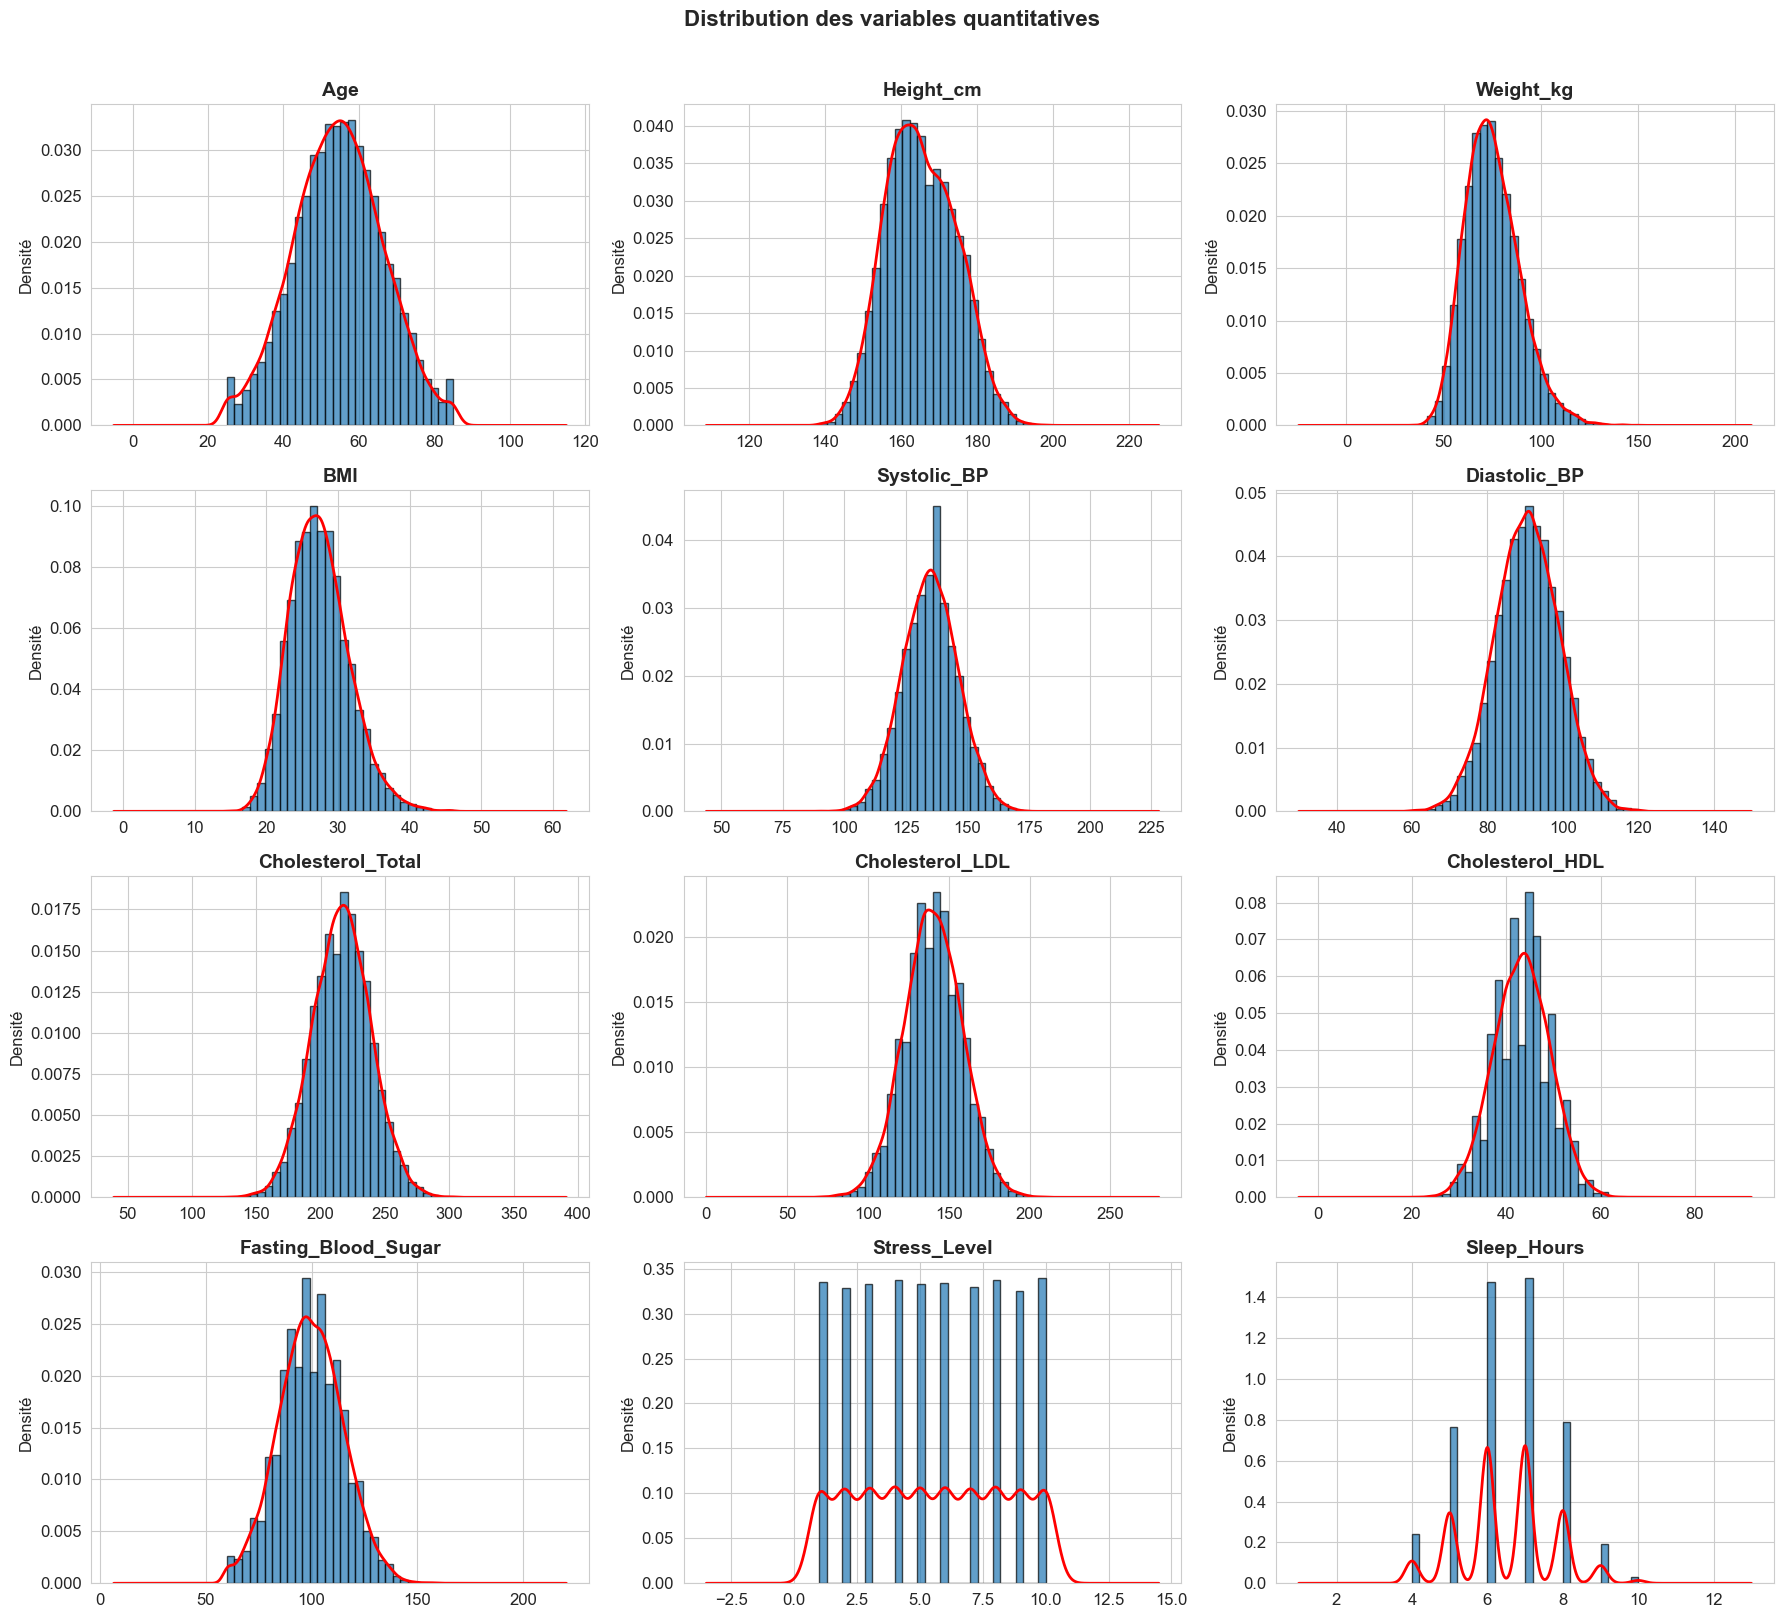

In [50]:
# Liste des variables quantitatives
var_quant = ["Age", "Height_cm", "Weight_kg", "BMI", "Systolic_BP", "Diastolic_BP",
             "Cholesterol_Total", "Cholesterol_LDL", "Cholesterol_HDL",
             "Fasting_Blood_Sugar", "Stress_Level", "Sleep_Hours"]

fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, var in enumerate(var_quant):
    axes[i].hist(data[var], bins=30, edgecolor='black', alpha=0.7, density=True)
    data[var].plot.kde(ax=axes[i], color='red', linewidth=2)
    axes[i].set_title(var, fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Densité')

plt.suptitle("Distribution des variables quantitatives", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observations :**
- La majorité des variables quantitatives (`Age`, `Height_cm`, `Weight_kg`, `BMI`, `Systolic_BP`, `Diastolic_BP`, `Cholesterol_Total`, `Cholesterol_LDL`, `Cholesterol_HDL`, `Fasting_Blood_Sugar`) présentent des distributions approximativement symétriques en cloche, proches d'une loi normale.
- `Stress_Level` : variable discrète (valeurs entières de 1 à 10) avec une distribution apparemment uniforme (chaque niveau a un effectif similaire). La courbe KDE n'est pas pertinente ici car elle lisse artificiellement une variable discrète.
- `Sleep_Hours` : variable discrète (valeurs entières de 4 à 10) avec un pic autour de 6-7h. Même remarque sur la KDE.

Les distributions sont globalement symétriques, donc les transformations classiques (log, racine carrée, etc.) ne sont pas nécessaires à ce stade.

**Implication modélisation :** les hypothèses de normalité des résidus pour les modèles linéaires sont raisonnablement satisfaites côté distribution des features, et on peut travailler sur les variables brutes (sauf standardisation pour les algorithmes sensibles à l'échelle : SVM, KNN, réseaux de neurones).

#### Boxplots des variables quantitatives

Les boxplots permettent de visualiser la médiane, les quartiles et les valeurs aberrantes (outliers) de chaque variable.

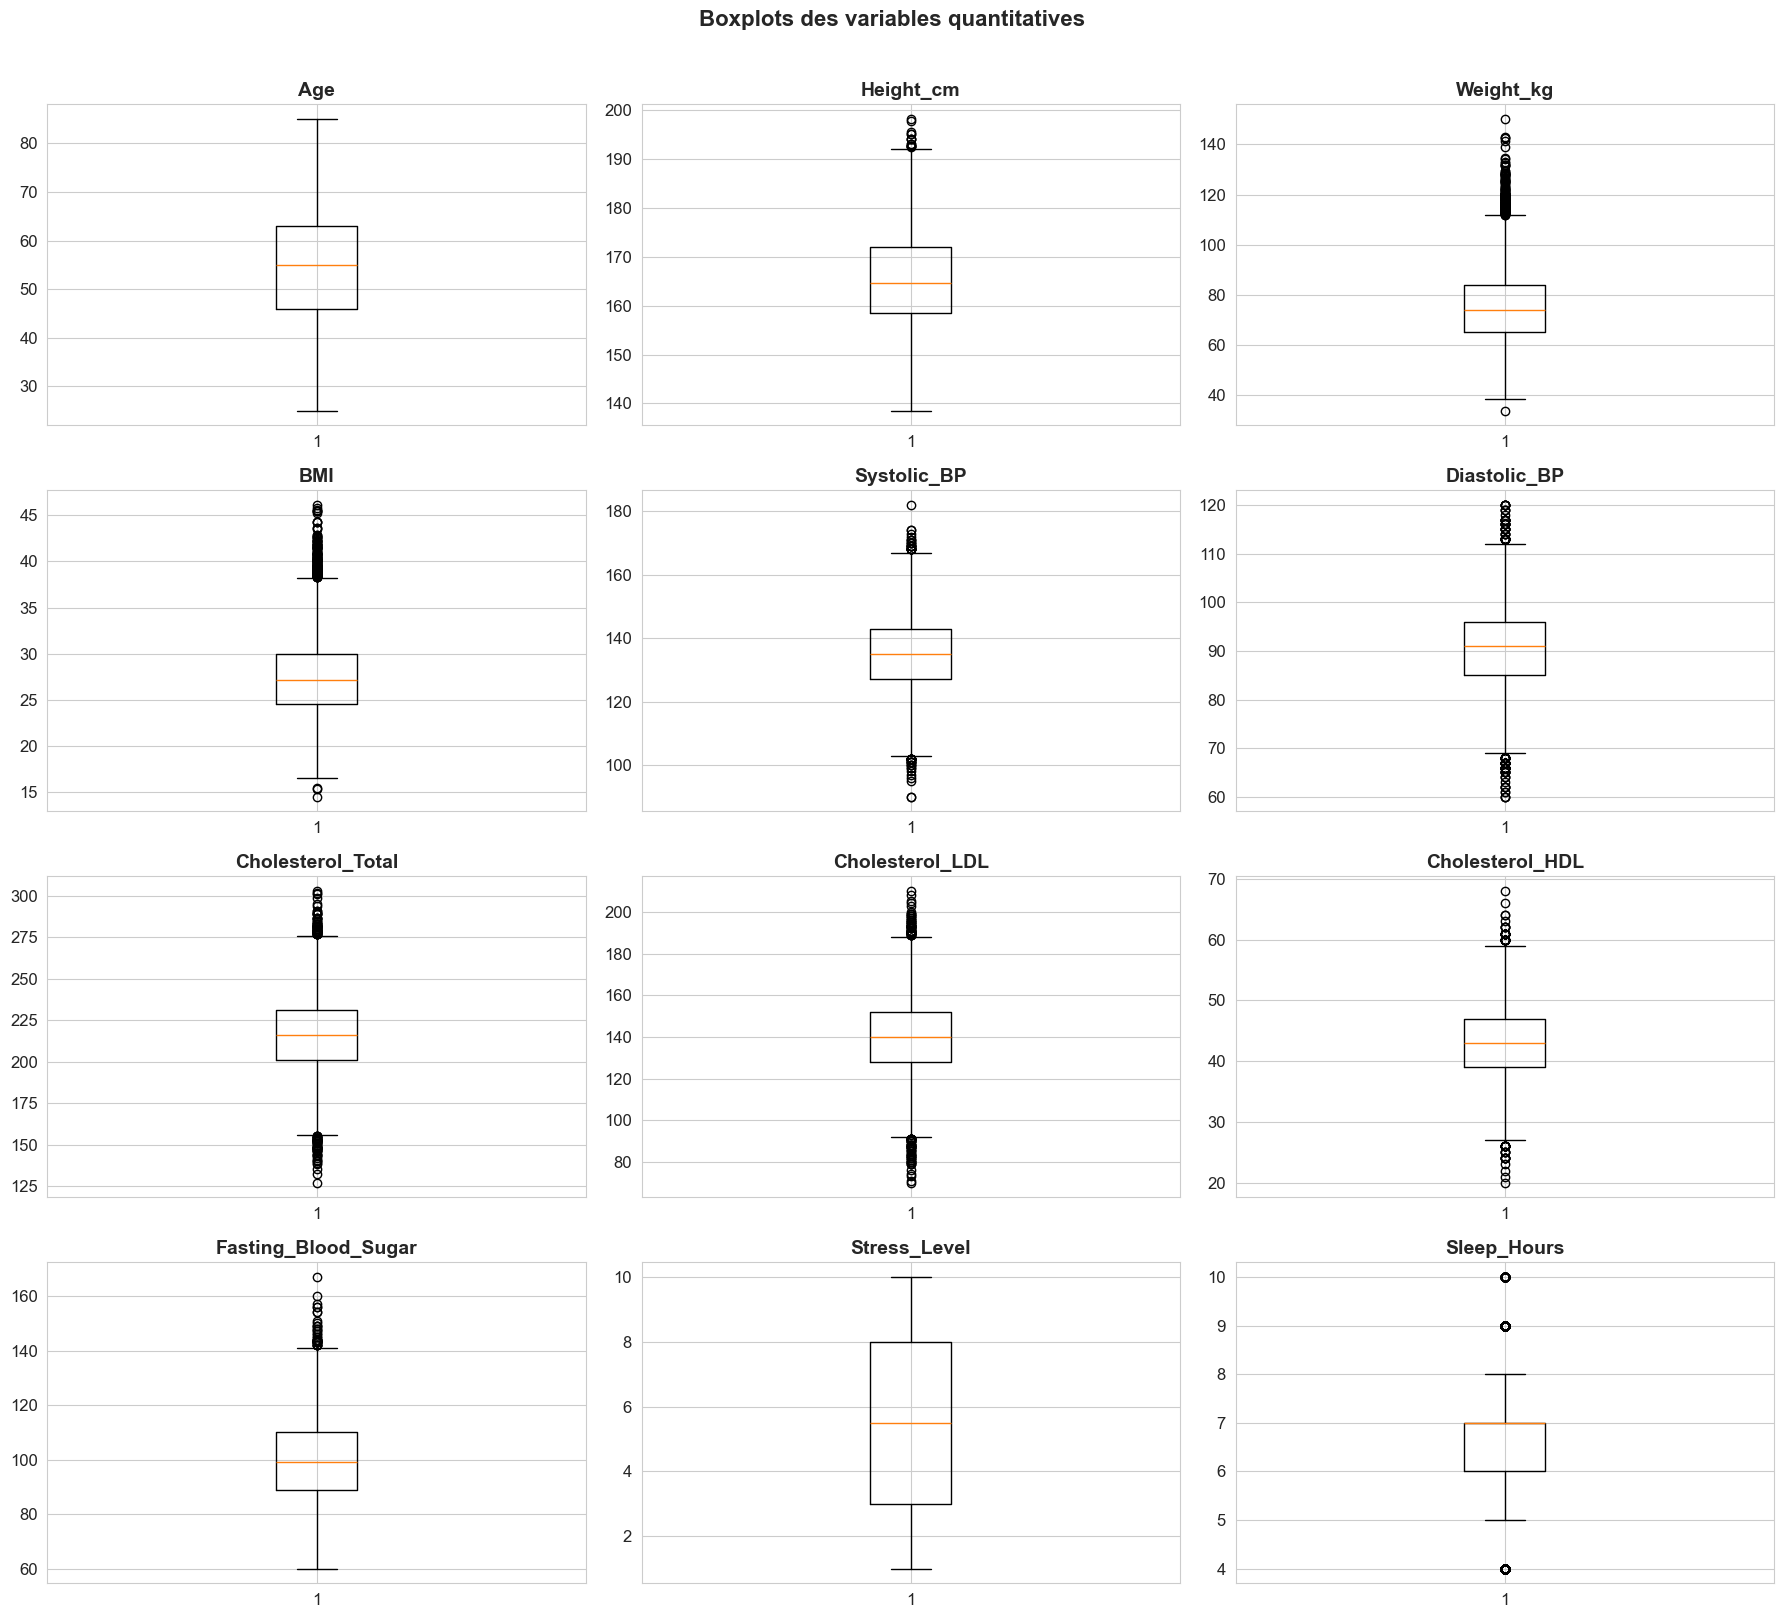

In [51]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, var in enumerate(var_quant):
    axes[i].boxplot(data[var], vert=True)
    axes[i].set_title(var, fontsize=14, fontweight='bold')

plt.suptitle("Boxplots des variables quantitatives", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observations :**
- La plupart des variables présentent des outliers aux deux extrêmes (`Weight_kg`, `BMI`, `Systolic_BP`, `Diastolic_BP`, `Cholesterol_Total`, `Cholesterol_LDL`, `Cholesterol_HDL`, `Fasting_Blood_Sugar`). Les moustaches du boxplot s'étendent jusqu'à 1.5 fois l'écart interquartile (IQR) au-delà de la boîte, ce qui couvre environ 99.3% des données pour une loi normale. Les points restants (~0.7%, soit environ 105 observations sur 15000) apparaissent comme outliers, même sans anomalie réelle. Ces valeurs restent dans des plages médicalement plausibles, il n'y a donc pas de raison de les supprimer.
- `Stress_Level` : la boîte est large (distribution uniforme), pas d'outliers.
- `Sleep_Hours` : les valeurs 4, 5, 9, 10 apparaissent comme outliers car la boîte est très resserrée autour de 6-7h. C'est un artefact lié au caractère discret de la variable, pas de vrais outliers.

Les boxplots confirment les observations des histogrammes : distributions globalement symétriques, pas de valeurs aberrantes nécessitant un traitement particulier.

**Implication modélisation :** on conserve les outliers (pas d'anomalie médicale). Les modèles linéaires (régression linéaire, logistique) peuvent y être sensibles, la régularisation (Ridge, Lasso) atténuera leur effet. Les modèles à base d'arbres (CART, Random Forest, Boosting) y sont naturellement robustes.

### 2.2 Variables qualitatives

On examine la répartition des modalités de chaque variable qualitative. L'équilibre des classes de la variable cible `Heart_Disease_Risk` est particulièrement important pour la classification.

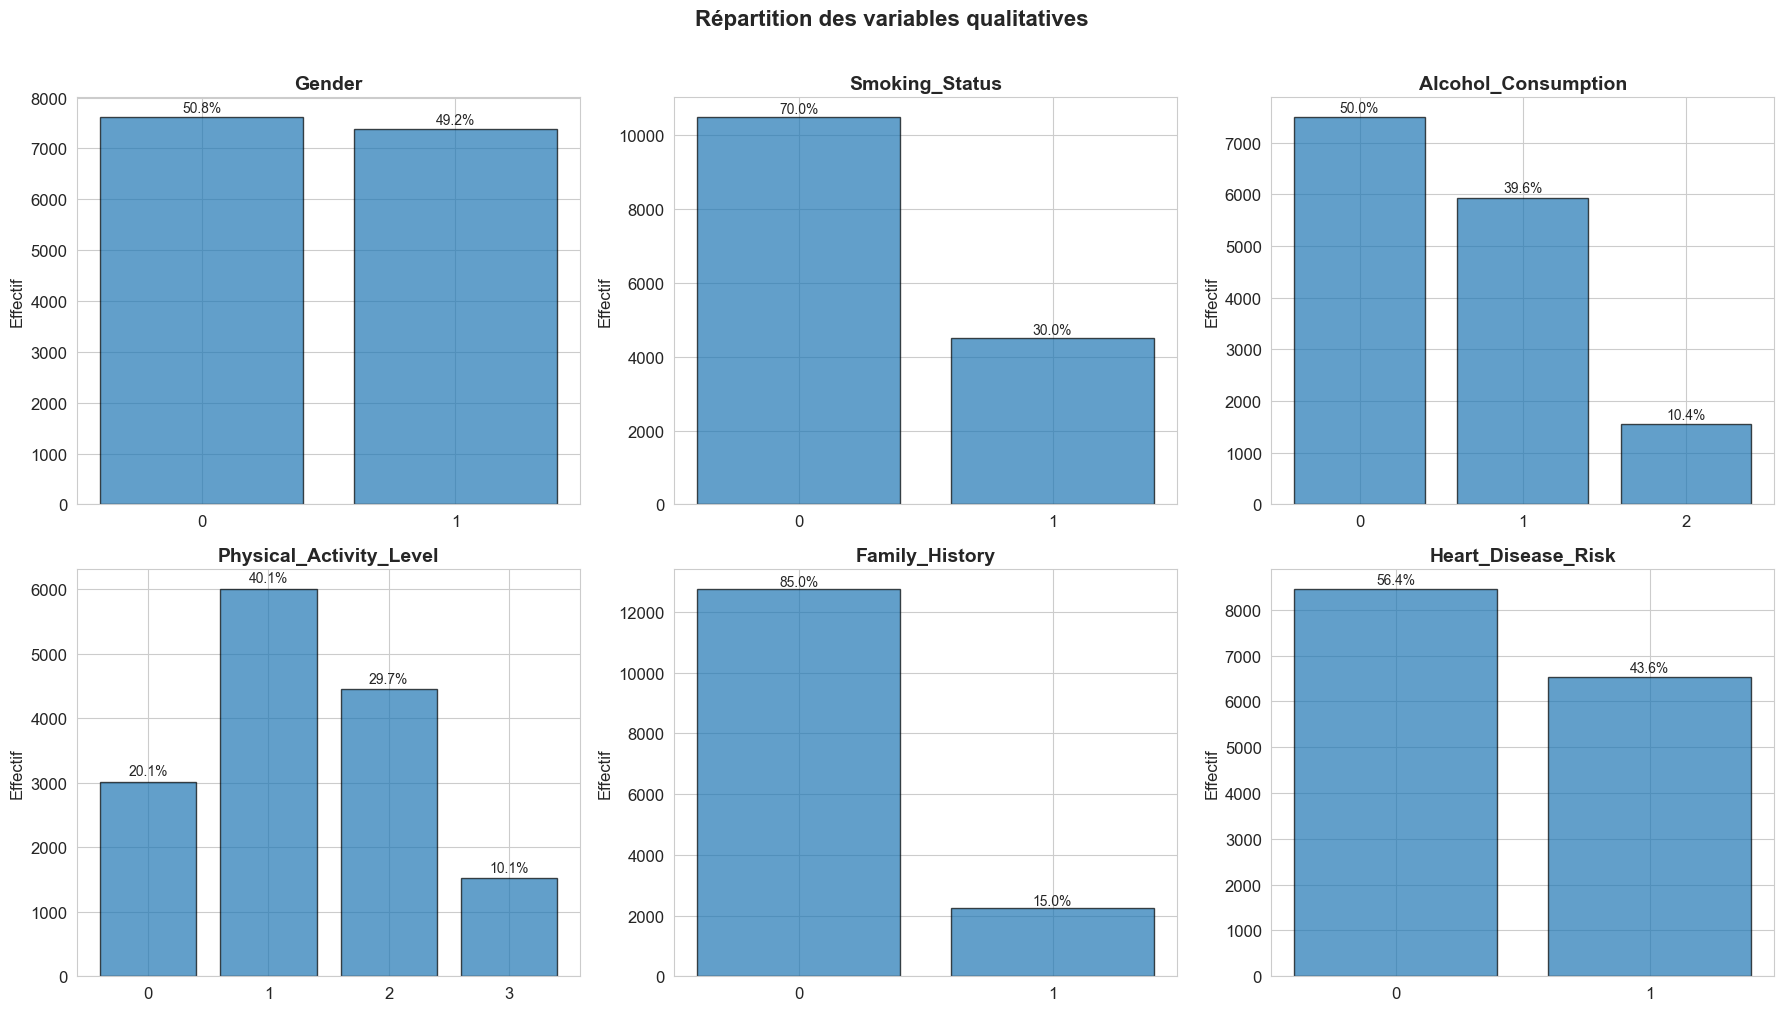

In [52]:
var_qual = ["Gender", "Smoking_Status", "Alcohol_Consumption",
            "Physical_Activity_Level", "Family_History", "Heart_Disease_Risk"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(var_qual):
    counts = data[var].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values, edgecolor='black', alpha=0.7)
    axes[i].set_title(var, fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Effectif')
    # Ajouter les pourcentages
    for j, (val, count) in enumerate(zip(counts.index, counts.values)):
        axes[i].text(j, count + 100, f"{count/len(data)*100:.1f}%", ha='center', fontsize=10)

plt.suptitle("Répartition des variables qualitatives", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Observations :**
- `Gender` : répartition quasi-équilibrée (50.8% / 49.2%).
- `Smoking_Status` : 70% de non-fumeurs contre 30% de fumeurs. Déséquilibre modéré mais pas problématique.
- `Alcohol_Consumption` : la moitié des patients sont au niveau 0 (50%), 39.6% au niveau 1 et seulement 10.4% au niveau 2 (forte consommation). La modalité 2 est sous-représentée.
- `Physical_Activity_Level` : répartition inégale entre les 4 niveaux mais toutes les modalités sont suffisamment représentées.
- `Family_History` : forte majorité sans antécédents familiaux (85% contre 15%). Déséquilibre marqué.
- `Heart_Disease_Risk` (variable cible en classification) : 56.4% de risque faible contre 43.6% de risque élevé. Les classes sont raisonnablement équilibrées : un modèle naïf qui prédirait toujours la classe majoritaire n'obtiendrait que 56.4%, ce qui est facile à dépasser. Pas besoin de techniques de rééquilibrage, et l'accuracy sera une métrique fiable, même si le léger déséquilibre doit être gardé en tête.

## 3. Analyse bivariée

On étudie les dépendances entre variables, organisées par type de couple :
- 3.1 quanti × quanti
- 3.2 quanti × quali
- 3.3 quali × quali

À chaque sous-section, on précise à quelle tâche du projet l'analyse contribue : régression sur `Cholesterol_LDL`, classification sur `Heart_Disease_Risk`, ou les deux (typiquement, les analyses de dépendances entre variables explicatives qui informent sur la multicolinéarité pour les deux modélisations à venir).

### 3.1 Variables quantitatives × variables quantitatives

#### 3.1.1 Dépendances entre variables quantitatives explicatives

Cette analyse est utile aux deux tâches. On étudie les redondances entre les 12 variables quantitatives à l'aide d'une matrice de corrélation de Pearson complétée par une scatter matrix. Cette analyse informe sur la multicolinéarité, problématique pour les modèles linéaires (régression linéaire pour LDL, régression logistique pour HDR) et qu'on retrouvera pour les deux tâches de modélisation.

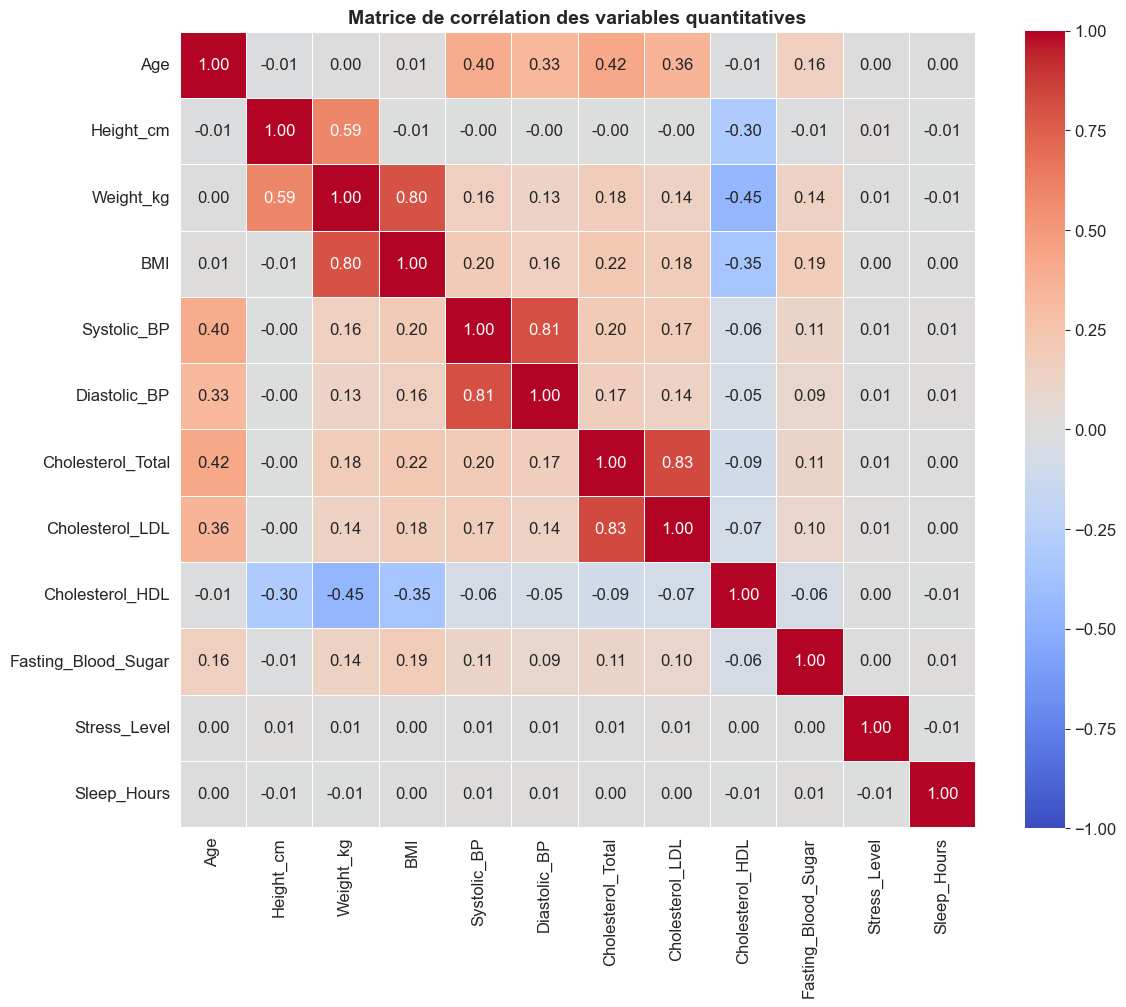

In [53]:
# Matrice de corrélation
corr_matrix = data[var_quant].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title("Matrice de corrélation des variables quantitatives", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interprétation :**

Corrélations fortes (|r| > 0.7) :
- `Cholesterol_Total` / `Cholesterol_LDL` : 0.83, le LDL est une composante majeure du cholestérol total, cette redondance est attendue.
- `Systolic_BP` / `Diastolic_BP` : 0.81, les deux pressions artérielles évoluent ensemble.
- `Weight_kg` / `BMI` : 0.80, le BMI est calculé à partir du poids, la colinéarité est mécanique.

Corrélations modérées (0.3 < |r| < 0.7) :
- `Height_cm` / `Weight_kg` : 0.59, logique, les personnes plus grandes sont en moyenne plus lourdes.
- `Weight_kg` / `Cholesterol_HDL` : -0.45, le "bon" cholestérol diminue avec le poids, cohérent médicalement.
- `Age` / `Cholesterol_Total` : 0.42, `Age` / `Systolic_BP` : 0.40, `Age` / `Cholesterol_LDL` : 0.36, le cholestérol et la pression artérielle augmentent avec l'âge.
- `BMI` / `Cholesterol_HDL` : -0.35, `Height_cm` / `Cholesterol_HDL` : -0.30, le HDL est négativement lié au poids/taille.

Corrélations quasi-nulles :
- `Stress_Level` et `Sleep_Hours` ne sont corrélés à aucune autre variable (|r| < 0.02). Ces variables semblent indépendantes du reste.

Ces redondances fortes (Weight/BMI, Systolic/Diastolic, Cholesterol_Total/LDL) sont à garder en tête : elles peuvent poser des problèmes de multicolinéarité pour les modèles linéaires.

Scatter matrix complémentaire

On confirme visuellement les corrélations identifiées dans la heatmap.

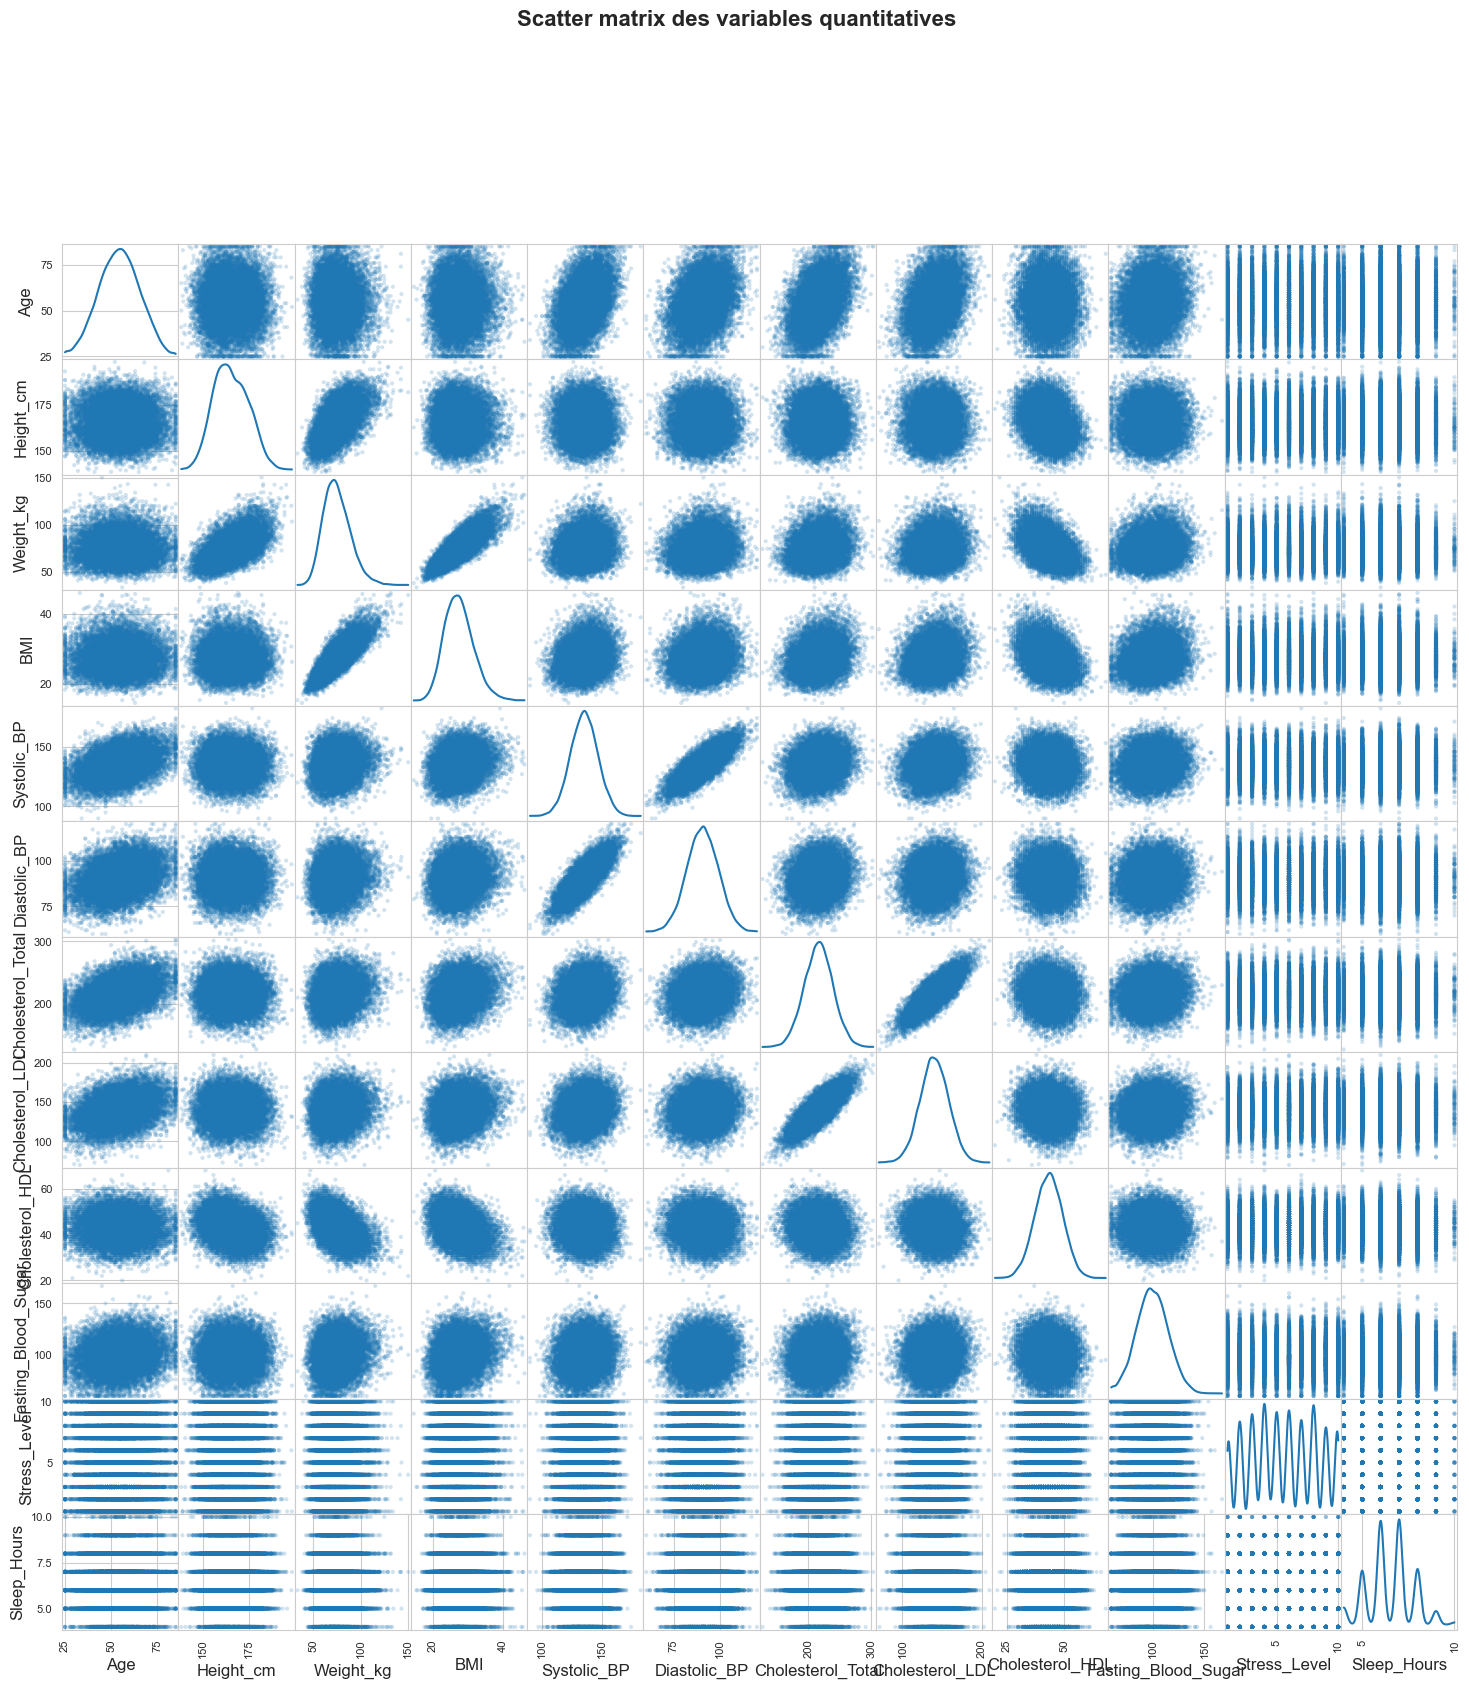

In [54]:
from pandas.plotting import scatter_matrix

scatter_matrix(data[var_quant], alpha=0.2, figsize=(18, 18), diagonal='kde')
plt.suptitle("Scatter matrix des variables quantitatives", fontsize=16, fontweight='bold', y=1.01)
plt.show()

La scatter matrix confirme visuellement les corrélations identifiées dans la heatmap : les paires fortement corrélées (Weight/BMI, Systolic/Diastolic BP, Cholesterol_Total/LDL) forment des ellipses étirées, tandis que les paires non corrélées forment des nuages ronds. Les stries visibles sur `Stress_Level` et `Sleep_Hours` sont dues au caractère discret de ces variables.

#### 3.1.2 Variables quantitatives vs `Cholesterol_LDL`

Cette analyse est spécifique à la régression sur LDL. La matrice de corrélation de la 3.1.1 contenait déjà l'information sur les corrélations entre LDL et les autres variables quantitatives. On la met ici en exergue avec un bar chart trié et des scatter plots ciblés sur les meilleurs prédicteurs candidats. L'objectif est d'identifier sur quels prédicteurs quantitatifs la régression LDL pourra s'appuyer.

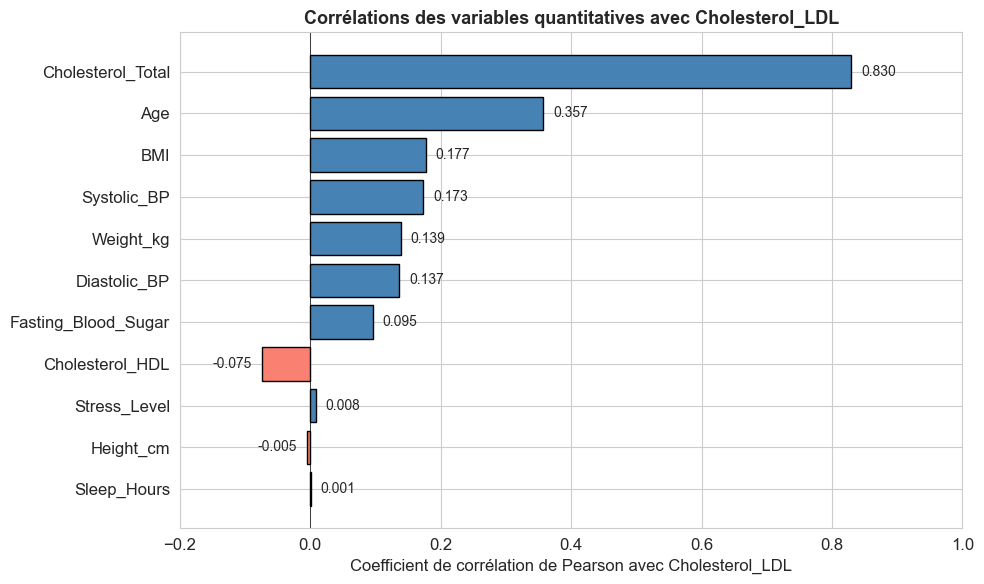

In [55]:
# Corrélations de Cholesterol_LDL avec les autres variables quantitatives
corr_with_ldl = data[var_quant].corr()['Cholesterol_LDL'].drop('Cholesterol_LDL').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if c >= 0 else 'salmon' for c in corr_with_ldl.values]
bars = ax.barh(range(len(corr_with_ldl)), corr_with_ldl.values, color=colors, edgecolor='black')
ax.set_yticks(range(len(corr_with_ldl)))
ax.set_yticklabels(corr_with_ldl.index)
ax.invert_yaxis()
ax.set_xlabel('Coefficient de corrélation de Pearson avec Cholesterol_LDL')
ax.set_title('Corrélations des variables quantitatives avec Cholesterol_LDL',
             fontsize=13, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.5)
for i, val in enumerate(corr_with_ldl.values):
    ax.text(val + (0.015 if val >= 0 else -0.015), i, f'{val:.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=10)
ax.set_xlim(-0.2, 1.0)
plt.tight_layout()
plt.show()

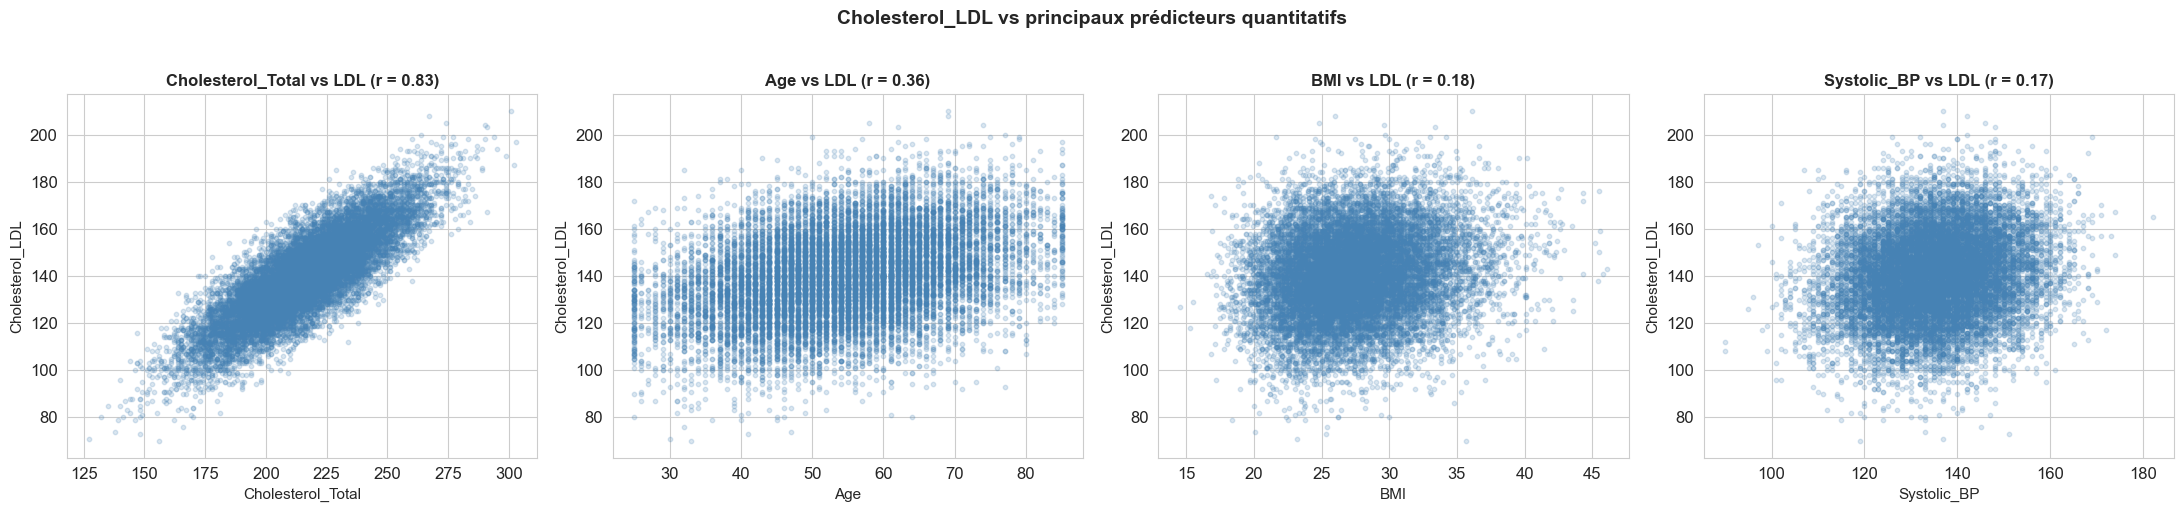

In [56]:
# Scatter plots de LDL vs les principaux prédicteurs quantitatifs
top_predictors = ['Cholesterol_Total', 'Age', 'BMI', 'Systolic_BP']
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for i, var in enumerate(top_predictors):
    axes[i].scatter(data[var], data['Cholesterol_LDL'], alpha=0.2, s=10, color='steelblue')
    r = data[var].corr(data['Cholesterol_LDL'])
    axes[i].set_xlabel(var, fontsize=11)
    axes[i].set_ylabel('Cholesterol_LDL', fontsize=11)
    axes[i].set_title(f'{var} vs LDL (r = {r:.2f})', fontsize=12, fontweight='bold')

plt.suptitle('Cholesterol_LDL vs principaux prédicteurs quantitatifs',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interprétation :**

Hiérarchie des corrélations :
- `Cholesterol_Total` : r = 0.83. Corrélation massive, isolée du reste, attendue car LDL est une composante du cholestérol total. Si Total est dans les features, tout modèle atteindra un R² élevé en exploitant cette relation quasi-déterministe, ce qui masquera le signal des autres variables.
- `Age` : r = 0.36, deuxième prédicteur, cohérent médicalement.
- `BMI` (0.18), `Systolic_BP` (0.17), `Weight_kg` (0.14), `Diastolic_BP` (0.14), `Fasting_Blood_Sugar` (0.10) : corrélations faibles, utiles seulement en combinaison.
- `Cholesterol_HDL` : r = −0.07, quasi-nulle. On aurait pu attendre une anti-corrélation plus marquée médicalement.
- `Stress_Level`, `Height_cm`, `Sleep_Hours` : |r| < 0.01, inutiles pour la régression LDL.

Scatter plots :
- `Cholesterol_Total` vs LDL : nuage en ellipse étirée, relation linéaire forte.
- `Age` vs LDL : tendance positive mais bruitée.
- `BMI` et `Systolic_BP` vs LDL : nuages presque ronds, signal très faible.

Implications pour la modélisation :
- Une régression linéaire fonctionnera très bien avec `Cholesterol_Total`, mais cette relation est mécanique (LDL est une composante de Total), pas causale. Les coefficients des autres variables ne refléteront que la part de LDL non expliquée par Total.
- `Stress_Level`, `Sleep_Hours`, `Height_cm` sont candidates à être éliminées par sélection ou pénalisation L1.

### 3.2 Variables quantitatives × variables qualitatives

#### 3.2.1 Variables quantitatives explicatives × variables qualitatives explicatives

Cette analyse est utile aux deux tâches. On examine si les variables qualitatives explicatives ont un effet marqué sur les variables quantitatives explicatives. Cela permet de détecter d'éventuels effets de confondants entre features explicatives, ce qui aiderait à interpréter les coefficients des modèles linéaires pour les deux tâches.

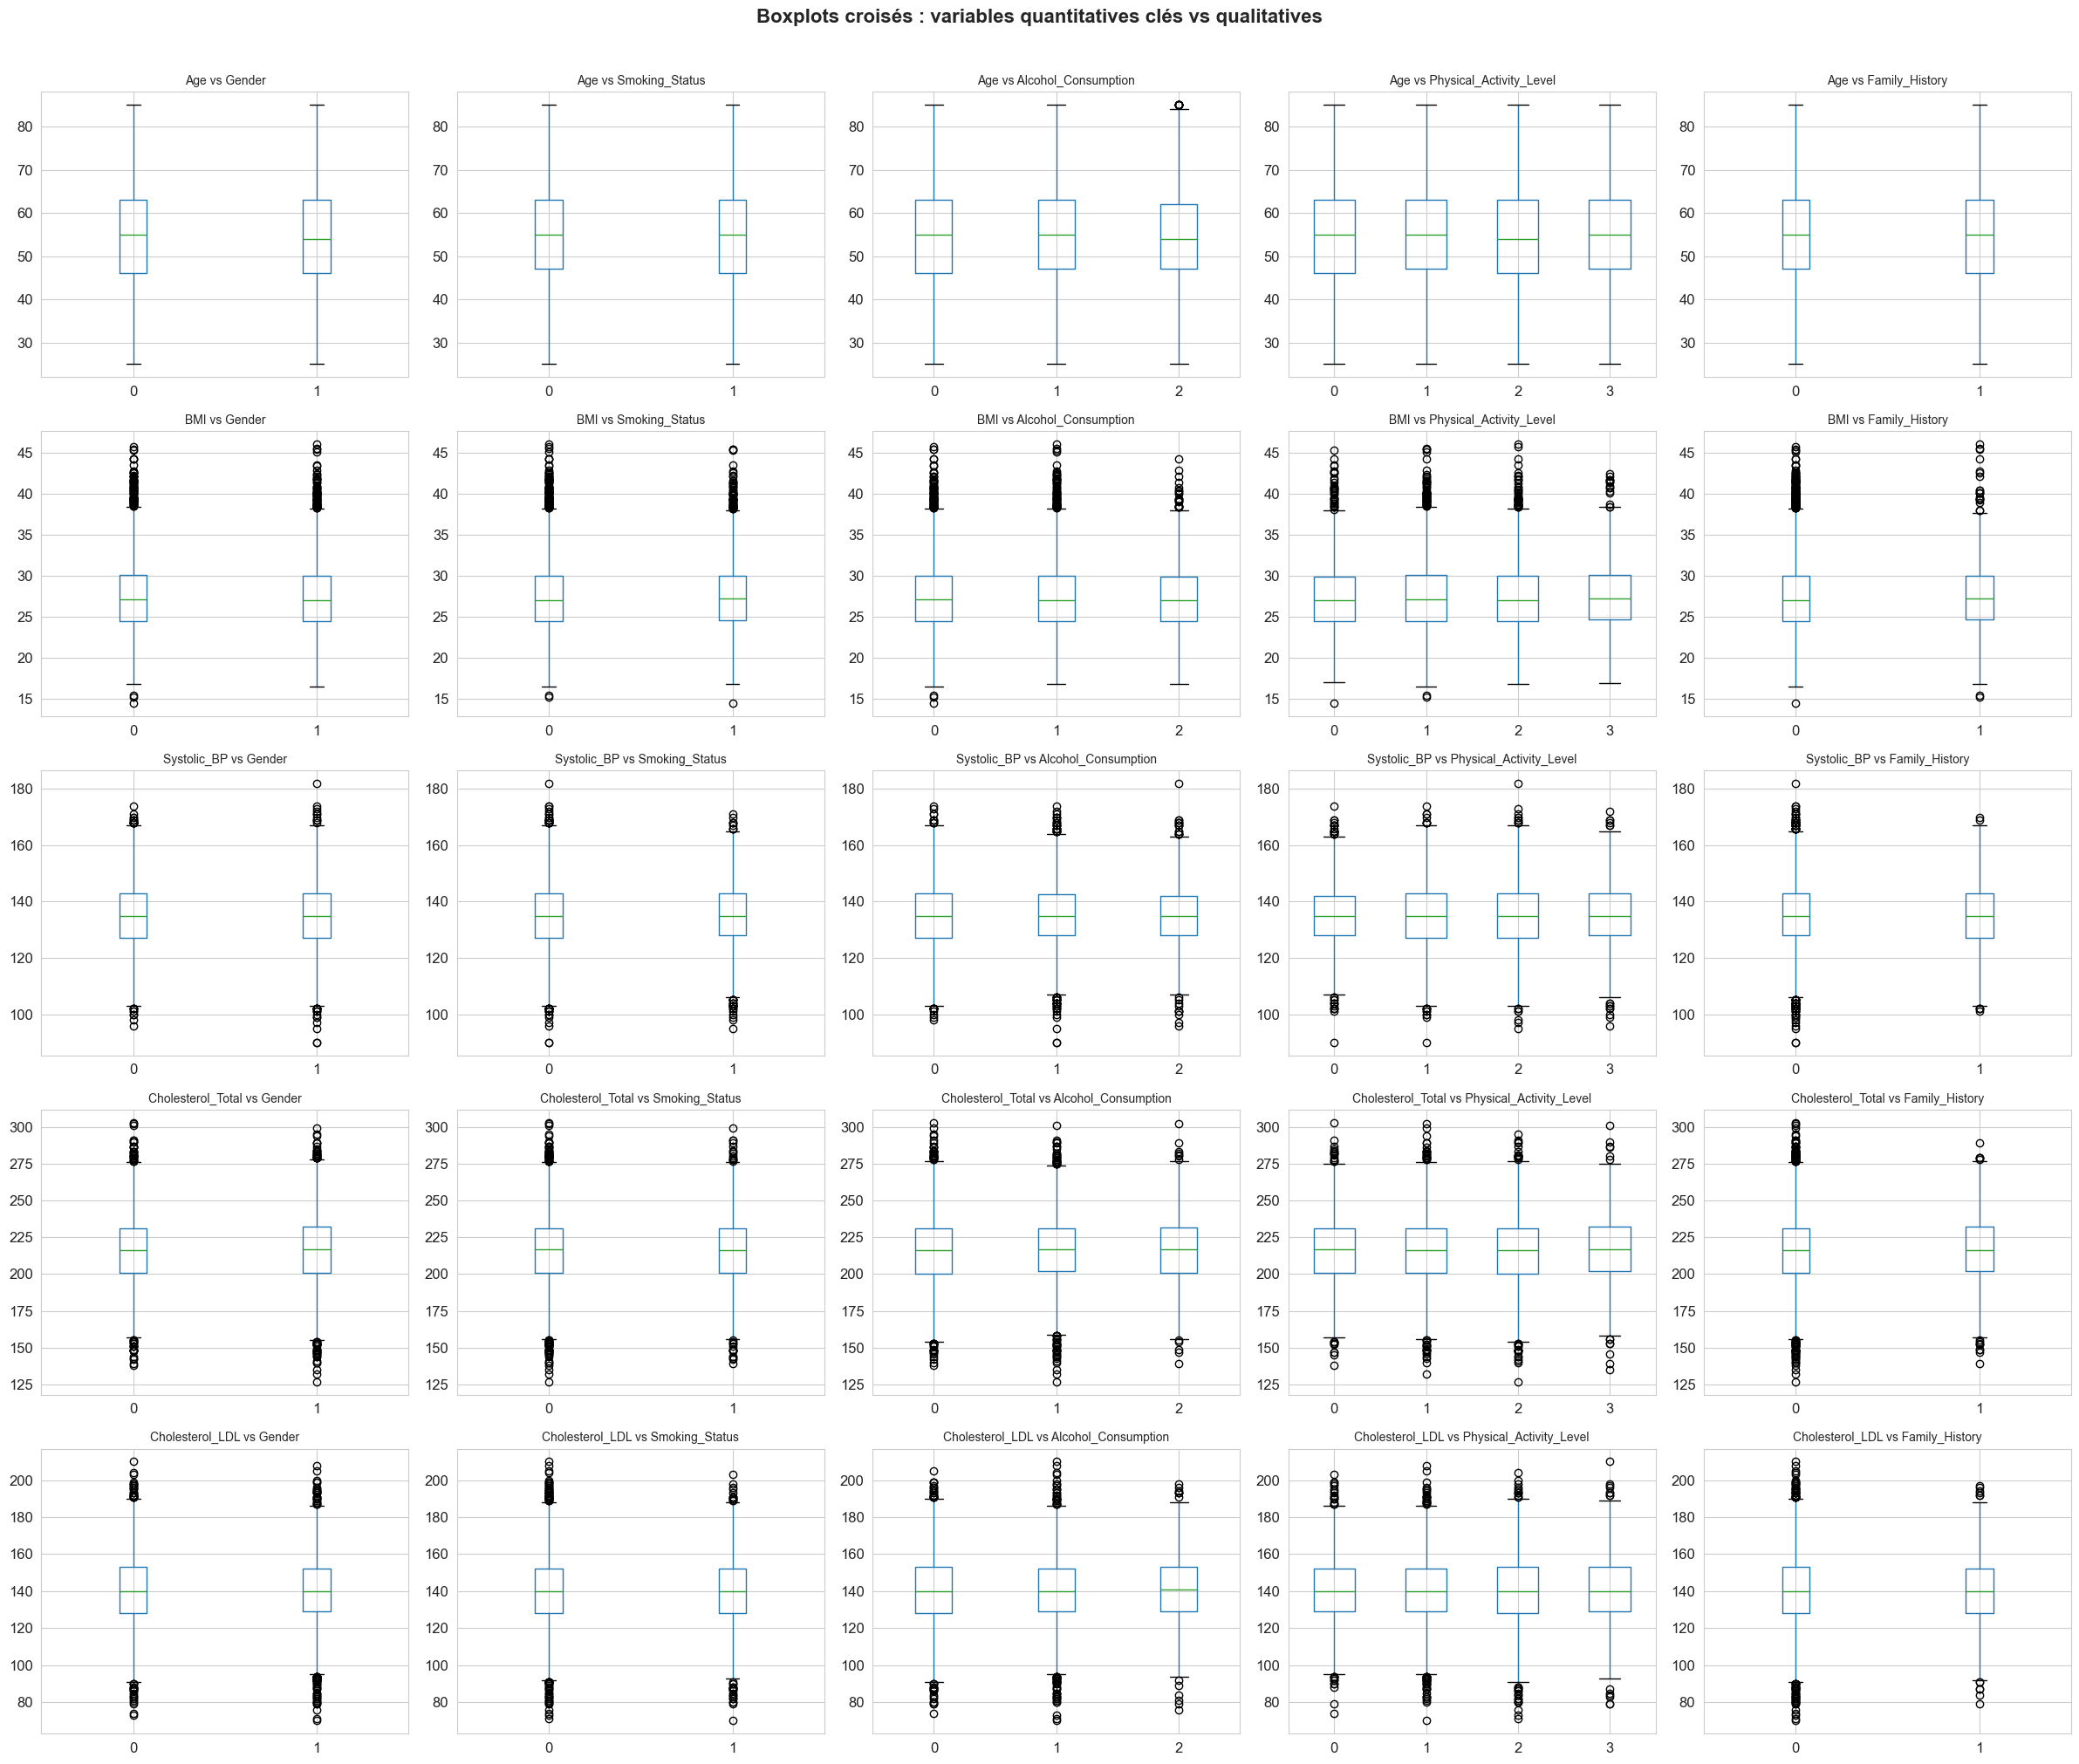

In [57]:
# Variables qualitatives explicatives (hors Heart_Disease_Risk)
var_qual_expl = ["Gender", "Smoking_Status", "Alcohol_Consumption",
                 "Physical_Activity_Level", "Family_History"]

# On se concentre sur quelques variables quantitatives clés
var_quant_cles = ["Age", "BMI", "Systolic_BP", "Cholesterol_Total", "Cholesterol_LDL"]

fig, axes = plt.subplots(len(var_quant_cles), len(var_qual_expl), figsize=(24, 20))

for i, vq in enumerate(var_quant_cles):
    for j, vql in enumerate(var_qual_expl):
        data.boxplot(column=vq, by=vql, ax=axes[i, j])
        axes[i, j].set_title(f"{vq} vs {vql}", fontsize=10)
        axes[i, j].set_xlabel("")

plt.suptitle("Boxplots croisés : variables quantitatives clés vs qualitatives",
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interprétation :**

Les boxplots sont très similaires d'une modalité à l'autre pour la grande majorité des croisements : les variables qualitatives prises individuellement n'ont pas d'effet marqué sur les variables quantitatives clés. C'est cohérent avec la matrice du V de Cramér de la 3.3.1 (associations quasi-nulles entre qualitatives) : les variables explicatives semblent peu confondues entre elles.

**Pour la modélisation :** on ne risque pas d'effets de confondants entre qualitatives et quantitatives. Les coefficients des modèles linéaires devraient être interprétables sans démêler des effets indirects.

#### 3.2.2 Variables quantitatives × `Heart_Disease_Risk`

Cette analyse est spécifique à la classification sur HDR. On utilise des boxplots parallèles pour visualiser comment chaque variable quantitative se distribue selon le risque cardiaque (HDR = 0 vs 1). C'est essentiel pour identifier les prédicteurs quantitatifs candidats à la classification.

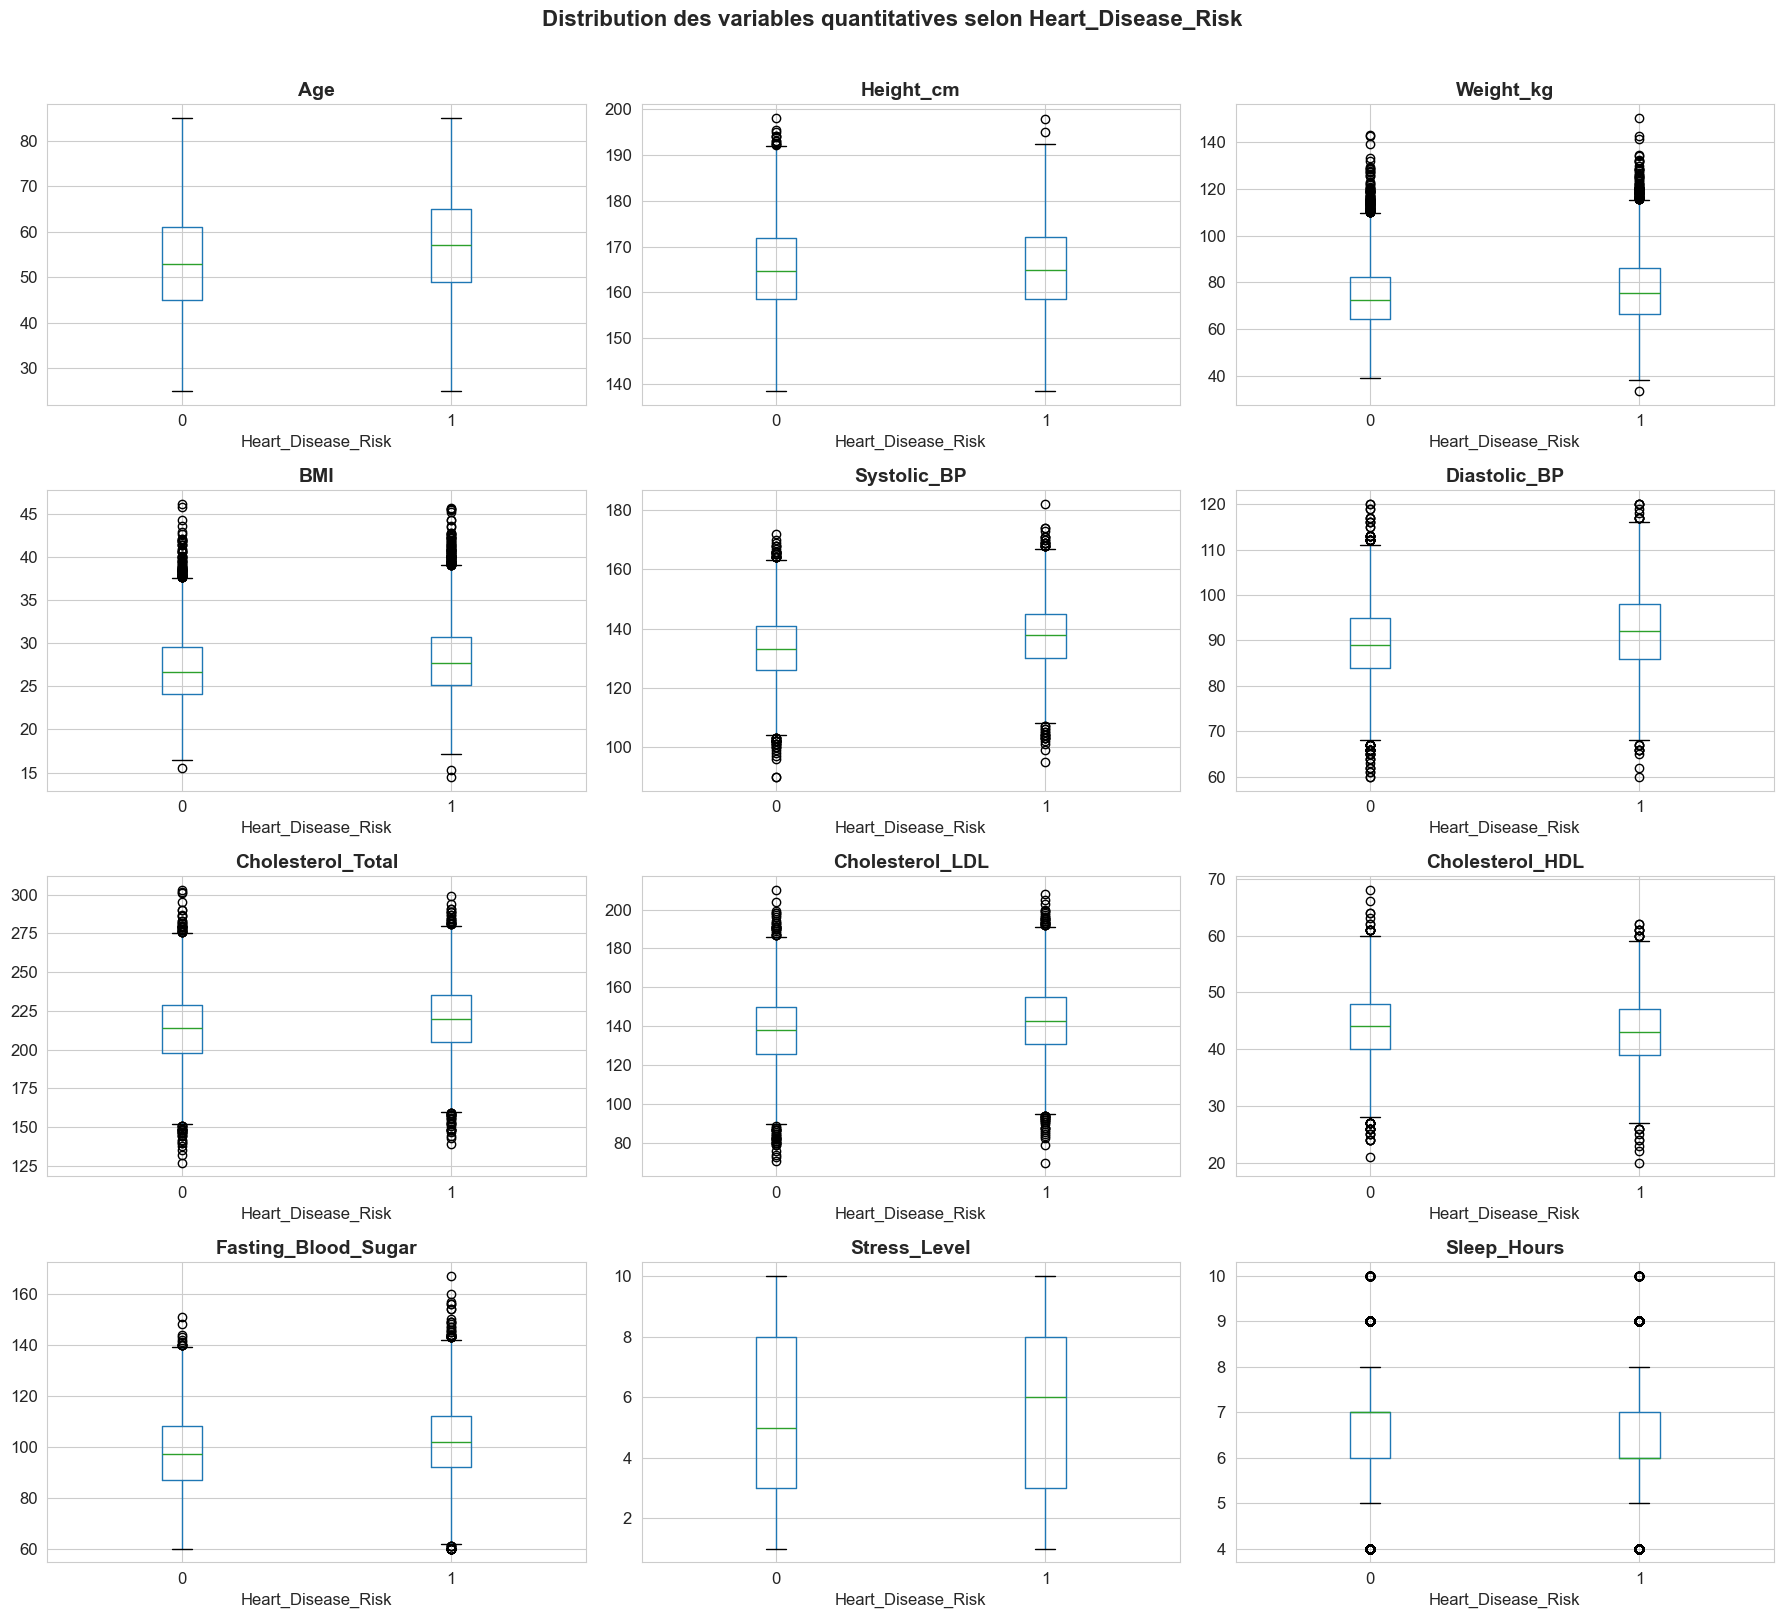

In [58]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for i, var in enumerate(var_quant):
    data.boxplot(column=var, by="Heart_Disease_Risk", ax=axes[i])
    axes[i].set_title(var, fontsize=14, fontweight='bold')
    axes[i].set_xlabel("Heart_Disease_Risk")

plt.suptitle("Distribution des variables quantitatives selon Heart_Disease_Risk",
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Interprétation :**

Variables discriminantes (différence visible entre les groupes 0 et 1) :
- `Age` : les patients à risque élevé sont en moyenne plus âgés (médiane ~58 vs ~50). C'est la variable qui semble le mieux séparer les deux groupes.
- `Systolic_BP` et `Diastolic_BP` : les médianes et boîtes sont légèrement plus élevées pour le groupe 1, cohérent avec le lien entre hypertension et risque cardiaque.
- `Cholesterol_Total` et `Cholesterol_LDL` : même constat, des valeurs légèrement plus élevées pour le groupe à risque.
- `Fasting_Blood_Sugar` : légère tendance à des valeurs plus élevées pour le groupe 1.
- `BMI` et `Weight_kg` : décalage léger vers le haut pour le groupe 1.

Variables non discriminantes (boxplots quasi-identiques entre les deux groupes) :
- `Height_cm` : pas de différence visible, la taille ne semble pas liée au risque cardiaque.
- `Cholesterol_HDL` : distributions très similaires entre les deux groupes.
- `Stress_Level` et `Sleep_Hours` : aucune différence, ce qui est cohérent avec leur absence de corrélation observée dans la heatmap.

Dans l'ensemble, les différences restent modérées : les boîtes se chevauchent largement pour toutes les variables. Cela suggère qu'aucune variable seule ne suffit à prédire le risque cardiaque, et que c'est la combinaison de plusieurs facteurs qui sera déterminante pour la modélisation.

#### 3.2.3 `Cholesterol_LDL` × variables qualitatives explicatives

Cette analyse est spécifique à la régression sur LDL. On examine si les variables qualitatives explicatives ont un effet sur le niveau de LDL. On utilise des boxplots pour la visualisation et le test ANOVA F pour quantifier la significativité (équivalent du χ² mais quand la cible est continue).

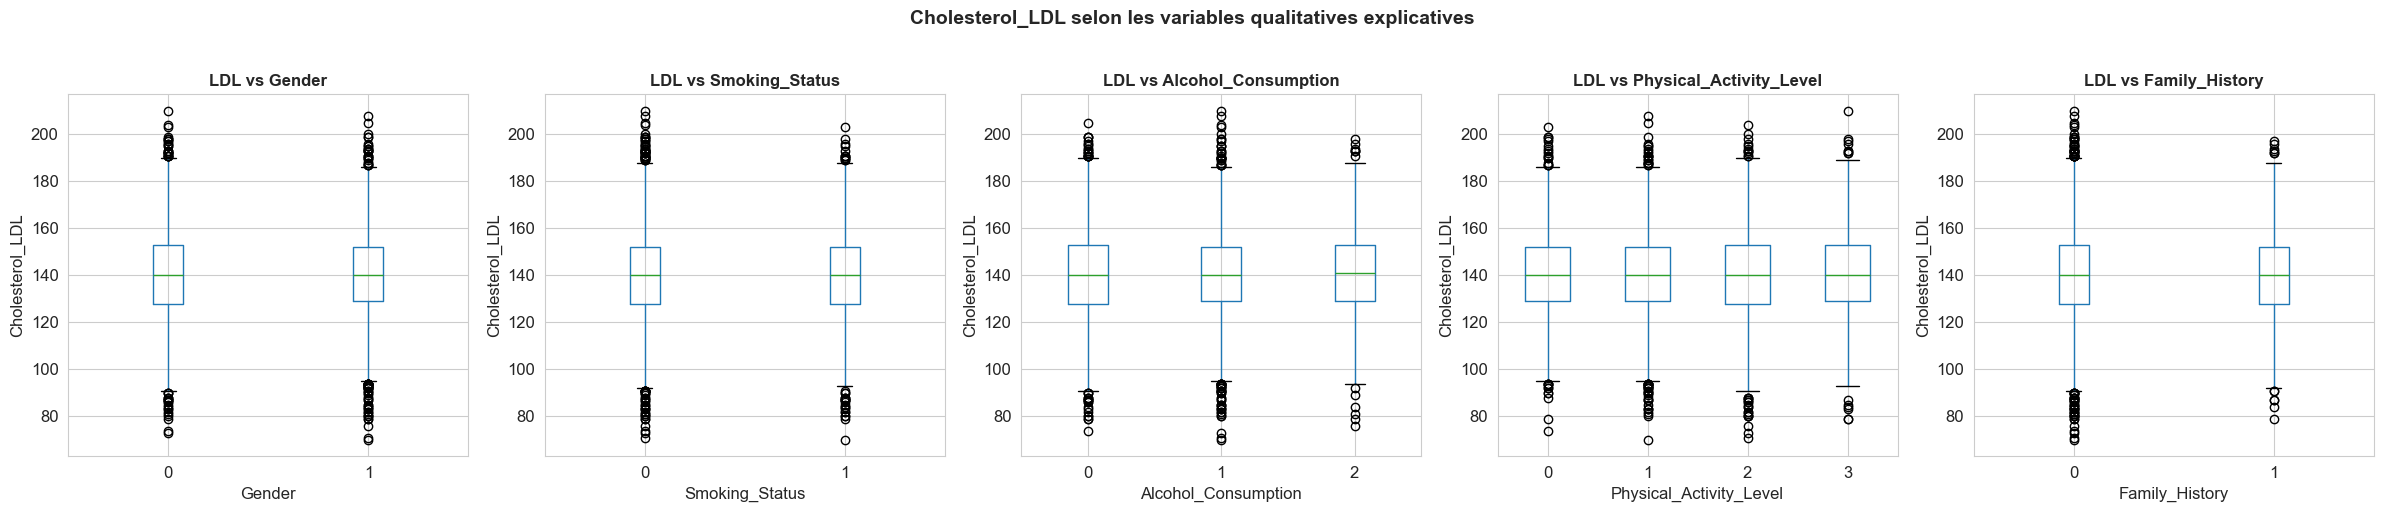

In [59]:
# Boxplots de Cholesterol_LDL par variable qualitative explicative
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for i, var in enumerate(var_qual_expl):
    data.boxplot(column='Cholesterol_LDL', by=var, ax=axes[i])
    axes[i].set_title(f'LDL vs {var}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Cholesterol_LDL')

plt.suptitle('Cholesterol_LDL selon les variables qualitatives explicatives',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [60]:
# Tableau récapitulatif : ANOVA F-test pour chaque variable qualitative
from scipy.stats import f_oneway

anova_results = []
for var in var_qual_expl:
    groups = [data.loc[data[var] == m, 'Cholesterol_LDL'].values for m in sorted(data[var].unique())]
    f_stat, p_val = f_oneway(*groups)
    anova_results.append({
        "Variable": var,
        "F-statistique": round(f_stat, 2),
        "p-value": f"{p_val:.2e}",
        "Significatif (alpha=0.05)": "Oui" if p_val < 0.05 else "Non"
    })

anova_df = pd.DataFrame(anova_results).sort_values("F-statistique", ascending=False).reset_index(drop=True)
anova_df

,Variable,F-statistique,p-value,Significatif (alpha=0.05)
0,Physical_Activity_Level,1.01,3.87e-01,Non
1,Family_History,0.56,4.52e-01,Non
2,Alcohol_Consumption,0.27,7.60e-01,Non
3,Gender,0.18,6.71e-01,Non
4,Smoking_Status,0.01,9.16e-01,Non


**Interprétation :**

Sur les 5 boxplots, les boîtes sont quasi-identiques d'une modalité à l'autre : aucun effet visible des qualitatives sur LDL. L'ANOVA F-test le confirme :

| Variable | F-stat | p-value | Significatif (α=0.05) |
|---|---|---|---|
| `Physical_Activity_Level` | 1.01 | 0.39 | Non |
| `Family_History` | 0.56 | 0.45 | Non |
| `Alcohol_Consumption` | 0.27 | 0.76 | Non |
| `Gender` | 0.18 | 0.67 | Non |
| `Smoking_Status` | 0.01 | 0.92 | Non |

Aucune variable qualitative n'est associée à LDL (p-values bien au-dessus de 0.05, F-stats inférieures à 1.5). Sur 15 000 patients, un effet réel aurait été détecté.

Contraste avec HDR : les variables qui dominaient pour la classification (`Smoking_Status`, `Family_History`, `Physical_Activity_Level`) n'apportent rien pour LDL. Logique : HDR intègre des facteurs comportementaux et héréditaires, alors que LDL est une mesure biochimique déterminée par des paramètres physiologiques quantitatifs.

Implications pour la modélisation :
- Les 6 colonnes one-hot des qualitatives apporteront un signal nul à la régression LDL. Une pénalisation L1 ou une sélection de variables devrait les éliminer, et leur importance sera quasi-nulle dans les modèles à base d'arbres.
- Si un modèle exploite fortement ces variables pour prédire LDL, c'est un signe de sur-apprentissage.

### 3.3 Variables qualitatives × variables qualitatives

#### 3.3.1 Dépendances entre variables qualitatives explicatives

Cette analyse est utile aux deux tâches. On étudie les redondances entre les 5 variables qualitatives explicatives à l'aide de la matrice du V de Cramér (équivalent catégoriel du coefficient de corrélation, entre 0 et 1). Comme pour la 3.1.1, cette analyse informe sur la multicolinéarité catégorielle, pertinente pour les deux tâches.

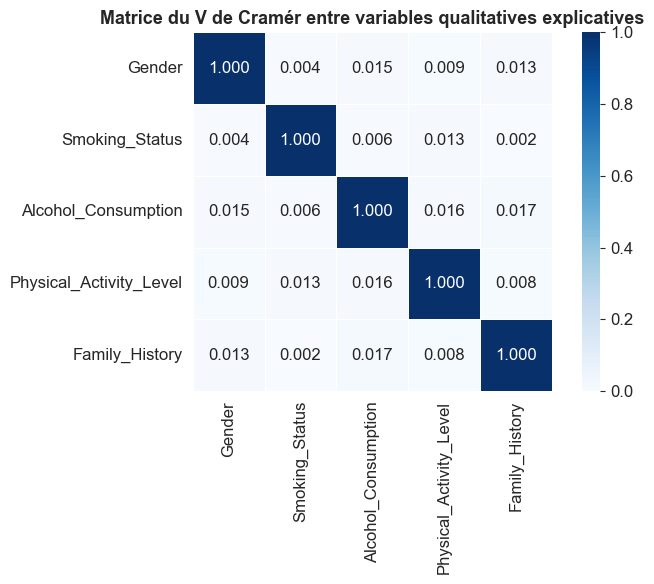

In [61]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """V de Cramér entre deux séries catégorielles."""
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# Matrice V de Cramér entre variables qualitatives explicatives
cramer_matrix = pd.DataFrame(
    np.zeros((len(var_qual_expl), len(var_qual_expl))),
    index=var_qual_expl, columns=var_qual_expl
)
for v1 in var_qual_expl:
    for v2 in var_qual_expl:
        cramer_matrix.loc[v1, v2] = cramers_v(data[v1], data[v2])

plt.figure(figsize=(8, 6))
sns.heatmap(cramer_matrix, annot=True, fmt=".3f", cmap="Blues",
            vmin=0, vmax=1, square=True, linewidths=0.5)
plt.title("Matrice du V de Cramér entre variables qualitatives explicatives",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interprétation :**

Toutes les valeurs hors diagonale sont extrêmement faibles, comprises entre 0.002 et 0.017. À titre de repère, un V de Cramér en dessous de 0.1 traduit déjà une association très faible : on est ici un ordre de grandeur en dessous. Les 5 variables qualitatives explicatives sont donc statistiquement indépendantes les unes des autres.

La paire la plus "élevée" est `Alcohol_Consumption` × `Family_History` à 0.017, ce qui reste totalement négligeable. Aucune paire n'approche un seuil problématique.

**Conséquences pour la modélisation :**
- Aucun risque de multicolinéarité catégorielle : les 5 variables qualitatives peuvent être conservées simultanément dans les modèles linéaires sans redondance.
- Chaque variable qualitative apporte une information indépendante des autres. Si l'une d'elles est discriminante pour `Heart_Disease_Risk` (ce que l'on vérifiera en 3.3.2), son apport ne sera pas absorbé par une autre.


#### 3.3.2 Variables qualitatives explicatives × `Heart_Disease_Risk`

Cette analyse est spécifique à la classification sur HDR. On croise chaque variable qualitative explicative avec la cible de classification à l'aide de mosaic plots (largeur des rectangles proportionnelle à la fréquence marginale, hauteur proportionnelle à la proportion conditionnelle de HDR, couleur des résidus de Pearson). On complète par un test du χ² et le V de Cramér pour quantifier la force et la significativité des associations.

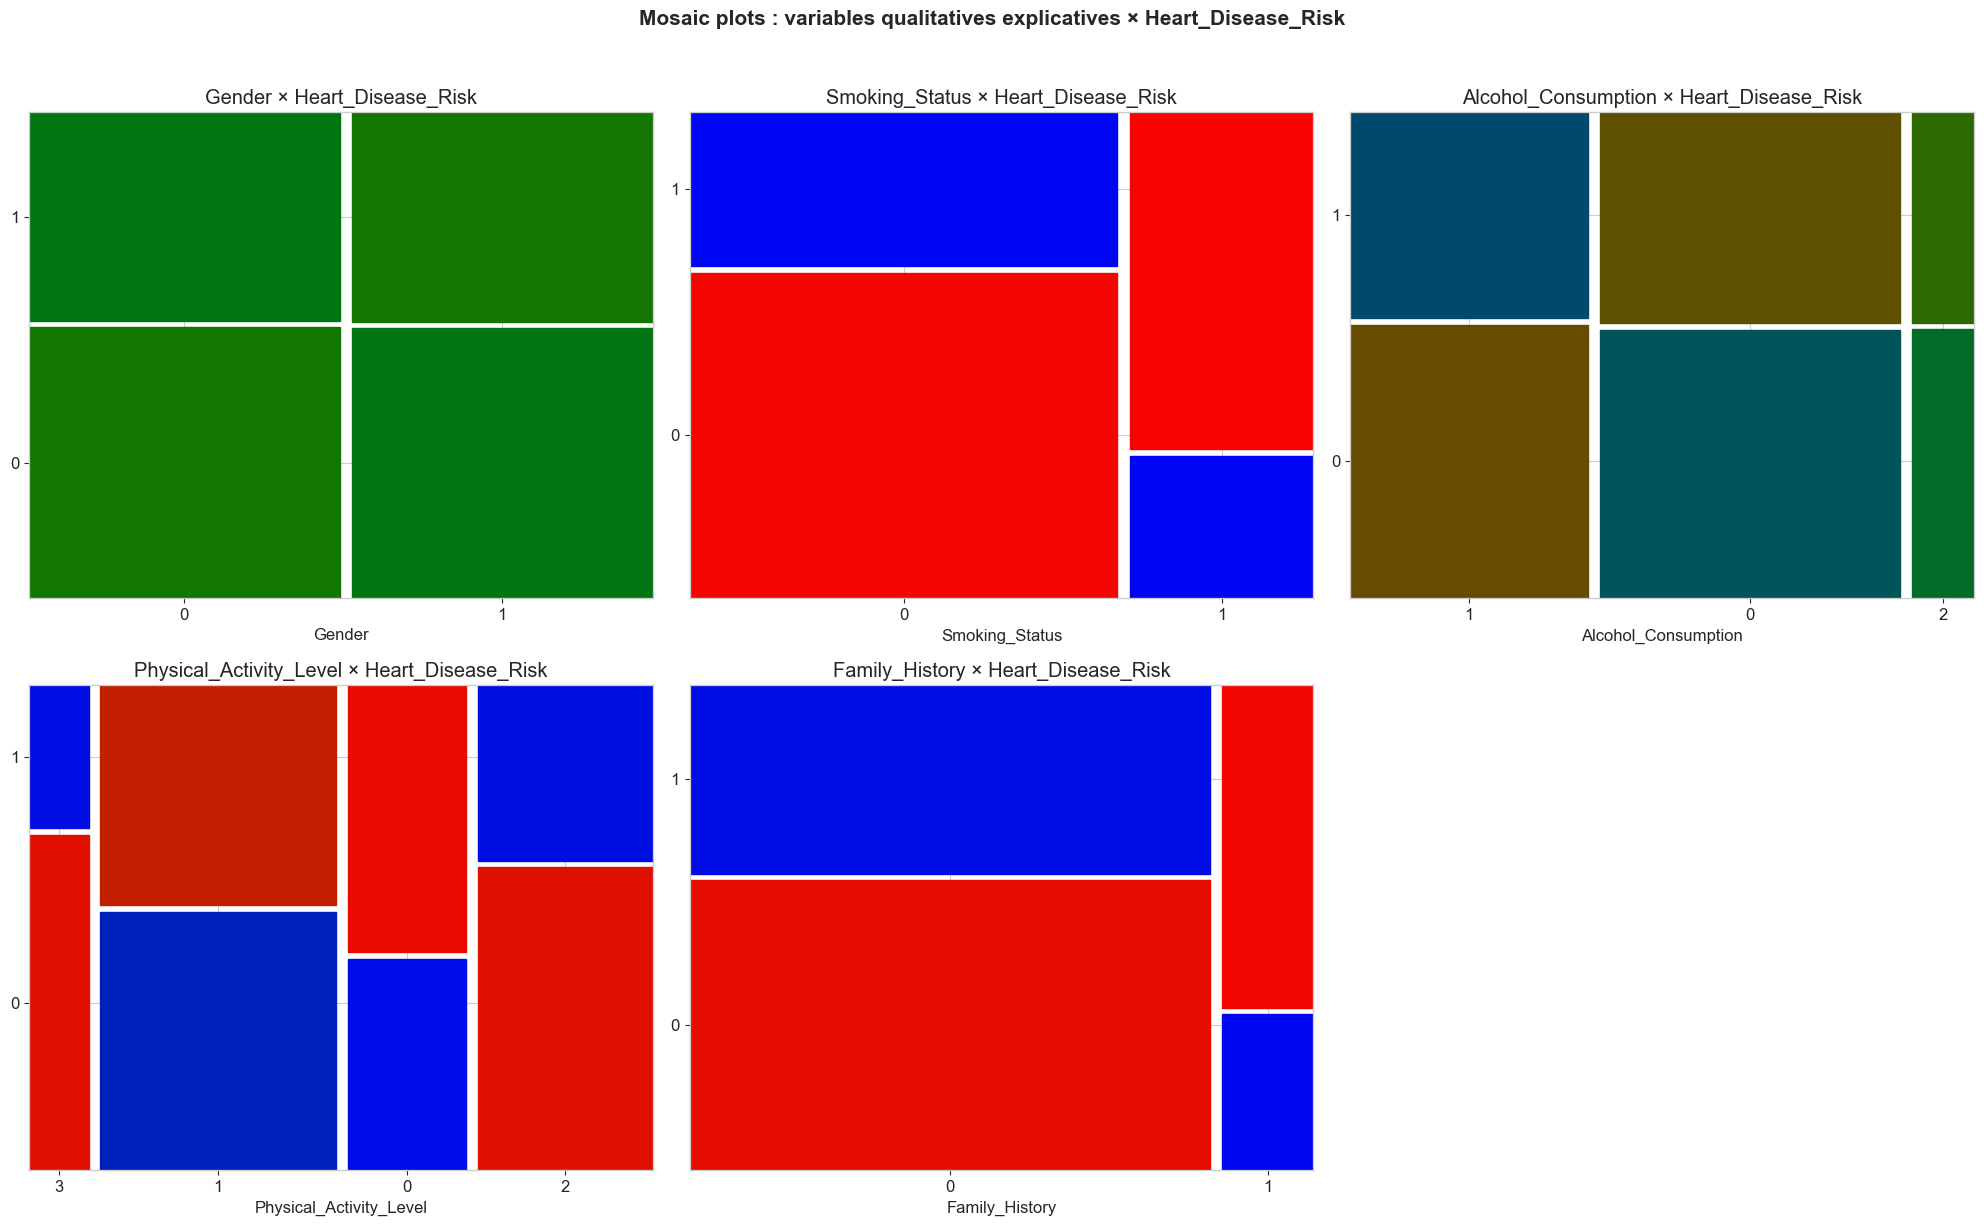

In [62]:
from statsmodels.graphics.mosaicplot import mosaic

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, var in enumerate(var_qual_expl):
    mosaic(data, [var, "Heart_Disease_Risk"],
           ax=axes[i],
           title=f"{var} × Heart_Disease_Risk",
           labelizer=lambda k: '',
           statistic=True,
           gap=0.02)
    axes[i].set_xlabel(var)

# Le 6e sous-graphique reste vide (5 variables seulement)
axes[5].axis('off')

plt.suptitle("Mosaic plots : variables qualitatives explicatives × Heart_Disease_Risk",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [63]:
# Tableau récapitulatif : test du χ² et V de Cramér par variable
chi2_results = []
for var in var_qual_expl:
    ct = pd.crosstab(data[var], data["Heart_Disease_Risk"])
    chi2, p_value, dof, expected = chi2_contingency(ct)
    cramer = np.sqrt(chi2 / (len(data) * (min(ct.shape) - 1)))
    chi2_results.append({
        "Variable": var,
        "chi2": round(chi2, 2),
        "ddl": dof,
        "p-value": f"{p_value:.2e}",
        "V de Cramer": round(cramer, 3),
        "Significatif (alpha=0.05)": "Oui" if p_value < 0.05 else "Non"
    })

chi2_df = pd.DataFrame(chi2_results).sort_values("V de Cramer", ascending=False).reset_index(drop=True)
chi2_df

,Variable,chi2,ddl,p-value,V de Cramer,Significatif (alpha=0.05)
0,Smoking_Status,1861.94,1,0.00e+00,0.352,Oui
1,Family_History,606.88,1,5.34e-134,0.201,Oui
2,Physical_Activity_Level,398.85,3,3.93e-86,0.163,Oui
3,Alcohol_Consumption,1.34,2,5.11e-01,0.009,Non
4,Gender,0.01,1,9.03e-01,0.001,Non


**Interprétation :**

Code couleur : rouge = sur-représenté par rapport à l'indépendance (résidu de Pearson positif), bleu = sous-représenté, neutre = pas d'écart. Le V de Cramér mesure la force d'association (0 = indépendance, 1 = parfaite). Seuils usuels : moins de 0.10 négligeable, 0.10 à 0.30 faible à modéré, 0.30 à 0.50 modéré à fort.

Trois variables significativement liées au risque (p < 0.05) :
- `Smoking_Status` (V = 0.35) : association la plus forte, deux fois supérieure à la suivante. Inversion nette des couleurs entre non-fumeurs (HDR=0 sur-représenté) et fumeurs (HDR=1 sur-représenté).
- `Family_History` (V = 0.20) : même type d'inversion sur la modalité minoritaire (15% avec antécédent). La largeur des colonnes reflète la fréquence des modalités, pas la force de l'association.
- `Physical_Activity_Level` (V = 0.16) : effet gradué, les actifs (niveaux 2 et 3) protecteurs, les inactifs (0 et 1) à risque.

Deux variables sans signal :
- `Alcohol_Consumption` (V = 0.009, p = 0.51) : rectangles neutres sur les 3 modalités, aucune association. Le test du χ² confirme que les variations visibles ne sont que du bruit.
- `Gender` (V = 0.001, p = 0.90) : aucun effet, rectangles tous neutres.

Implications pour la modélisation :
- Privilégier `Smoking_Status`, `Family_History` et `Physical_Activity_Level` : elles devraient avoir les coefficients ou importances les plus élevés.
- `Alcohol_Consumption` et `Gender` sont conservées mais devraient être filtrées par sélection de variables ou ressortir avec une importance quasi-nulle.
- Avec les variables quantitatives discriminantes de 3.2 (Age, BMI, pressions artérielles, cholestérol), le panorama des prédicteurs de la classification est complet.

## 4. Analyse en Composantes Principales (ACP)

L'ACP permet de résumer l'information contenue dans les variables quantitatives en un nombre réduit de composantes. On cherche à :
- Visualiser les données en 2D
- Identifier les variables qui contribuent le plus à la variance
- Détecter des structures ou groupements dans les données

**Remarque :** on inclut ici les 12 variables quantitatives (y compris `Cholesterol_LDL`, qui sera la cible de la régression) pour avoir une vue descriptive globale du jeu de données. Pour la modélisation de la régression, `Cholesterol_LDL` sera bien sûr retirée des features.

**Remarque importante :** l'ACP est une méthode **non supervisée**. Elle calcule les directions de variance maximale dans X sans utiliser les cibles Y. Ses conclusions sont donc descriptives (structure interne de X) et ne disent rien directement sur les variables utiles à la prédiction. Cette question sera traitée par les modèles supervisés à venir.

In [64]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardisation (obligatoire pour l'ACP car les variables n'ont pas les mêmes unités)
X_quant = data[var_quant].values
scaler_acp = StandardScaler()
X_scaled = scaler_acp.fit_transform(X_quant)

In [65]:
# ACP complète
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Variance expliquée
print("Variance expliquée par composante :")
for i, var_exp in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var_exp:.4f} ({var_exp*100:.1f}%)")
print(f"\nVariance cumulée : {pca.explained_variance_ratio_.cumsum()}")

Variance expliquée par composante :
  PC1: 0.2432 (24.3%)
  PC2: 0.1698 (17.0%)
  PC3: 0.1234 (12.3%)
  PC4: 0.0882 (8.8%)
  PC5: 0.0837 (8.4%)
  PC6: 0.0829 (8.3%)
  PC7: 0.0756 (7.6%)
  PC8: 0.0572 (5.7%)
  PC9: 0.0463 (4.6%)
  PC10: 0.0157 (1.6%)
  PC11: 0.0137 (1.4%)
  PC12: 0.0004 (0.0%)

Variance cumulée : [0.24322636 0.41298443 0.53634286 0.6245891  0.70824672 0.79114467
 0.86669904 0.92386745 0.97020586 0.98594379 0.99964865 1.        ]


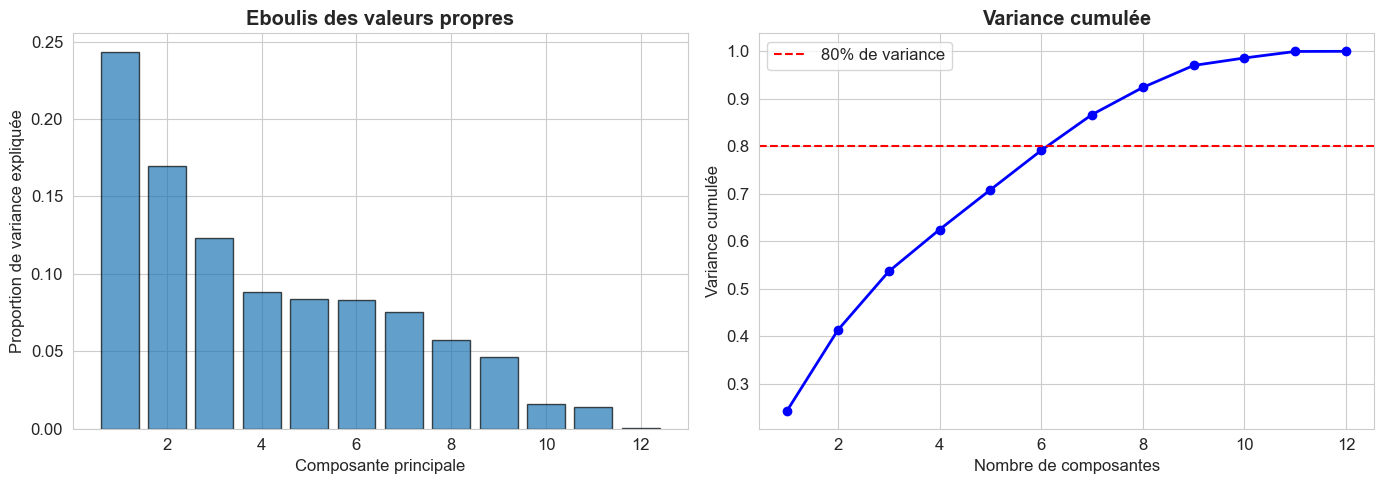

In [66]:
# Eboulis des valeurs propres (scree plot)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Variance expliquée par composante
ax1.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_,
        alpha=0.7, edgecolor='black')
ax1.set_xlabel("Composante principale")
ax1.set_ylabel("Proportion de variance expliquée")
ax1.set_title("Eboulis des valeurs propres", fontweight='bold')

# Variance cumulée
ax2.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_.cumsum(),
         'bo-', linewidth=2)
ax2.axhline(y=0.8, color='r', linestyle='--', label='80% de variance')
ax2.set_xlabel("Nombre de composantes")
ax2.set_ylabel("Variance cumulée")
ax2.set_title("Variance cumulée", fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

**Interprétation :**

La première composante (PC1) n'explique que 24.3% de la variance, et les deux premières ensemble seulement 41.3%. Il faut 7 composantes pour atteindre 80% de variance cumulée. L'éboulis ne présente pas de coude net : les contributions décroissent progressivement sans rupture franche.

Cela signifie que l'information est dispersée sur de nombreuses dimensions et qu'il n'existe pas de structure simple permettant de résumer les données en 2 ou 3 composantes. Ce résultat est cohérent avec ce qu'on a observé dans l'analyse bivariée : les corrélations entre variables sont modérées et concernent des groupes de variables distincts (pression artérielle, cholestérol, morphologie), sans axe dominant commun.

**Implication modélisation :** une PCA en pré-traitement (pour réduire la dimensionnalité avant les modèles) n'apporterait rien d'intéressant ici, il faudrait garder ~7 composantes pour ne pas perdre d'information, soit plus de la moitié des 12 variables d'origine, ce qui rend la réduction de dimensionnalité peu intéressante. On laissera donc les modèles travailler directement sur les variables originales.

### Cercle des corrélations

#### Règles de lecture

- Flèche longue (proche du cercle unité) : variable bien représentée sur le plan PC1-PC2.
- Flèche courte (proche du centre) : variable dont l'information est sur d'autres axes (PC3+), à ignorer pour ce plan.
- Même direction (angle proche de 0°) : corrélation positive forte.
- Directions opposées (angle proche de 180°) : corrélation négative forte.
- Directions perpendiculaires (angle proche de 90°) : variables non corrélées.

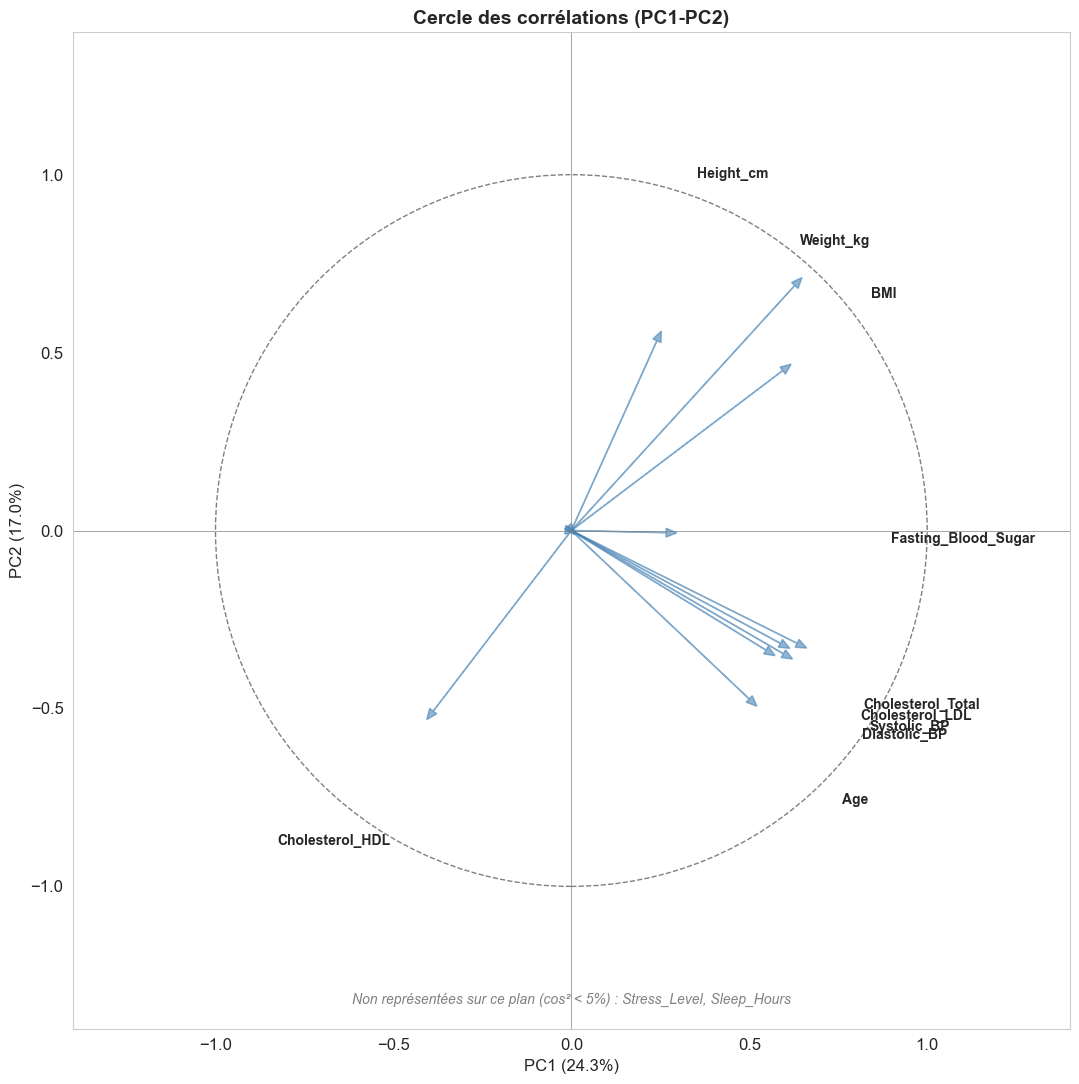

In [67]:
# Cercle des corrélations (axes PC1-PC2) avec labels placés en périphérie pour la lisibilité
import numpy as np

fig, ax = plt.subplots(figsize=(11, 11))

# Calcul des loadings = corrélations entre variables et composantes
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Tracé des flèches
for i, var in enumerate(var_quant):
    x, y = loadings[i, 0], loadings[i, 1]
    ax.arrow(0, 0, x, y, head_width=0.025, head_length=0.03,
             fc='steelblue', ec='steelblue', alpha=0.6,
             length_includes_head=True)

# Placement des labels en périphérie du cercle pour éviter les superpositions
radii = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
angles = np.arctan2(loadings[:, 1], loadings[:, 0])

# Variables bien représentées (cos² >= 0.05) : label placé radialement à l'extérieur
near_origin_vars = []
for i, var in enumerate(var_quant):
    cos2 = radii[i]**2
    if cos2 >= 0.05:
        label_r = 1.10
        label_x = label_r * np.cos(angles[i])
        label_y = label_r * np.sin(angles[i])
        ax.text(label_x, label_y, var, fontsize=10,
                ha='center', va='center', fontweight='bold')
    else:
        near_origin_vars.append(var)

# Variables non représentées : liste compacte en bas
if near_origin_vars:
    ax.text(0, -1.32,
            "Non représentées sur ce plan (cos² < 5%) : " + ", ".join(near_origin_vars),
            fontsize=10, ha='center', va='center', style='italic', color='gray')

# Cercle unité
circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--', linewidth=1)
ax.add_patch(circle)

ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=12)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=12)
ax.set_title("Cercle des corrélations (PC1-PC2)", fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.grid(False)
plt.tight_layout()
plt.show()

In [68]:
# Tableau des loadings et qualité de représentation sur PC1-PC2
loadings_df = pd.DataFrame({
    'corr PC1': loadings[:, 0].round(3),
    'corr PC2': loadings[:, 1].round(3),
    'cos² plan PC1-PC2': (loadings[:, 0]**2 + loadings[:, 1]**2).round(3)
}, index=var_quant).sort_values('cos² plan PC1-PC2', ascending=False)

loadings_df

,corr PC1,corr PC2,cos² plan PC1-PC2
Weight_kg,0.648,0.711,0.925
BMI,0.618,0.468,0.600
Cholesterol_Total,0.661,-0.330,0.546
Systolic_BP,0.622,-0.361,0.517
Age,0.522,-0.494,0.516
Cholesterol_LDL,0.614,-0.331,0.486
Diastolic_BP,0.572,-0.352,0.451
Cholesterol_HDL,-0.406,-0.531,0.447
Height_cm,0.253,0.560,0.378
Fasting_Blood_Sugar,0.296,-0.007,0.088


**Interprétation :**

Plan PC1-PC2 partiel (41% de la variance), on lit les grandes tendances et on s'appuie sur le tableau des loadings pour la précision.

- PC1 : axe "cardiovasculaire et corpulence". Age, BP, cholestérol Total/LDL, Weight et BMI sont corrélés positivement, HDL en miroir.
- PC2 : oppose la "morphologie" (Weight, Height, BMI en haut) à "l'âge et le métabolisme" (Age, BP, cholestérol en bas).

Trois clusters cohérents avec la heatmap 3.1.1 ressortent : cardiovasculaire (bas-droite), morphologique (haut-droite), HDL (bas-gauche, anti-corrélé au cardiovasculaire).

`Stress_Level`, `Sleep_Hours` et `Fasting_Blood_Sugar` ont cos² < 5% : non représentés sur ce plan, leur variance vit sur PC3+.

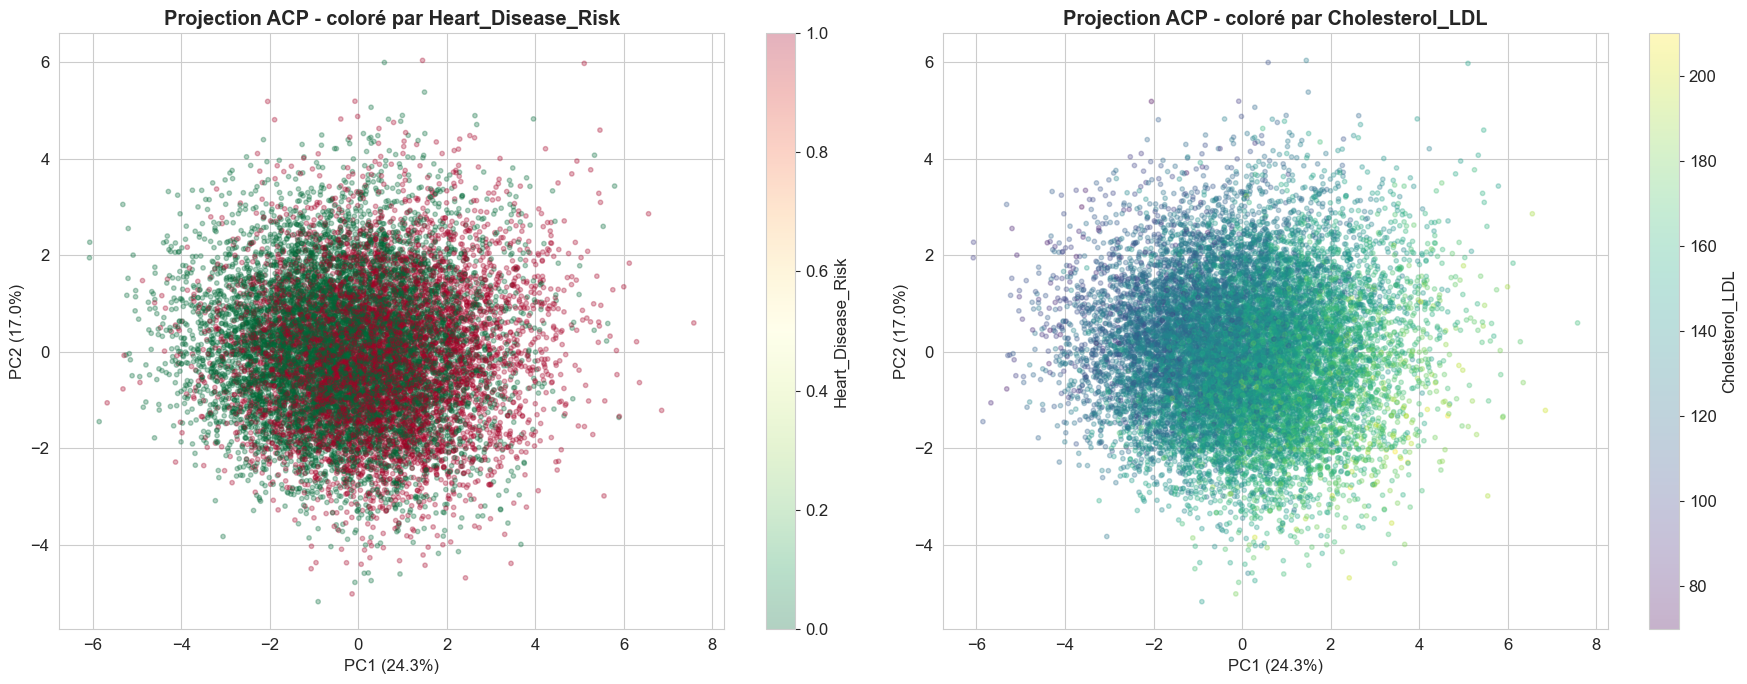

In [69]:
# Projection des individus colorés par Heart_Disease_Risk
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Coloré par Heart_Disease_Risk
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1],
                       c=data["Heart_Disease_Risk"].astype(int), cmap='RdYlGn_r',
                       alpha=0.3, s=10)
ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax1.set_title("Projection ACP - coloré par Heart_Disease_Risk", fontweight='bold')
plt.colorbar(scatter1, ax=ax1, label="Heart_Disease_Risk")

# Coloré par Cholesterol_LDL
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1],
                       c=data["Cholesterol_LDL"], cmap='viridis',
                       alpha=0.3, s=10)
ax2.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax2.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax2.set_title("Projection ACP - coloré par Cholesterol_LDL", fontweight='bold')
plt.colorbar(scatter2, ax=ax2, label="Cholesterol_LDL")

plt.tight_layout()
plt.show()

**Interprétation :**

Les deux projections montrent des nuages de points uniformément mélangés. Aucune séparation nette, ni pour `Heart_Disease_Risk` (points rouges et verts entremêlés), ni pour `Cholesterol_LDL`.

C'est cohérent avec le cercle des corrélations : PC1-PC2 captent surtout les clusters cardiovasculaire et morphologique, qui sont les directions de variance dominantes dans X. L'ACP étant non supervisée, elle ne regarde pas les cibles Y, donc ses axes ne sont pas garantis de séparer HDR ou d'expliquer LDL. Les variables vraiment utiles seront révélées par les modèles supervisés (coefficients, importances), pas par l'ACP.

Conclusion sur l'ACP : Elle confirme la structure interne du jeu (groupes de variables corrélées, variance dispersée) sans permettre de réduire la dimensionnalité ni de prédire les cibles.

L'absence de séparation en 2D ne préjuge en rien des performances en haute dimension. Une régression logistique sur toutes les features peut très bien séparer les classes même si PC1-PC2 ne le fait pas. Le gain éventuel des modèles non linéaires reste une question empirique à trancher à la modélisation.

## 5. Synthèse de l'analyse exploratoire

Cette synthèse dresse le bilan de tout ce que l'analyse exploratoire nous a appris, organisé selon les deux tâches du projet et les enseignements transverses utiles pour la modélisation à venir.

### Le jeu de données

Le jeu est propre : 15 000 patients, 19 variables, aucune valeur manquante, distributions des quantitatives globalement symétriques, classes 56.4% / 43.6% pour `Heart_Disease_Risk` (raisonnablement équilibré). Aucune transformation préalable (log, racine carrée, suppression d'outliers) n'est nécessaire, on travaillera directement sur les variables brutes (avec standardisation pour les modèles qui en ont besoin).

### Pour la classification sur `Heart_Disease_Risk`

Le risque cardiaque est un phénomène multifactoriel : aucune variable seule ne le prédit, mais plusieurs apportent un signal modéré qui devra être combiné.

- Variables quantitatives discriminantes (3.2.2) : `Age` (la plus discriminante), `Systolic_BP`, `Diastolic_BP`, `Cholesterol_Total`, `Cholesterol_LDL`, `BMI`, `Weight_kg`, `Fasting_Blood_Sugar`.
- Variables qualitatives discriminantes (3.3.2) : `Smoking_Status` (V = 0.35) domine largement, devant `Family_History` (V = 0.20) et `Physical_Activity_Level` (V = 0.16).
- Variables sans signal : `Gender`, `Alcohol_Consumption`, `Height_cm`, `Cholesterol_HDL`, `Stress_Level`, `Sleep_Hours`.

### Pour la régression sur `Cholesterol_LDL`

La situation est radicalement différente de la classification.

`Cholesterol_Total` est massivement corrélé à LDL (r = 0.83), relation quasi-déterministe, attendue puisque LDL est par construction une composante du cholestérol total. Toute régression incluant Total dominera mécaniquement et masquera le pouvoir prédictif des autres variables. 

- Autres prédicteurs quantitatifs (3.1.2) : `Age` (r = 0.36), puis BMI, pression artérielle, poids avec des corrélations modestes (0.10 < |r| < 0.18). `Stress_Level`, `Sleep_Hours`, `Height_cm` sont totalement décorrélées.
- Aucune variable qualitative n'est associée à LDL (3.2.3, ANOVA F-test, tous p > 0.38). Contraste fort avec HDR : pour la régression LDL, les variables comportementales et héréditaires apportent un signal nul.

### Enseignements transverses

- Multicolinéarité (3.1.1) : trois paires fortement corrélées, `Weight`/`BMI`, `Systolic`/`Diastolic BP`, et `Cholesterol_Total`/`LDL` (redondance critique pour la régression). Les qualitatives explicatives sont en revanche totalement indépendantes entre elles (3.3.1).
- Pas de confondants (3.2.1) : les qualitatives n'ont pas d'effet marqué sur les quantitatives explicatives, l'interprétation des coefficients linéaires sera directe.
- ACP peu informative : variance dispersée sur 7+ composantes, pas de structure 2D séparante. Une PCA en pré-traitement n'apportera rien.

### Bilan pour la modélisation à venir

| Question | Réponse anticipée |
|---|---|
| Transformer les variables (log, scaling) ? | Non, sauf standardisation pour SVM / KNN / réseaux de neurones |
| Imputer des valeurs manquantes ? | Non (aucune) |
| Rééquilibrer les classes HDR ? | Non (56/44, suffisamment équilibré) |
| Pénaliser les modèles linéaires (Ridge/Lasso) ? | Oui, notamment à cause des 3 paires fortement corrélées et de la régression LDL où beaucoup de features sont du bruit |
| Faire de la sélection de variables ? | Oui, particulièrement utile pour la régression LDL (qualitatives + variables faiblement corrélées) |
| Linéaire vs non linéaire, qu'attendre ? | Question empirique à trancher par la comparaison. L'ACP ne préjuge en rien : une régression logistique sur les 17 features peut très bien rivaliser avec un Random Forest même si PC1-PC2 ne sépare pas |
| Modèles à comparer (sujet) | Linéaires (avec/sans pénalisation, avec/sans sélection), SVM/SVR, arbre optimal (CART), Random Forest, Boosting, Réseaux de neurones |

Cette analyse exploratoire fournit donc des prédictions vérifiables pour la phase de modélisation : on saura, en regardant les importances/coefficients des modèles, si les variables qu'on a identifiées comme discriminantes ressortent bien, si `Cholesterol_Total` domine la régression LDL comme prévu, et si les variables sans signal sont effectivement filtrées par sélection ou pénalisation. 

## 6. Préparation des données pour la modélisation

On prépare maintenant les données pour les algorithmes de ML : encodage one-hot des variables qualitatives, séparation train/test, et standardisation.

### One-hot encoding des variables qualitatives explicatives

On transforme les variables catégorielles en indicatrices binaires (dummy variables). Pour les variables binaires, on supprime une modalité de référence afin d'éviter la multicolinéarité parfaite.

In [70]:
# One-hot encoding
dataDum = pd.get_dummies(data[["Gender", "Smoking_Status", "Alcohol_Consumption",
                                "Physical_Activity_Level", "Family_History"]],
                         drop_first=True)
dataDum.head()

,Gender_1,Smoking_Status_1,Alcohol_Consumption_1,Alcohol_Consumption_2,Physical_Activity_Level_1,Physical_Activity_Level_2,Physical_Activity_Level_3,Family_History_1
0,False,False,True,False,False,False,True,False
1,False,False,False,False,True,False,False,False
2,True,False,False,False,False,False,False,False
3,True,False,False,False,True,False,False,False
4,True,False,True,False,False,True,False,False


**Note :** On utilise `drop_first=True` qui supprime automatiquement la première modalité de chaque variable. Cela évite la multicolinéarité (si on a N modalités, N-1 indicatrices suffisent car la dernière est déductible des autres).

In [71]:
# Construction du jeu de données complet pour la modélisation
dataQuant = data[var_quant]
dataC = pd.concat([dataDum, dataQuant], axis=1)
print(f"Dimensions de dataC : {dataC.shape}")
dataC.head()

Dimensions de dataC : (15000, 20)


,Gender_1,Smoking_Status_1,Alcohol_Consumption_1,Alcohol_Consumption_2,Physical_Activity_Level_1,Physical_Activity_Level_2,Physical_Activity_Level_3,Family_History_1,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Stress_Level,Sleep_Hours
0,False,False,True,False,False,False,True,False,60,146.9,51.3,23.8,140,89,217,151,52,83,1,8
1,False,False,False,False,True,False,False,False,53,161.8,76.6,29.3,128,81,203,119,38,116,7,9
2,True,False,False,False,False,False,False,False,62,174.7,92.4,30.3,141,100,173,124,45,90,1,7
3,True,False,False,False,True,False,False,False,73,173.3,68.9,22.9,136,96,193,117,45,81,2,7
4,True,False,True,False,False,True,False,False,52,178.6,79.8,25.0,122,80,236,153,41,79,2,6


In [72]:
# Variables cibles
# Classification : risque d'accident cardiaque
Yb = data["Heart_Disease_Risk"]

# Régression : cholestérol LDL
Yr = data["Cholesterol_LDL"]

### Pourquoi séparer apprentissage et test ?

Évaluer un modèle sur les mêmes données qui ont servi à l'entraîner donne une vision biaisée de sa performance : un modèle peut très bien mémoriser ses observations d'apprentissage (surapprentissage) sans pour autant savoir prédire correctement sur de nouveaux patients.

On réserve donc 20 % du jeu de données, jamais vues pendant l'apprentissage, pour mesurer la capacité réelle de généralisation. C'est cet **échantillon test** qui sert ensuite de juge neutre pour comparer les différents modèles entre eux sur un terrain commun.


### Séparation train / test

On sépare les données en 80% d'apprentissage et 20% de test. Le `random_state` fixe la graine aléatoire pour garantir la reproductibilité.

**Important :** pour la régression sur `Cholesterol_LDL`, on retire cette variable des features (on ne peut pas utiliser la variable cible comme variable explicative).

In [73]:
from sklearn.model_selection import train_test_split

# Classification : prédire Heart_Disease_Risk (toutes les features)
X_train, X_test, Y_train_AVC, Y_test_AVC = train_test_split(
    dataC, Yb, test_size=3000, random_state=11)

# Régression : prédire Cholesterol_LDL (on la retire des features)
X_train_r, X_test_r, Y_train_cholest, Y_test_cholest = train_test_split(
    dataC.drop("Cholesterol_LDL", axis=1), Yr, test_size=3000, random_state=11)

print(f"Classification - Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Régression     - Train: {X_train_r.shape}, Test: {X_test_r.shape}")

Classification - Train: (12000, 20), Test: (3000, 20)
Régression     - Train: (12000, 19), Test: (3000, 19)


### Standardisation

Certains algorithmes (réseaux de neurones, SVM, KNN) sont sensibles à l'échelle des variables. On standardise les features (moyenne = 0, écart-type = 1).

**Important :** on calcule les paramètres (moyenne, écart-type) uniquement sur le train, puis on applique la même transformation au test. Cela évite toute fuite d'information du test vers le train.

In [74]:
from sklearn.preprocessing import StandardScaler

# Standardisation pour la classification
scaler = StandardScaler()
scaler.fit(X_train)
Xr_train = scaler.transform(X_train)
Xr_test = scaler.transform(X_test)

# Standardisation pour la régression
scaler_r = StandardScaler()
scaler_r.fit(X_train_r)
Xr_train_r = scaler_r.transform(X_train_r)
Xr_test_r = scaler_r.transform(X_test_r)

print("Standardisation effectuée.")
print(f"Moyenne des features (train classif) : {Xr_train.mean(axis=0)[:3].round(6)} ...")
print(f"Ecart-type des features (train classif) : {Xr_train.std(axis=0)[:3].round(6)} ...")

Standardisation effectuée.
Moyenne des features (train classif) : [0. 0. 0.] ...
Ecart-type des features (train classif) : [1. 1. 1.] ...


---

Les données sont maintenant prêtes pour la modélisation. On dispose de :
- `X_train`, `X_test` / `Xr_train`, `Xr_test` : features pour la classification (brutes / standardisées)
- `X_train_r`, `X_test_r` / `Xr_train_r`, `Xr_test_r` : features pour la régression (brutes / standardisées)
- `Y_train_AVC`, `Y_test_AVC` : cible classification
- `Y_train_cholest`, `Y_test_cholest` : cible régression

#  I : Problème de classification: Prédiction du risque d'accident cardiaque

Dans cette première partie on considère le problème de la prédiction la variable `Heart_Disease_Risk` à partir des autres variables du point de vue de l'apprentissage automatique, c'est-à-dire en nous concentrant sur les performances du modèle. L'objectif est de déterminer les meilleures performances que nous pouvons attendre, et les modèles qui les atteignent. C'est un problème de classification binaire, car on rappelle que cette variable prend 2 modalités: 0 = risque faible, 1 = risque élevé.


## 1. Premier modèle: Régression logistique

On commence par une régression logistique simple, utilisée comme modèle de référence pour la classification. Ce modèle permet d'obtenir une première mesure de performance sur l'échantillon test et servira ensuite de point de comparaison avec les versions pénalisées, les méthodes de sélection de variables et les modèles plus complexes.

### 1.1 Modèle sans sélection de variable ni pénalisation

In [25]:
# On fit les données avec le modèle de régression logistique du package sklearn
logit_simple = linear_model.LogisticRegression()
logit_simple.fit(Xr_train, Y_train_AVC)

# Prédiction des classes pour les métriques classiques
y_pred = logit_simple.predict(Xr_test)

# Erreur probabiliste adaptée à la régression logistique
print("Log-loss =", log_loss(Y_test_AVC, logit_simple.predict_proba(Xr_test)))

Log-loss = 0.5292518892372657


In [26]:
print(f"Accuracy : {accuracy_score(Y_test_AVC, y_pred):.3f}")
# matrice de confusion
table=pd.crosstab(y_pred,Y_test_AVC)
print(table)

Accuracy : 0.732
Heart_Disease_Risk     0    1
row_0                        
0                   1362  496
1                    308  834


Le modèle a donc une précision de 73.2%. Comme le montre la table de contingence, le modèle semble particulièrement avoir du mal à détecter les patients qui ont un risque d'arrêt cardiaque élevé. Pour palier ce problème, une solution est d'augmenter la sensibilité du modèle, autrement dit d'abaisser la valeur du seuil à partir duquel on estime que le patient présente un risque élevé d'arrêt cardiaque. Toutefois, comme on peut le voir grâce à la courbe ROC ci-dessous, cet ajustement augmente sensiblement le taux de faux positifs (les patients qui se voient prédire un risque élevé à tort). L'aire sous la courbe est de 0.81, ce qui fournit une première référence en vue de comparer les prochains modèles de classification.

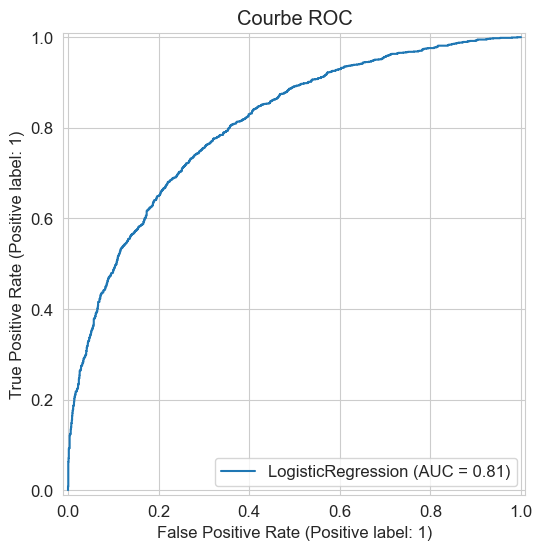

In [27]:
RocCurveDisplay.from_estimator(logit_simple, Xr_test, Y_test_AVC)
plt.title("Courbe ROC")
plt.show()

### 1.2 Modèle avec pénalisation LASSO

Comme nous l'avons vu dans la partie d'analyse exploratoire, certaines variables semblent avoir très peu d'influence sur le risque d'arrêt cardiaque, notamment `Height_cm`, `Cholesterol_HDL`, `Stress_Level` et `Sleep_Hours`. Une première méthode pour la sélection de variable est d'utiliser un paramètre de pénalisation LASSO. Pour optimiser la valeur de ce paramètre, on le choisit parmi une liste de valeurs pré-établies (entre 1 et 4) et on regarde celui qui minimise l'erreur du modèle.

In [28]:
# Optimisation du paramètre de pénalisation
# grille de valeurs
param=[{"C":[1,1.2,1.5,1.7,2,3,4]}]
logit = GridSearchCV(LogisticRegression(penalty="l1",solver="liblinear"), param,cv=5,n_jobs=-1)
logitOpt=logit.fit(Xr_train, Y_train_AVC)  # GridSearchCV est lui-même un estimateur
# paramètre optimal
logitOpt.best_params_["C"]
print("Meilleur score = %f, Meilleur paramètre = %s" % (logitOpt.best_score_,logitOpt.best_params_))

Meilleur score = 0.739583, Meilleur paramètre = {'C': 1}


In [29]:
# Coefficients
logitLasso=LogisticRegression(penalty="l1",C=logitOpt.best_params_['C'],
                              solver="liblinear")
logitCoef=logitLasso.fit(Xr_train,Y_train_AVC).coef_
for var, coef in zip(X_train.columns, logitLasso.coef_[0]):
    print(f"{var}: {coef:.4f}")


Gender_1: -0.0440
Smoking_Status_1: 0.9001
Alcohol_Consumption_1: -0.0343
Alcohol_Consumption_2: -0.0189
Physical_Activity_Level_1: -0.2660
Physical_Activity_Level_2: -0.4640
Physical_Activity_Level_3: -0.4718
Family_History_1: 0.5459
Age: 0.2433
Height_cm: 0.0000
Weight_kg: 0.0551
BMI: 0.1496
Systolic_BP: 0.3429
Diastolic_BP: -0.0167
Cholesterol_Total: -0.0378
Cholesterol_LDL: 0.2088
Cholesterol_HDL: -0.0522
Fasting_Blood_Sugar: 0.3040
Stress_Level: 0.2961
Sleep_Hours: -0.1016


Text(0.5, 1.0, 'Coefficients du modèle lasso')

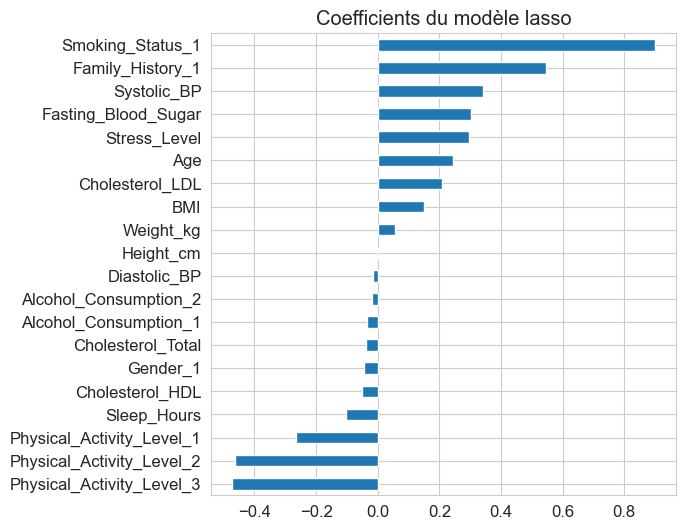

In [30]:
coef = pd.Series(logitCoef[0], index = X_train.columns)
imp_coef = coef.sort_values()
plt.rcParams['figure.figsize'] = (6.0, 6.0)
imp_coef.plot(kind = "barh")
plt.title(u"Coefficients du modèle lasso")

Le paramètre de pénalisation retenu est 1. Avec ce choix de paramètre, le coefficient de la variable `Height_cm` est mis à 0. Autrement dit, pour ce modèle et pour ce paramètre de pénalisation, l'influence de la taille du patient sur son risque de maladie cardiaque est négligeable. Par ailleurs, le modèle de régression logistique permet d'interpréter facilement le poids de chaque variable. D'après le précédent graphique, les principaux facteurs de risque de maladie cardiaque sont le fait de fumer, la présence d'antécédents familiaux, la pression artérielle systolique, la glycémie à jeun ou encore le niveau de stress. A l'inverse, il semblerait selon ce modèle que la pratique d'activités sportives ainsi qu'une quantité suffisante d'heures de sommeil permettent de faire diminuer le risque d'arrêt cardiaque.

In [31]:
# estimation de la précision sur l'échantillon de test
print("Précision de l'échantillon:",logitOpt.score(Xr_test, Y_test_AVC))
# Prévision
y_chap = logitOpt.predict(Xr_test)
# matrice de confusion
table=pd.crosstab(y_chap,Y_test_AVC)
print(table)

Précision de l'échantillon: 0.7326666666666667
Heart_Disease_Risk     0    1
row_0                        
0                   1362  494
1                    308  836


La précision du modèle avec pénalisation est identique à celle du précédent (régression logistique simple). Par ailleurs, on observe ci-dessous que les deux modèles obtenus (avec et sans pénalisation) ont la même courbe ROC. Il n'y en a donc pas un meilleur que l'autre. Le modèle LASSO permet toutefois de faciliter l'interprétabilité en réduisant le nombre de variables explicatives (une seule en moins dans ce cas-ci).

In [32]:
def comparer_ROC(modeles):
    plt.figure(figsize=(8, 6))

    for nom, modele in modeles.items():
        if hasattr(modele, "predict_proba"):
            y_score = modele.predict_proba(Xr_test)[:, 1]
        elif hasattr(modele, "decision_function"):
            y_score = modele.decision_function(Xr_test)
        else:
            print(f"{nom} ignoré : pas de predict_proba ni decision_function")
            continue

        fpr, tpr, _ = roc_curve(Y_test_AVC, y_score)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"{nom} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("Taux de faux positifs")
    plt.ylabel("Taux de vrais positifs")
    plt.title("Courbes ROC")
    plt.legend()
    plt.grid(True)
    plt.show()

### 1.3 Modèle avec pénalisation Ridge

Au lieu d'utiliser la norme L1 (pénalisation LASSO), on peut aussi tester une pénalisation Ridge, avec la norme L2. Comme pour le LASSO, on choisit le paramètre qui maximise l'aire sous la courbe ROC parmi une liste pré-établie de valeurs.

In [33]:
# Optimisation du C (inverse de la force de régularisation)
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

logit_l2 = GridSearchCV(
    LogisticRegression(penalty="l2", solver="lbfgs", max_iter=1000),
    param_grid, cv=5, scoring="roc_auc"
)
logit_l2.fit(Xr_train, Y_train_AVC)

print("Meilleur C :", logit_l2.best_params_['C'])


# estimation de la précision sur l'échantillon de test
print("Précision de l'échantillon:",logit_l2.score(Xr_test, Y_test_AVC))
# Prévision
y_chap = logit_l2.predict(Xr_test)
# matrice de confusion
table=pd.crosstab(y_chap,Y_test_AVC)
print(table)

Meilleur C : 0.1
Précision de l'échantillon: 0.8068222952591058
Heart_Disease_Risk     0    1
row_0                        
0                   1362  497
1                    308  833


Text(0.5, 1.0, 'Coefficients du modèle Ridge')

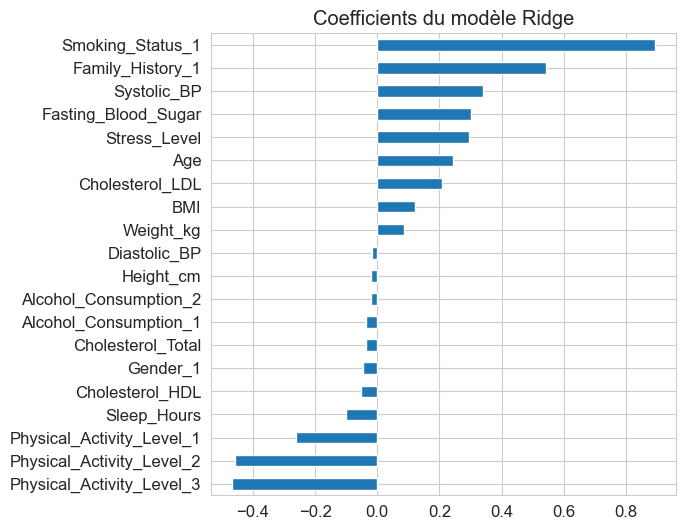

In [34]:
logitCoef = logit_l2.best_estimator_.coef_
coef = pd.Series(logitCoef[0], index = X_train.columns)
imp_coef = coef.sort_values()
plt.rcParams['figure.figsize'] = (6.0, 6.0)
imp_coef.plot(kind = "barh")
plt.title(u"Coefficients du modèle Ridge")

In [35]:
for var, coef in zip(X_train.columns, coef):
    print(f"{var}: {coef:.4f}")

Gender_1: -0.0442
Smoking_Status_1: 0.8938
Alcohol_Consumption_1: -0.0348
Alcohol_Consumption_2: -0.0195
Physical_Activity_Level_1: -0.2607
Physical_Activity_Level_2: -0.4574
Physical_Activity_Level_3: -0.4660
Family_History_1: 0.5421
Age: 0.2422
Height_cm: -0.0193
Weight_kg: 0.0875
BMI: 0.1230
Systolic_BP: 0.3412
Diastolic_BP: -0.0168
Cholesterol_Total: -0.0370
Cholesterol_LDL: 0.2070
Cholesterol_HDL: -0.0527
Fasting_Blood_Sugar: 0.3021
Stress_Level: 0.2943
Sleep_Hours: -0.1012


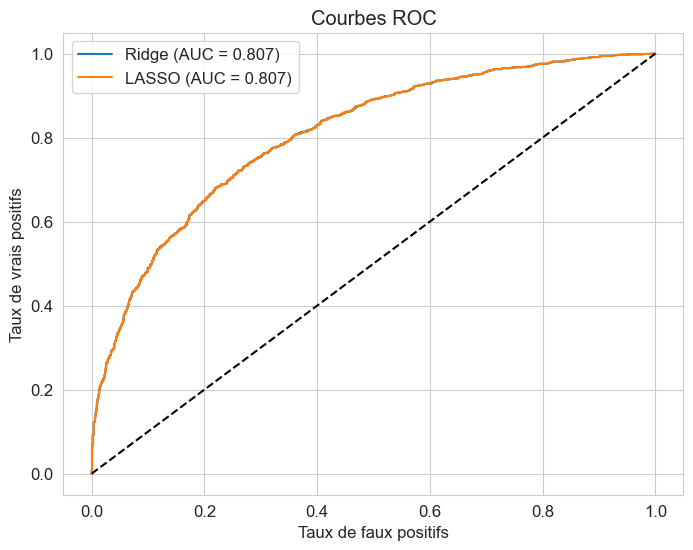

In [36]:
comparer_ROC({'Ridge':logit_l2,'LASSO':logitLasso})

Comme on peut le voir, la pénalité L2 a tendance à diminuer la valeur des paramètres de la regression, sans toutefois les mettre à 0 comme pour le LASSO. Les variables les plus importantes sont les mêmes que pour les deux précedents modèles. Néanmoins, sa courbe ROC est légèrement en-dessous des deux autres. La pénalité ridge produit donc un modèle légèrement moins performant.

### 1.4 Modèle avec pénalisation Elastic net

Pour finir, la dernière option de pénalisation est une combinaison des deux modèles vus précedemment, Lasso et Ridge, qu'on appelle Elastic Net. Il y a donc deux hyper-paramètres à optimiser

In [37]:
# ElasticNet requiert solver="saga"
param_grid_en = {
    'C':        [0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

logit_en = GridSearchCV(
    LogisticRegression(
        penalty="elasticnet", solver="saga",
        max_iter=2000
    ),
    param_grid_en, cv=5, scoring="roc_auc"
)
logit_en.fit(Xr_train, Y_train_AVC)

print("Meilleurs params :", logit_en.best_params_)



Meilleurs params : {'C': 0.1, 'l1_ratio': 0.9}


In [38]:
# estimation de la précision sur l'échantillon de test
print("Précision de l'échantillon:",logit_en.score(Xr_test, Y_test_AVC))
# Prévision
y_chap = logit_en.predict(Xr_test)
# matrice de confusion
table=pd.crosstab(y_chap,Y_test_AVC)
print(table)

Précision de l'échantillon: 0.8069767232452388
Heart_Disease_Risk     0    1
row_0                        
0                   1366  496
1                    304  834


Text(0.5, 1.0, 'Coefficients du modèle ElasticNet')

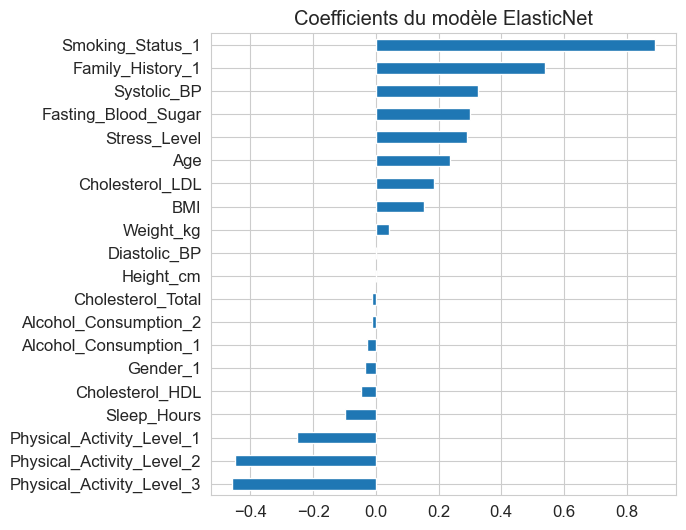

In [39]:
logitCoef = logit_en.best_estimator_.coef_
coef = pd.Series(logitCoef[0], index = X_train.columns)
imp_coef = coef.sort_values()
plt.rcParams['figure.figsize'] = (6.0, 6.0)
imp_coef.plot(kind = "barh")
plt.title(u"Coefficients du modèle ElasticNet")

In [40]:
for var, coef in zip(X_train.columns, logit_en.best_estimator_.coef_[0]):
    print(f"{var}: {coef:.4f}")


Gender_1: -0.0329
Smoking_Status_1: 0.8904
Alcohol_Consumption_1: -0.0292
Alcohol_Consumption_2: -0.0136
Physical_Activity_Level_1: -0.2505
Physical_Activity_Level_2: -0.4474
Physical_Activity_Level_3: -0.4574
Family_History_1: 0.5383
Age: 0.2354
Height_cm: 0.0000
Weight_kg: 0.0434
BMI: 0.1549
Systolic_BP: 0.3255
Diastolic_BP: 0.0000
Cholesterol_Total: -0.0112
Cholesterol_LDL: 0.1852
Cholesterol_HDL: -0.0462
Fasting_Blood_Sugar: 0.2991
Stress_Level: 0.2902
Sleep_Hours: -0.0968


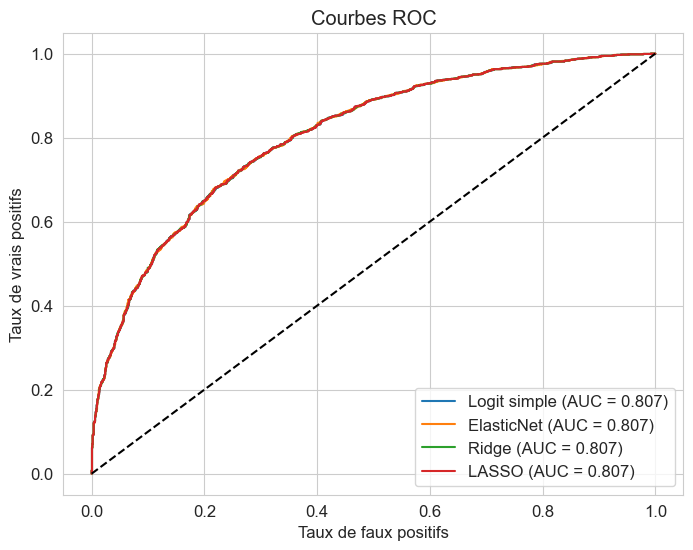

In [41]:
comparer_ROC({'Logit simple':logit_simple,'ElasticNet':logit_en,'Ridge':logit_l2,'LASSO':logitLasso})

Encore une fois, le modèle elastic net est légèrement moins performant que les deux meilleurs (sa courbe ROC est comparable avec celle de la pénalisation Ridge). Remarque: le score de précision des modèles Ridge et Elastic net est légèrement supérieur à celui des régressions logistiques simple et lasso. Ce paradoxe peut s'expliquer par le fait que les classes sont déséquilibrées: dans l'échantillon de test, il y a plus de patients sans risque de maladie cardiaque qu'avec. Les modèles Ridge et elastic net ont tendance à prédire légèrement plus de 0 (pas de risque de maladie cardiaque) que de 1, par rapport aux deux autres, mais ratent donc plus souvent les cas positifs.

### 1.5 Modèle avec sélection de variable

La fonction RFECV du package sklearn élimine récursivement les variables les moins importantes par validation croisée (avec 5 folds), sur une régression sans pénalisation. On refit ensuite une logistique sans pénalisation sur les variables retenues, censées maximiser l'aire sous la courbe ROC.

In [42]:
# Estimateur de base pour le ranking (L2 pour la stabilité)
base_estimator = LogisticRegression(
    penalty=None, solver="lbfgs", max_iter=1000, C=1
)

selector = RFECV(
    estimator=base_estimator,
    step=1,              # retirer 1 variable par itération
    cv=5,
    scoring="roc_auc"
)
selector.fit(Xr_train, Y_train_AVC)

print("Variables sélectionnées :", selector.n_features_)
print("Masque :", selector.support_)

# Refit sans pénalisation sur les variables retenues
X_train_sel = selector.transform(Xr_train)
X_test_sel  = selector.transform(Xr_test)

logit_sel = LogisticRegression(
    penalty=None, solver="lbfgs", max_iter=1000
).fit(X_train_sel, Y_train_AVC)

Variables sélectionnées : 12
Masque : [False  True False False  True  True  True  True  True False False  True
  True False False  True False  True  True  True]


D'après le masque obtenu, l'algorithme RFECV a supprimé 8 variables: `Gender_1`, `Alcohol_Consumption_1`, `Height_cm`, `Weight_kg`, `Alcohol_Consumption_2`, `Diastolic_BP`, `Cholesterol_Total` et `Cholesterol_HDL`. C'est plutôt cohérent avec les résultats précedemment obtenus (les coefficients de toutes ces variables étaient proches de 0, ce qui indiquait une faible influence sur la prédiction). En terme d'interprétation, ce modèle simplifie l'analyse bien plus que la pénalisation Lasso, qui avait uniquement supprimé la variable `Height_cm`.

In [43]:
# estimation de la précision sur l'échantillon de test
print("Précision de l'échantillon:",logit_sel.score(X_test_sel, Y_test_AVC))
# Prévision
y_chap = logit_sel.predict(X_test_sel)
# matrice de confusion
table=pd.crosstab(y_chap,Y_test_AVC)
print(table)

Précision de l'échantillon: 0.7323333333333333
Heart_Disease_Risk     0    1
row_0                        
0                   1360  493
1                    310  837


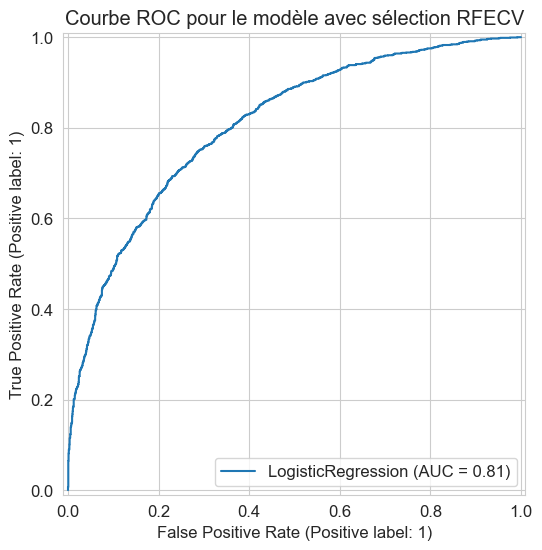

In [44]:
RocCurveDisplay.from_estimator(logit_sel, X_test_sel, Y_test_AVC)
plt.title("Courbe ROC pour le modèle avec sélection RFECV")
plt.show()

Le modèle avec sélection préliminaire de variable permet d'obtenir des performances comparables à une régression logistique simple ou avec pénalisation LASSO, tout en ayant seulement 12 variables explicatives au lieu de 19 ou 20. On peut donc considérer que c'est le meilleur modèle obtenu jusqu'à présent, en terme de performance et d'inteprétabilité.

## 2. KNN et SVM



Dans cette partie, on étudie deux méthodes de classification:
- le kNN (k-Nearest Neighbors)
- le SVM (Support Vector Machine).

Pour chaque méthode, comme pour les modèles précédents, on commence par optimiser les hyperparamètres sur l'échantillon d'apprentissage, avant de comparer la performance des modèles sur l'échantillon de test.

In [45]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
pd.set_option('display.max_columns', None)

### 2.1 kNN 

Le kNN classe une observation en regardant ses plus proches voisins. Le paramètre `k` règle le compromis biais / variance :
- petit `k` : frontière très flexible, variance forte
- grand `k` : frontière plus lisse, biais plus élevé.

On sélectionne ici `n_neighbors`, `weights` et `metric` par GridSearchCV sur le train uniquement.

La lecture de cette courbe demande un peu de prudence. Ici, le score d'entraînement reste égal à 1 pour toutes les valeurs de `k` car le meilleur modèle utilise une pondération par la distance (`weights='distance'`) : chaque observation du train est alors son propre plus proche voisin, ce qui conduit à une classification parfaite sur l'échantillon d'apprentissage. La courbe la plus informative est donc celle de validation croisée. On observe qu'elle progresse légèrement quand `k` augmente, ce qui suggère qu'un voisinage un peu plus large améliore la généralisation en réduisant la variance du modèle. Cela reste cohérent avec le compromis biais/variance vu en cours : des `k` trop petits rendent le modèle très sensible aux fluctuations locales, tandis que des `k` plus grands lissent davantage la frontière de décision.


In [ ]:
param_grid_knn = {
    'n_neighbors': [3, 20, 40, 60, 80, 100, 105, 110, 120, 122.5 ,  150 , 200, 225, 250, 275, 300],   # nombre de voisins
    'metric':      ['euclidean', 'manhattan'],
    'weights':     ['uniform', 'distance'],       # vote égal vs pondéré
                           
}

knn_clf_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='roc_auc',      # adapté aux classes déséquilibrées
    n_jobs=-1,              
    verbose=1,
    return_train_score=True
)

knn_clf_search.fit(Xr_train, Y_train_AVC)

print("Meilleurs paramètres :", knn_clf_search.best_params_)
print("Meilleur AUC (CV)    :", knn_clf_search.best_score_)

# Évaluation sur le test
print("Précision test       :", knn_clf_search.score(Xr_test, Y_test_AVC))

Fitting 5 folds for each of 64 candidates, totalling 320 fits


La validation croisée retient un kNN avec distance de Manhattan, pondération par la distance et `k = 275`.

Ce résultat montre que la règle `k ≈ √n` est seulement une heuristique : ici, un voisinage plus large généralise mieux. Comme `weights='distance'`, les voisins les plus proches restent les plus influents, même avec un grand nombre de voisins.

La performance est légèrement meilleure qu'avec `k = 250` ou `k = 300`, ce qui suggère un optimum autour de `275`.

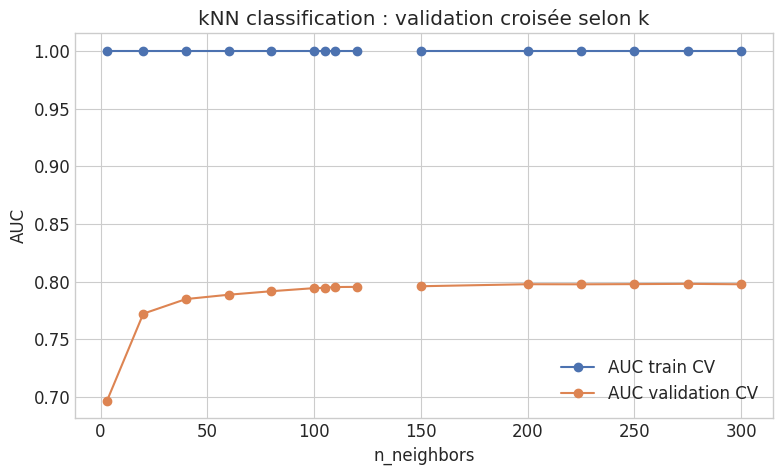

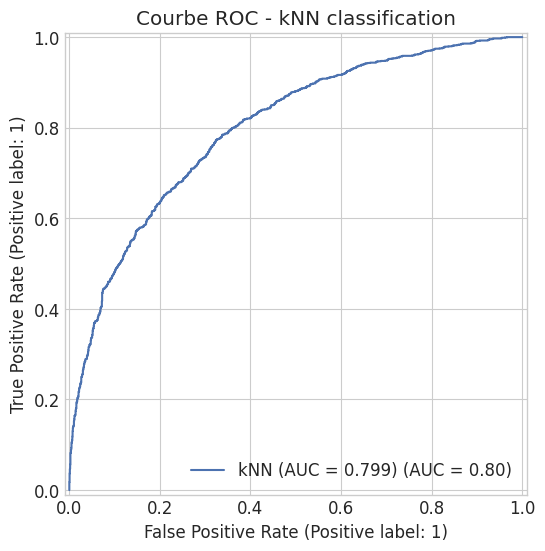

,k,AUC train CV,AUC validation CV
33,3.0,1.0,0.696799
35,20.0,1.0,0.772292
37,40.0,1.0,0.784951
39,60.0,1.0,0.788702
41,80.0,1.0,0.791749
43,100.0,1.0,0.794411
45,105.0,1.0,0.794721
47,110.0,1.0,0.795373
49,120.0,1.0,0.795496
51,122.5,NaN,NaN


In [ ]:
knn_clf_results = pd.DataFrame(knn_clf_search.cv_results_)

knn_clf_curve = knn_clf_results[
    (knn_clf_results['param_weights'] == knn_clf_search.best_params_['weights'])
    & (knn_clf_results['param_metric'] == knn_clf_search.best_params_['metric'])
].sort_values('param_n_neighbors')

plt.figure(figsize=(9, 5))
plt.plot(
    knn_clf_curve['param_n_neighbors'].astype(float),
    knn_clf_curve['mean_train_score'],
    marker='o',
    label='AUC train CV'
)
plt.plot(
    knn_clf_curve['param_n_neighbors'].astype(float),
    knn_clf_curve['mean_test_score'],
    marker='o',
    label='AUC validation CV'
)
plt.xlabel('n_neighbors')
plt.ylabel('AUC')
plt.title('kNN classification : validation croisée selon k')
plt.legend()
plt.show()

y_score_knn = knn_clf_search.predict_proba(Xr_test)[:, 1]
auc_knn = roc_auc_score(Y_test_AVC, y_score_knn)

RocCurveDisplay.from_predictions(
    Y_test_AVC,
    y_score_knn,
    name=f'kNN (AUC = {auc_knn:.3f})'
)
plt.title('Courbe ROC - kNN classification')
plt.show()

knn_clf_curve[['param_n_neighbors', 'mean_train_score', 'mean_test_score']].rename(columns={
    'param_n_neighbors': 'k',
    'mean_train_score': 'AUC train CV',
    'mean_test_score': 'AUC validation CV',
})

La validation croisée retient un kNN avec distance de Manhattan, pondération par la distance et `k = 275`. Le score de validation augmente nettement pour les petites valeurs de `k`, puis atteint un plateau autour de 0.80 d'AUC. Le choix de `k = 275` est donc légèrement meilleur que les valeurs voisines, mais les écarts restent faibles.

La courbe ROC confirme cette performance sur l'échantillon test, avec une AUC proche de 0.80. Le modèle discrimine donc correctement les deux classes, sans toutefois atteindre une séparation parfaite.

### 2.2. SVM 

Le SVM cherche un hyperplan séparateur à marge maximale. En pratique :
- `C` contrôle le compromis entre largeur de marge et erreurs tolérées
- avec un noyau RBF, `gamma` contrôle la flexibilité locale de la frontière
- un noyau trop flexible peut produire un surapprentissage, visible par un écart important entre score train et score de validation.

On compare ici un SVM linéaire et un SVM RBF dans un même `GridSearchCV`.

In [ ]:
cv_class = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Sous-échantillon pour rendre le SVM exécutable
X_svm_train, _, y_svm_train, _ = train_test_split(
    Xr_train,
    Y_train_AVC,
    train_size=4000,
    stratify=Y_train_AVC,
    random_state=42
)

svc_pipe = Pipeline([
    ('model', SVC(probability=False, cache_size=1000))
])

svc_grid = [
    {
        'model__kernel': ['linear'],
        'model__C': [0.1, 0.5, 1],
    },
    {
        'model__kernel': ['rbf'],
        'model__C': [0.5, 1],
        'model__gamma': ['scale', 0.01],
    },
]

start = time.perf_counter()

svc_search = GridSearchCV(
    svc_pipe,
    svc_grid,
    cv=cv_class,
    scoring='balanced_accuracy',
    n_jobs=-1,
    return_train_score=True,
)

svc_search.fit(X_svm_train, y_svm_train)
svc_time = time.perf_counter() - start

print("Meilleurs paramètres SVM :", svc_search.best_params_)
print("Balanced accuracy CV    :", round(svc_search.best_score_, 4))
print("Temps de recherche (s)  :", round(svc_time, 2))

# Évaluation sur le test complet
y_pred_svc = svc_search.predict(Xr_test)
y_score_svc = svc_search.decision_function(Xr_test)

print("Balanced accuracy test  :", round(balanced_accuracy_score(Y_test_AVC, y_pred_svc), 4))
print("AUC test                :", round(roc_auc_score(Y_test_AVC, y_score_svc), 4))

Meilleurs paramètres SVM : {'model__C': 1, 'model__kernel': 'linear'}
Balanced accuracy CV    : 0.7194
Temps de recherche (s)  : 5.76
Balanced accuracy test  : 0.7216
AUC test                : 0.805


Le meilleur SVM retenu par validation croisée est un modèle linéaire avec `C = 1`. Il obtient une balanced accuracy moyenne de 0.719 en validation croisée et de 0.722 sur l'échantillon test, ce qui indique une performance stable entre apprentissage et test.

L'AUC test atteint 0.805, légèrement supérieure à celle du kNN. Le SVM linéaire semble donc mieux discriminer les deux classes, tout en restant relativement simple. La cellule suivante détaille les meilleures configurations testées pendant la validation croisée.

In [ ]:
svc_results = pd.DataFrame(svc_search.cv_results_)
svc_top = svc_results[['param_model__kernel', 'param_model__C', 'param_model__gamma', 'mean_train_score', 'mean_test_score', 'rank_test_score']].sort_values('rank_test_score').head(8)
svc_top

,param_model__kernel,param_model__C,param_model__gamma,mean_train_score,mean_test_score,rank_test_score
2,linear,1.0,NaN,0.726562,0.719390,1
0,linear,0.1,NaN,0.726826,0.719236,2
1,linear,0.5,NaN,0.726960,0.718660,3
4,rbf,0.5,0.01,0.722131,0.714209,4
6,rbf,1.0,0.01,0.725338,0.712374,5
3,rbf,0.5,scale,0.754223,0.712189,6
5,rbf,1.0,scale,0.776687,0.711499,7


Le tableau confirme que les meilleures configurations sont les SVM linéaires. Les trois valeurs de `C` testées donnent des scores de validation très proches, autour de 0.719, ce qui montre que le modèle est peu sensible au choix précis de la pénalisation dans cette grille.

Les modèles RBF obtiennent des scores de validation légèrement plus faibles. Avec `gamma='scale'`, l'écart entre le score train et le score validation augmente, ce qui suggère un modèle plus flexible mais moins généralisable. Le noyau linéaire est donc retenu comme meilleur compromis.

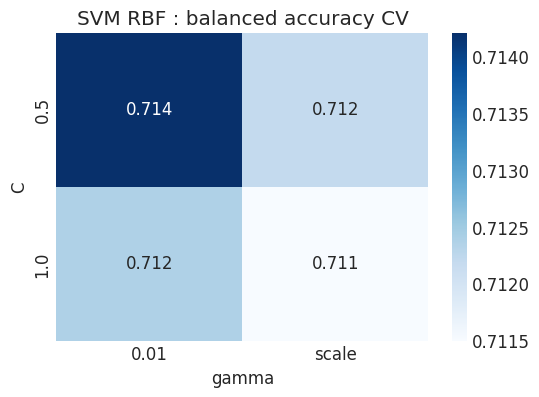

In [ ]:
svc_rbf = svc_results[svc_results['param_model__kernel'] == 'rbf'].copy()
if not svc_rbf.empty:
    rbf_pivot = svc_rbf.pivot_table(
        index='param_model__C',
        columns='param_model__gamma',
        values='mean_test_score'
    )
    plt.figure(figsize=(6, 4))
    sns.heatmap(rbf_pivot, annot=True, fmt='.3f', cmap='Blues')
    plt.title('SVM RBF : balanced accuracy CV')
    plt.xlabel('gamma')
    plt.ylabel('C')
    plt.show()

Le tableau et la heatmap montrent que les meilleures performances du SVM RBF sont obtenues avec `gamma = scale`, pour `C = 0.5` ou `C = 1`, avec une balanced accuracy de validation d’environ 0.719. Les autres valeurs de `gamma` donnent des scores légèrement plus faibles, autour de 0.710 à 0.715.

L’écart entre les configurations reste faible, ce qui indique que le SVM est assez peu sensible aux hyperparamètres testés dans cette grille. Le noyau RBF apporte un léger gain par rapport aux configurations moins adaptées, mais l’amélioration reste limitée. Les valeurs plus élevées de `C` ne donnent pas de meilleur résultat : avec `C = 2`, la performance diminue légèrement, ce qui suggère qu’un modèle plus flexible ne généralise pas mieux sur ces données.

In [ ]:
classification_models = {
    'kNN classification': knn_clf_search.best_estimator_,
    'SVM classification': svc_search.best_estimator_,
}

classification_results = []
for name, model in classification_models.items():
    y_pred = model.predict(Xr_test)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(Xr_test)[:, 1]
    else:
        y_score = model.decision_function(Xr_test)
    classification_results.append({
        'Modèle': name,
        'Accuracy': round(accuracy_score(Y_test_AVC, y_pred), 4),
        'Balanced accuracy': round(balanced_accuracy_score(Y_test_AVC, y_pred), 4),
        'F1-score': round(f1_score(Y_test_AVC, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(Y_test_AVC, y_score), 4),
    })

classification_results = pd.DataFrame(classification_results).sort_values('Balanced accuracy', ascending=False)
classification_results

,Modèle,Accuracy,Balanced accuracy,F1-score,ROC-AUC
1,SVM classification,0.7333,0.7216,0.6727,0.8050
0,kNN classification,0.7120,0.6872,0.5905,0.7988


### Lecture des résultats de classification

Sur l'échantillon test, le SVM obtient de meilleurs résultats que le kNN. Le meilleur SVM est un modèle linéaire avec `C = 1`, qui atteint une balanced accuracy test d'environ 0.722 et une AUC test de 0.805.

Le kNN reste performant, avec une AUC proche de 0.799, mais il est légèrement inférieur au SVM sur la capacité de discrimination globale. Les résultats indiquent donc que, pour cette tâche de classification, le SVM linéaire offre le meilleur compromis : il généralise bien, reste simple à interpréter et dépasse légèrement le kNN sur les métriques principales.

## 3. Arbres de classification et random forest


On reprend les méthodes sur les arbres et les méthodes d'ensemble pour l'appliquer à notre jeu de données.

L'objectif est double :
- construire et interpréter un arbre CART pour la classification du risque de maladie cardiaque
- comprendre pourquoi des méthodes d'agrégation comme le bagging, les random forests et le boosting améliorent souvent les performances d'un arbre seul.

Le fil directeur est celui du cours : un arbre est un modèle simple, lisible et non paramétrique, mais aussi instable. Les méthodes d'ensemble ont précisément été introduites pour exploiter cette instabilité afin de réduire la variance, et, dans le cas du boosting, aussi une partie du biais.

### 3.1. Introduction et contexte

Les arbres CART construisent une partition récursive binaire de l'espace des variables explicatives : à chaque noeud, on choisit une variable et un seuil de coupure afin de créer deux sous-groupes aussi homogènes que possible. Dans le cadre de la classification, l'homogénéité d'un noeud peut être mesurée par des critères comme lindice de Gini ou l'entropie.


Les arbres sont intéressants pour plusieurs raisons :
- ils sont faciles à visualiser et donc relativement interprétables
- ils acceptent naturellement des relations non linéaires et des interactions
- ils peuvent traiter des variables de nature différente
- ce sont des méthodes non paramétrique, donc sans hypothèse linéaire forte.

La limite principale est que les arbres sont instables. Une petite variation des données peut modifier les premières coupures, puis toute la structure du modèle. Cette forte variance peut conduire à du surapprentissage, en particulier si l'on laisse croître un arbre très profond.

C'est précisément pour répondre à cette difficulté que les méthodes d'agrégation ont été développées :
- le bagging agrège des arbres appris sur des échantillons bootstrap afin de réduire la variance
- la random forest ajoute une randomisation sur les variables pour diminuer la corrélation entre arbres et renforcer l'effet de réduction de variance
- le boosting construit séquentiellement un modèle additif, chaque nouvel arbre corrigeant en partie les erreurs du précédent, ce qui peut réduire non seulement la variance mais aussi le biais.


In [ ]:
# fonctions pr stocker les résultats et afficher les matrices de confusion
results = {}
class_names = ['Risque faible', 'Risque élevé']


def store_result(name, model, fit_time):
    results[name] = {
        'Modele': name,
        'Accuracy train': round(model.score(Xr_train, Y_train_AVC), 4),
        'Accuracy test': round(model.score(Xr_test, Y_test_AVC), 4),
        'Erreur test': round(1 - model.score(Xr_test, Y_test_AVC), 4),
        'Temps entrainement (s)': round(fit_time, 3),
    }
    return pd.DataFrame([results[name]])


def plot_confusion(model, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_estimator(
        model,
        Xr_test,
        Y_test_AVC,
        display_labels=class_names,
        cmap='Blues',
        ax=ax,
        colorbar=False,
    )
    ax.set_title(title)
    plt.show()

### 3.2. Première méthode: les arbres de classification

On commence par l'arbre de classification seul (généralement appelé "CART" pour "Classification and Regression Trees"), afin  d'avoir un modèle de référence. Conformément au cours, l'arbre est construit par découpage binaire récursif : à chaque noeud, on cherche la variable et le seuil qui maximisent le gain d'homogénéité. En classification, `scikit-learn` utilise par défaut l'indice de Gini.

L'intérêt du CART est qu'il rend visibles les premières divisions du problème. En contrepartie, si l'arbre devient trop profond, il peut mémoriser des détails trop spécifiques à l'échantillon d'apprentissage.

In [ ]:
depth_grid = {'max_depth': list(range(1, 13))}
cart_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    depth_grid,
    cv=5,
    n_jobs=-1,
)
cart_search.fit(Xr_train, Y_train_AVC)

best_depth = cart_search.best_params_['max_depth']
print('Meilleure profondeur par validation croisée :', best_depth)
print('Accuracy moyenne en CV :', round(cart_search.best_score_, 4))

start = time.perf_counter()
cart_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
cart_model.fit(Xr_train, Y_train_AVC)
cart_time = time.perf_counter() - start

print('Accuracy train :', round(cart_model.score(Xr_train, Y_train_AVC), 4))
print('Accuracy test :', round(cart_model.score(Xr_test, Y_test_AVC), 4))
print('Erreur test :', round(1 - cart_model.score(Xr_test, Y_test_AVC), 4))
print('Profondeur retenue :', cart_model.get_depth())
print('Nombre de feuilles :', cart_model.get_n_leaves())

results['CART'] = {
    'Modele': 'CART',
    'Accuracy train': round(cart_model.score(Xr_train, Y_train_AVC), 4),
    'Accuracy test': round(cart_model.score(Xr_test, Y_test_AVC), 4),
    'Erreur test': round(1 - cart_model.score(Xr_test, Y_test_AVC), 4),
    'Temps entrainement (s)': round(cart_time, 3),
}

pd.DataFrame([results['CART']])

Meilleure profondeur par validation croisée : 6
Accuracy moyenne en CV : 0.7057
Accuracy train : 0.7287
Accuracy test : 0.7107
Erreur test : 0.2893
Profondeur retenue : 6
Nombre de feuilles : 60


,Modele,Accuracy train,Accuracy test,Erreur test,Temps entrainement (s)
0,CART,0.7287,0.7107,0.2893,0.053


La validation croisée retient un arbre de profondeur 6. Ce choix limite la complexité du modèle tout en conservant une performance correcte, avec une accuracy moyenne en validation croisée d'environ 0.706.

Sur le test, l'accuracy atteint 0.711, proche du score obtenu en validation croisée. L'écart modéré avec l'accuracy train indique que l'arbre ne surapprend pas fortement, même s'il reste moins performant que les meilleurs modèles précédents. La cellule suivante détaille la matrice de confusion et les variables les plus utilisées par l'arbre.

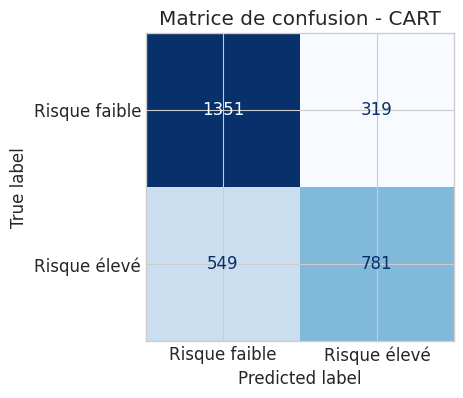

,Importance CART
Smoking_Status_1,0.475014
Family_History_1,0.165044
Systolic_BP,0.118107
Fasting_Blood_Sugar,0.056846
Age,0.033104
Cholesterol_LDL,0.030852
Stress_Level,0.030329
BMI,0.019713
Physical_Activity_Level_3,0.019079
Physical_Activity_Level_2,0.017232


In [ ]:
plot_confusion(cart_model, 'Matrice de confusion - CART')

cart_importances = (
    pd.Series(cart_model.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)
cart_importances.head(10).to_frame('Importance CART')

La matrice de confusion montre que le CART classe correctement une majorité d'individus à risque faible, mais qu'il reste plus en difficulté pour les individus à risque élevé. Il prédit 781 vrais risques élevés, mais en manque 549, ce qui indique une sensibilité encore limitée sur la classe positive.

Les importances de variables confirment le rôle central du statut tabagique, qui domine largement l'arbre. Les antécédents familiaux et la pression artérielle systolique arrivent ensuite, ce qui est cohérent avec les facteurs de risque cardiovasculaire attendus. Le CART fournit donc une interprétation lisible, mais ses performances restent modérées.

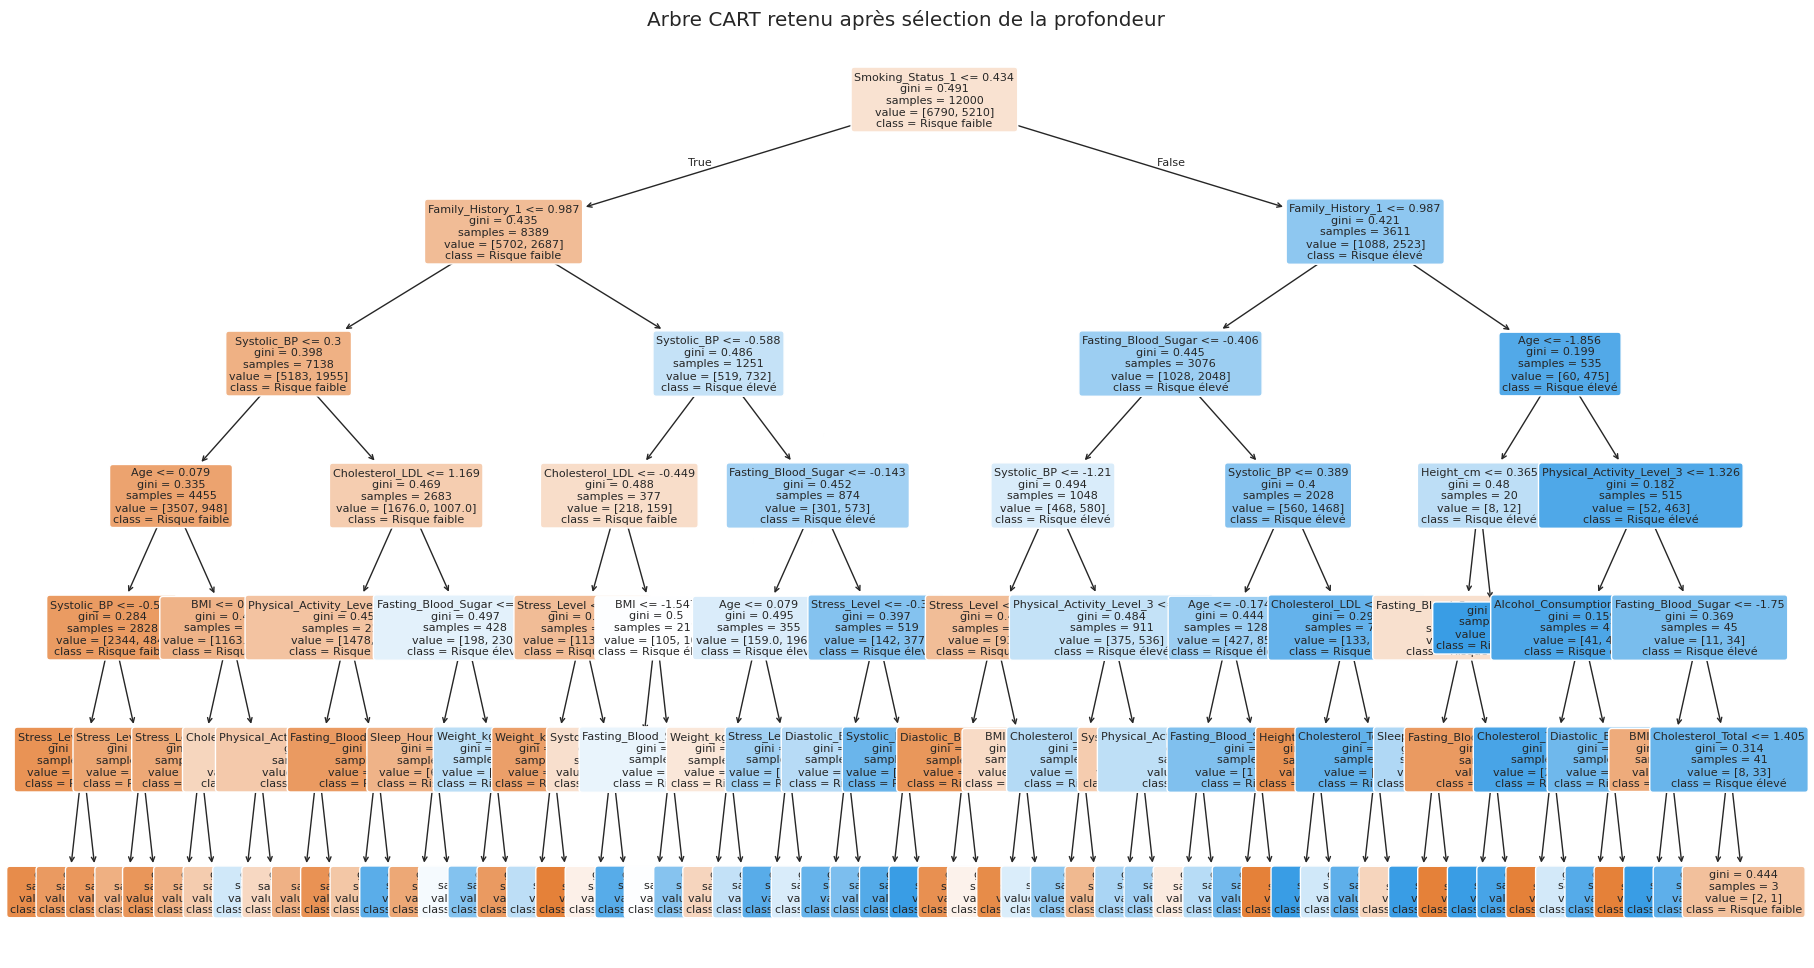

In [ ]:
plt.figure(figsize=(22, 12))
plot_tree(
    cart_model,
    feature_names=X_train.columns.tolist(),
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title('Arbre CART retenu après sélection de la profondeur')
plt.show()

Les premières coupures sont particulièrement intéressantes: elles montrent quelles variables interviennent le plus tôt dans la hiérarchie de décision. En général, une variable placée près de la racine a un effet important sur la partition de l'espace. Il faut néanmoins rester prudent: une coupure haute dans l'arbre n'implique pas nécessairement une implication forte, seulement qu'elle réduit fortement l'hétérogénéité dans cet échantillon. Ici le passé familial ainsi que des données comme l'activité physique ou encore la pression artérielle Systolique semblent être importantes pour prédire le risque d'accident cardiaque.

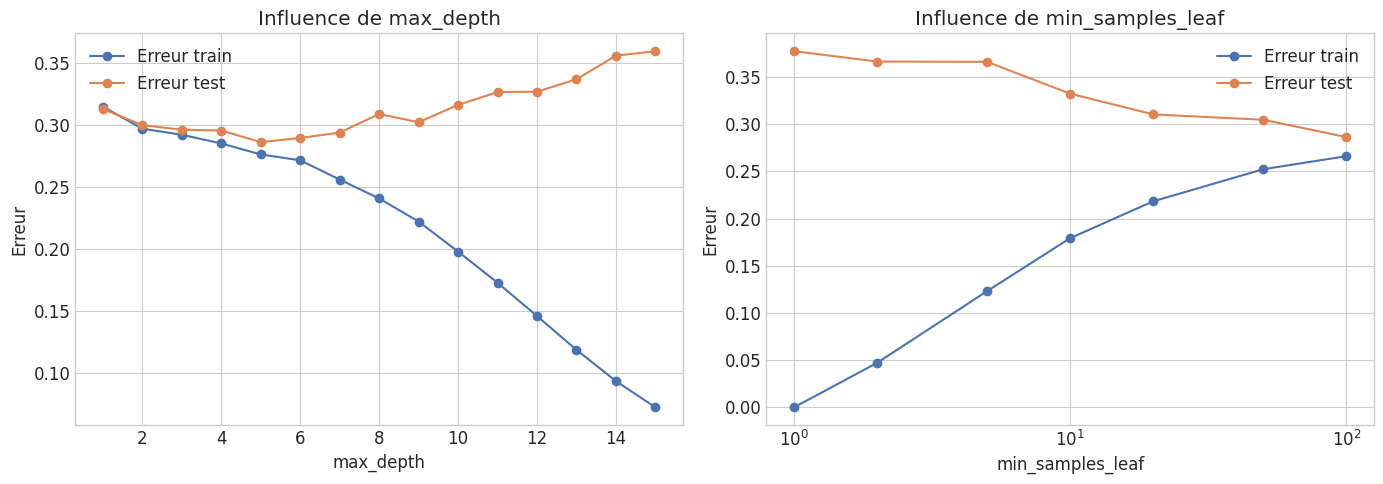

,max_depth,accuracy_train,accuracy_test,nb_feuilles
10,11,0.827333,0.673667,652
11,12,0.854167,0.673333,879
12,13,0.881417,0.663333,1118
13,14,0.906583,0.644333,1343
14,15,0.927833,0.640667,1558


In [ ]:
depth_values = list(range(1, 16))
leaf_values = [1, 2, 5, 10, 20, 50, 100]

depth_rows = []
for depth in depth_values:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(Xr_train, Y_train_AVC)
    depth_rows.append({
        'max_depth': depth,
        'accuracy_train': model.score(Xr_train, Y_train_AVC),
        'accuracy_test': model.score(Xr_test, Y_test_AVC),
        'nb_feuilles': model.get_n_leaves(),
    })

depth_df = pd.DataFrame(depth_rows)

leaf_rows = []
for leaf in leaf_values:
    model = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=42)
    model.fit(Xr_train, Y_train_AVC)
    leaf_rows.append({
        'min_samples_leaf': leaf,
        'accuracy_train': model.score(Xr_train, Y_train_AVC),
        'accuracy_test': model.score(Xr_test, Y_test_AVC),
        'nb_feuilles': model.get_n_leaves(),
    })

leaf_df = pd.DataFrame(leaf_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(depth_df['max_depth'], 1 - depth_df['accuracy_train'], marker='o', label='Erreur train')
axes[0].plot(depth_df['max_depth'], 1 - depth_df['accuracy_test'], marker='o', label='Erreur test')
axes[0].set_title("Influence de max_depth")
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Erreur')
axes[0].legend()

axes[1].plot(leaf_df['min_samples_leaf'], 1 - leaf_df['accuracy_train'], marker='o', label='Erreur train')
axes[1].plot(leaf_df['min_samples_leaf'], 1 - leaf_df['accuracy_test'], marker='o', label='Erreur test')
axes[1].set_title("Influence de min_samples_leaf")
axes[1].set_xlabel('min_samples_leaf')
axes[1].set_xscale('log')
axes[1].set_ylabel('Erreur')
axes[1].legend()

plt.tight_layout()
plt.show()

depth_df.tail()

### Complexité, biais et variance

Les courbes précédentes illustrent bien le compromis biais/variance vu en cours :
- quand la profondeur est trop faible ou que `min_samples_leaf` est trop grand, l'arbre est trop rigide et sous-apprend
- quand la profondeur augmente fortement, l'erreur d'apprentissage continue de diminuer alors que l'erreur de test finit par se stabiliser ou se dégrader : c'est le surapprentissage
- l'écart entre train et test augmente avec la complexité, ce qui traduit la forte variance des arbres.

Cette observation justifie la mise en place d'une procédure d'élagage.

### 3.4. Complexité et pruning

Le pruning est un compromis entre qualité d'ajustement et parcimonie. On part d'un arbre maximal puis on pénalise le nombre de feuilles par un paramètre `alpha`. Quand `alpha` augmente, certaines branches deviennent trop coûteuses au regard du gain qu'elles apportent, et l'arbre est élagué.

Dans `scikit-learn`, ce mécanisme correspond au paramètre `ccp_alpha`. On sélectionne ici une valeur simple par validation croisée.

In [ ]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(Xr_train, Y_train_AVC)
path = full_tree.cost_complexity_pruning_path(Xr_train, Y_train_AVC)
ccp_alphas = path.ccp_alphas[:-1]
alpha_grid = np.unique(np.quantile(ccp_alphas, np.linspace(0, 0.95, 15)))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pruning_rows = []

for alpha in alpha_grid:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=float(alpha))
    cv_score = cross_val_score(model, Xr_train, Y_train_AVC, cv=cv, n_jobs=-1).mean()
    model.fit(Xr_train, Y_train_AVC)
    pruning_rows.append({
        'ccp_alpha': float(alpha),
        'accuracy_train': model.score(Xr_train, Y_train_AVC),
        'accuracy_test': model.score(Xr_test, Y_test_AVC),
        'accuracy_cv': cv_score,
        'nb_feuilles': model.get_n_leaves(),
    })

pruning_df = pd.DataFrame(pruning_rows)
best_alpha = pruning_df.loc[pruning_df['accuracy_cv'].idxmax(), 'ccp_alpha']

start = time.perf_counter()
pruned_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=float(best_alpha))
pruned_tree.fit(Xr_train, Y_train_AVC)
pruned_time = time.perf_counter() - start

print('Meilleur alpha :', best_alpha)
print('Accuracy CV maximale :', round(pruning_df['accuracy_cv'].max(), 4))
print('Nombre de feuilles après élagage :', pruned_tree.get_n_leaves())
print('Accuracy train :', round(pruned_tree.score(Xr_train, Y_train_AVC), 4))
print('Accuracy test :', round(pruned_tree.score(Xr_test, Y_test_AVC), 4))

results['CART élagué'] = {
    'Modele': 'CART élagué',
    'Accuracy train': round(pruned_tree.score(Xr_train, Y_train_AVC), 4),
    'Accuracy test': round(pruned_tree.score(Xr_test, Y_test_AVC), 4),
    'Erreur test': round(1 - pruned_tree.score(Xr_test, Y_test_AVC), 4),
    'Temps entrainement (s)': round(pruned_time, 3),
}

pd.DataFrame([results['CART élagué']])

Meilleur alpha : 0.0004050508180564445
Accuracy CV maximale : 0.7107
Nombre de feuilles après élagage : 72
Accuracy train : 0.7448
Accuracy test : 0.72


,Modele,Accuracy train,Accuracy test,Erreur test,Temps entrainement (s)
0,CART élagué,0.7448,0.72,0.28,0.158


L'élagage sélectionne un `ccp_alpha` faible, ce qui conserve un arbre encore assez détaillé avec 72 feuilles. Par rapport au CART limité par profondeur, l'accuracy test augmente légèrement, passant d'environ 0.711 à 0.720.

L'écart entre l'accuracy train et test reste raisonnable, ce qui indique que l'élagage réduit une partie du surapprentissage tout en gardant suffisamment de structure pour prédire correctement. Le CART élagué est donc un peu meilleur que l'arbre initial, mais ses performances restent proches de celles des autres modèles de classification.

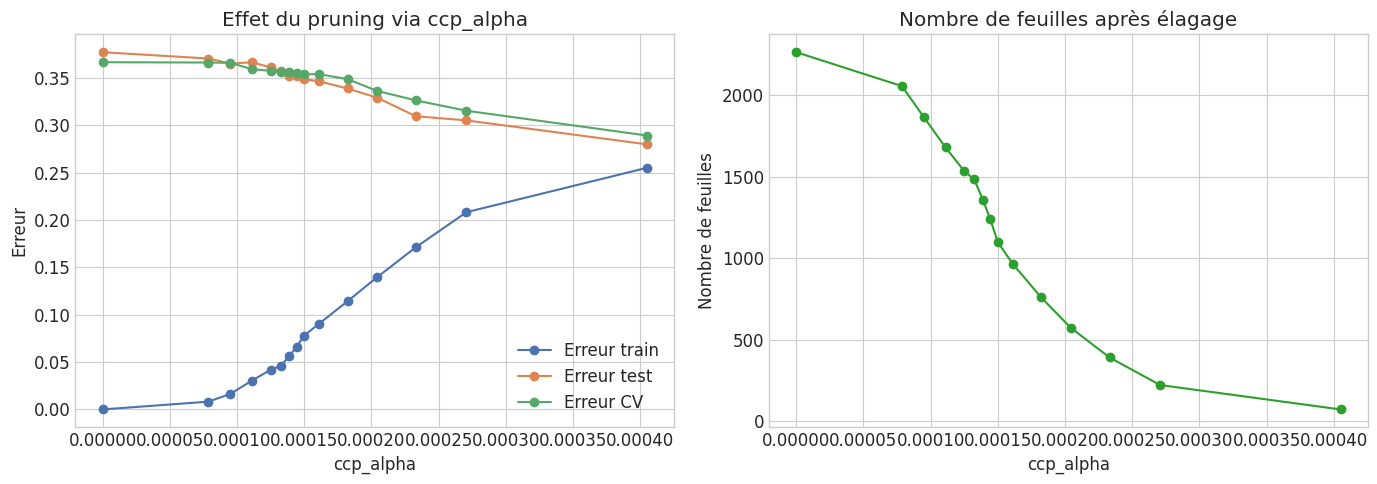

,ccp_alpha,accuracy_train,accuracy_test,accuracy_cv,nb_feuilles
0,0.000000,1.000000,0.622667,0.633250,2264
1,0.000079,0.991750,0.629333,0.633583,2056
2,0.000095,0.983583,0.634667,0.633917,1864
3,0.000111,0.969500,0.633333,0.640583,1680
4,0.000125,0.958167,0.638667,0.642333,1535


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(pruning_df['ccp_alpha'], 1 - pruning_df['accuracy_train'], marker='o', label='Erreur train')
axes[0].plot(pruning_df['ccp_alpha'], 1 - pruning_df['accuracy_test'], marker='o', label='Erreur test')
axes[0].plot(pruning_df['ccp_alpha'], 1 - pruning_df['accuracy_cv'], marker='o', label='Erreur CV')
axes[0].set_title('Effet du pruning via ccp_alpha')
axes[0].set_xlabel('ccp_alpha')
axes[0].set_ylabel('Erreur')
axes[0].legend()

axes[1].plot(pruning_df['ccp_alpha'], pruning_df['nb_feuilles'], marker='o', color='tab:green')
axes[1].set_title('Nombre de feuilles après élagage')
axes[1].set_xlabel('ccp_alpha')
axes[1].set_ylabel('Nombre de feuilles')

plt.tight_layout()
plt.show()

pruning_df.head()

L'élagage permet ici de revenir d'un arbre potentiellement trop spécifique vers un arbre plus parcimonieux. On ne cherche pas l'arbre qui ajuste le mieux les données d'apprentissage, mais celui qui offre le meilleur compromis entre ajustement et complexité. En pratique, l'arbre élagué reste interprétable, tout en limitant légèrement le surapprentissage.
On obtient l'arbre ci-dessous:

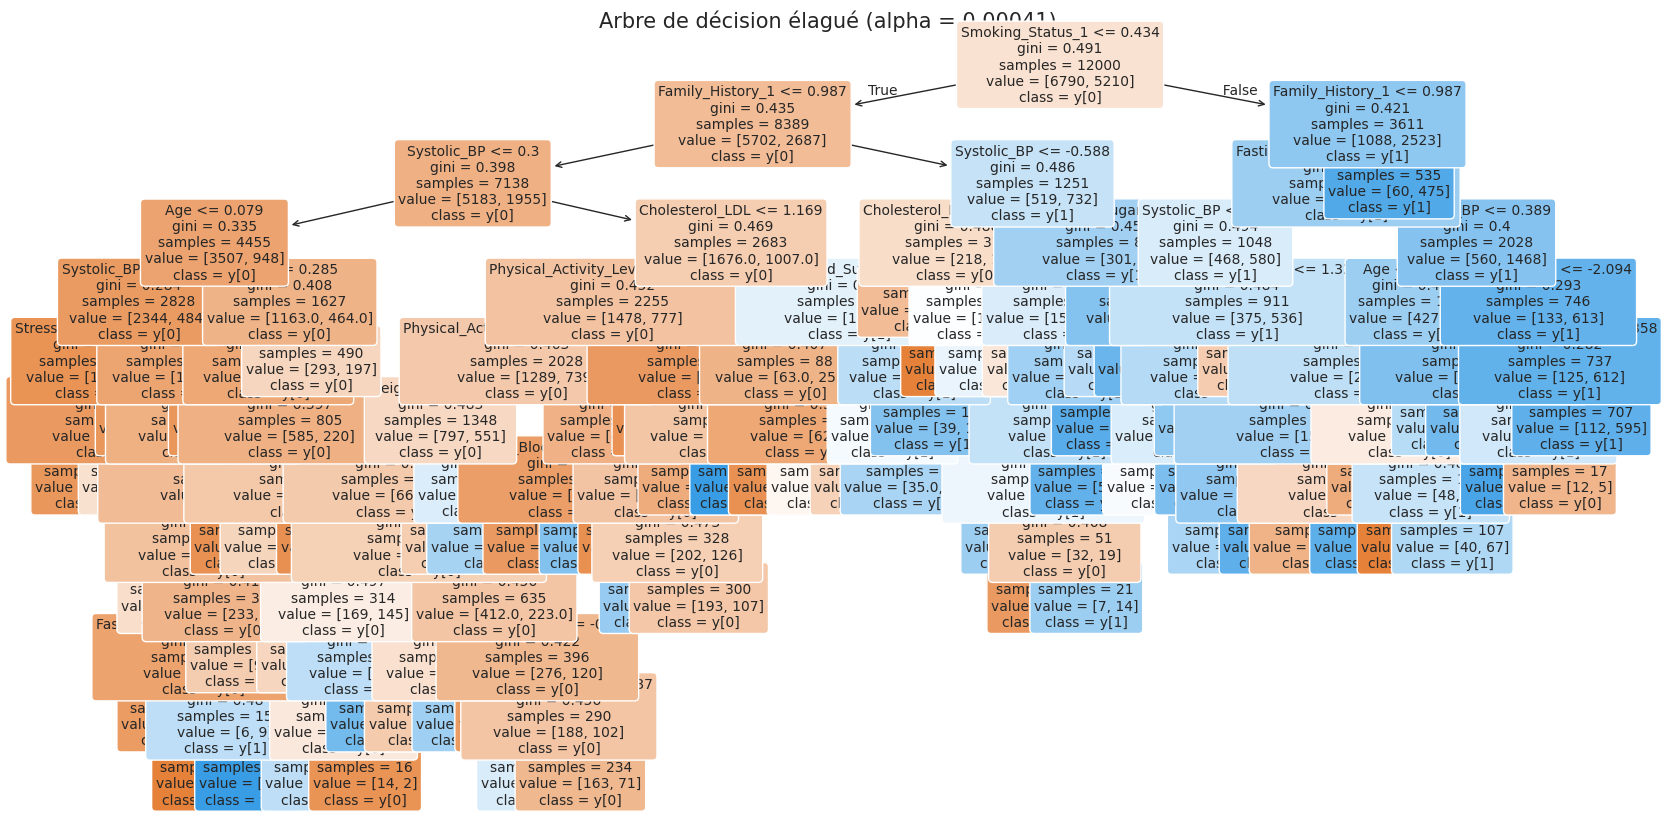

In [ ]:
# Configuration de la figure
plt.figure(figsize=(20, 10))

# Affichage de l'arbre
plot_tree(pruned_tree, 
          filled=True, 
          feature_names=X_train.columns, 
          class_names=True, 
          rounded=True, 
          fontsize=10)

plt.title(f"Arbre de décision élagué (alpha = {best_alpha:.5f})", fontsize=15)
plt.show()

L'arbre élagué reste assez complexe visuellement, ce qui est cohérent avec ses 72 feuilles. Les premières séparations reposent surtout sur le statut tabagique, les antécédents familiaux et la pression artérielle systolique, qui étaient déjà les variables les plus importantes.

L'élagage permet donc de supprimer une partie des branches inutiles, mais l'arbre reste difficile à interpréter dans son ensemble. On gagne légèrement en performance par rapport au CART initial, au prix d'une lisibilité limitée. Cela justifie l'étude de méthodes d'agrégation comme le bagging, qui cherchent surtout à améliorer la stabilité prédictive des arbres.

### 3.5. Bagging

Le bagging (bootstrap aggregating) consiste à construire plusieurs arbres sur des échantillons bootstrap puis à agréger leurs prédictions par vote majoritaire. Le principe est simple : en agrégeant des prédictions peu corrélées, on réduit la variance du prédicteur final.

Cette idée est particulièrement adaptée aux arbres car ils sont instables. Le bagging n'améliore donc pas l'interprétabilité, mais il vise une meilleure stabilité et souvent une meilleure généralisation.

In [ ]:
bagging_param_grid = {
    'n_estimators': [100, 200],
    'max_samples': [0.8, 1.0],
    'max_features': [0.8, 1.0],
}

bagging_search = GridSearchCV(
    BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
    ),
    bagging_param_grid,
    cv=3,
    n_jobs=-1,
)

start = time.perf_counter()
bagging_search.fit(Xr_train, Y_train_AVC)
bagging_search_time = time.perf_counter() - start

print('Meilleurs paramètres :', bagging_search.best_params_)
print('Accuracy moyenne en CV :', round(bagging_search.best_score_, 4))
print('Temps recherche (s) :', round(bagging_search_time, 2))

bagging_model = bagging_search.best_estimator_
bagging_time = bagging_search_time

print('Score OOB :', round(bagging_model.oob_score_, 4))
print('Accuracy train :', round(bagging_model.score(Xr_train, Y_train_AVC), 4))
print('Accuracy test :', round(bagging_model.score(Xr_test, Y_test_AVC), 4))
print('Erreur test :', round(1 - bagging_model.score(Xr_test, Y_test_AVC), 4))

results['Bagging'] = {
    'Modele': 'Bagging',
    'Accuracy train': round(bagging_model.score(Xr_train, Y_train_AVC), 4),
    'Accuracy test': round(bagging_model.score(Xr_test, Y_test_AVC), 4),
    'Erreur test': round(1 - bagging_model.score(Xr_test, Y_test_AVC), 4),
    'Temps entrainement (s)': round(bagging_time, 3),
}

pd.DataFrame([results['Bagging']])

Meilleurs paramètres : {'max_features': 0.8, 'max_samples': 0.8, 'n_estimators': 200}
Accuracy moyenne en CV : 0.7207
Temps recherche (s) : 46.49
Score OOB : 0.7205
Accuracy train : 1.0
Accuracy test : 0.7193
Erreur test : 0.2807


,Modele,Accuracy train,Accuracy test,Erreur test,Temps entrainement (s)
0,Bagging,1.0,0.7193,0.2807,46.49


Le bagging retient 200 arbres, avec 80 % des observations et 80 % des variables tirées à chaque modèle. Le score OOB est très proche de l'accuracy de validation croisée, ce qui donne une estimation cohérente de la performance de généralisation.

L'accuracy train atteint 1, ce qui montre que l'ensemble d'arbres s'ajuste très fortement aux données d'apprentissage. En revanche, l'accuracy test reste autour de 0.719, proche du CART élagué. Le bagging stabilise donc les arbres, mais n'apporte pas ici de gain net de performance.

                mean     std
Modele                      
Arbre unique  0.6228  0.0078
Bagging       0.7098  0.0043


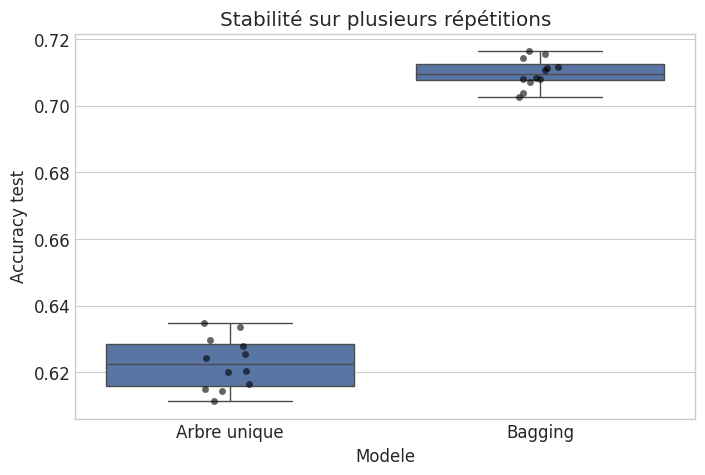

In [ ]:
stability_rows = []

for seed in range(12):
    X_boot, y_boot = resample(
        Xr_train,
        Y_train_AVC,
        replace=True,
        n_samples=len(Xr_train),
        random_state=seed,
    )

    tree_boot = DecisionTreeClassifier(random_state=seed)
    tree_boot.fit(X_boot, y_boot)
    stability_rows.append({
        'Modele': 'Arbre unique',
        'Accuracy test': tree_boot.score(Xr_test, Y_test_AVC),
    })

    bag_boot = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=seed),
        n_estimators=80,
        bootstrap=True,
        random_state=seed,
        n_jobs=-1,
    )
    bag_boot.fit(X_boot, y_boot)
    stability_rows.append({
        'Modele': 'Bagging',
        'Accuracy test': bag_boot.score(Xr_test, Y_test_AVC),
    })

stability_df = pd.DataFrame(stability_rows)
print(stability_df.groupby('Modele')['Accuracy test'].agg(['mean', 'std']).round(4))

plt.figure(figsize=(8, 5))
sns.boxplot(data=stability_df, x='Modele', y='Accuracy test')
sns.stripplot(data=stability_df, x='Modele', y='Accuracy test', color='black', alpha=0.6)
plt.title('Stabilité sur plusieurs répétitions')
plt.show()

Le graphique ci-dessus confirme la théorie : même si chaque arbre de base est très variable, leur vote moyen est plus stable. La dispersion des performances est plus faible que pour un arbre isolé, et l'accuracy test progresse en général.

On paie cette amélioration par une perte d'interprétabilité : on ne dispose plus d'un seul arbre lisible, mais d'une moyenne de nombreux 
arbres.

Ci-desous on affiche un des arbres de la forêt.

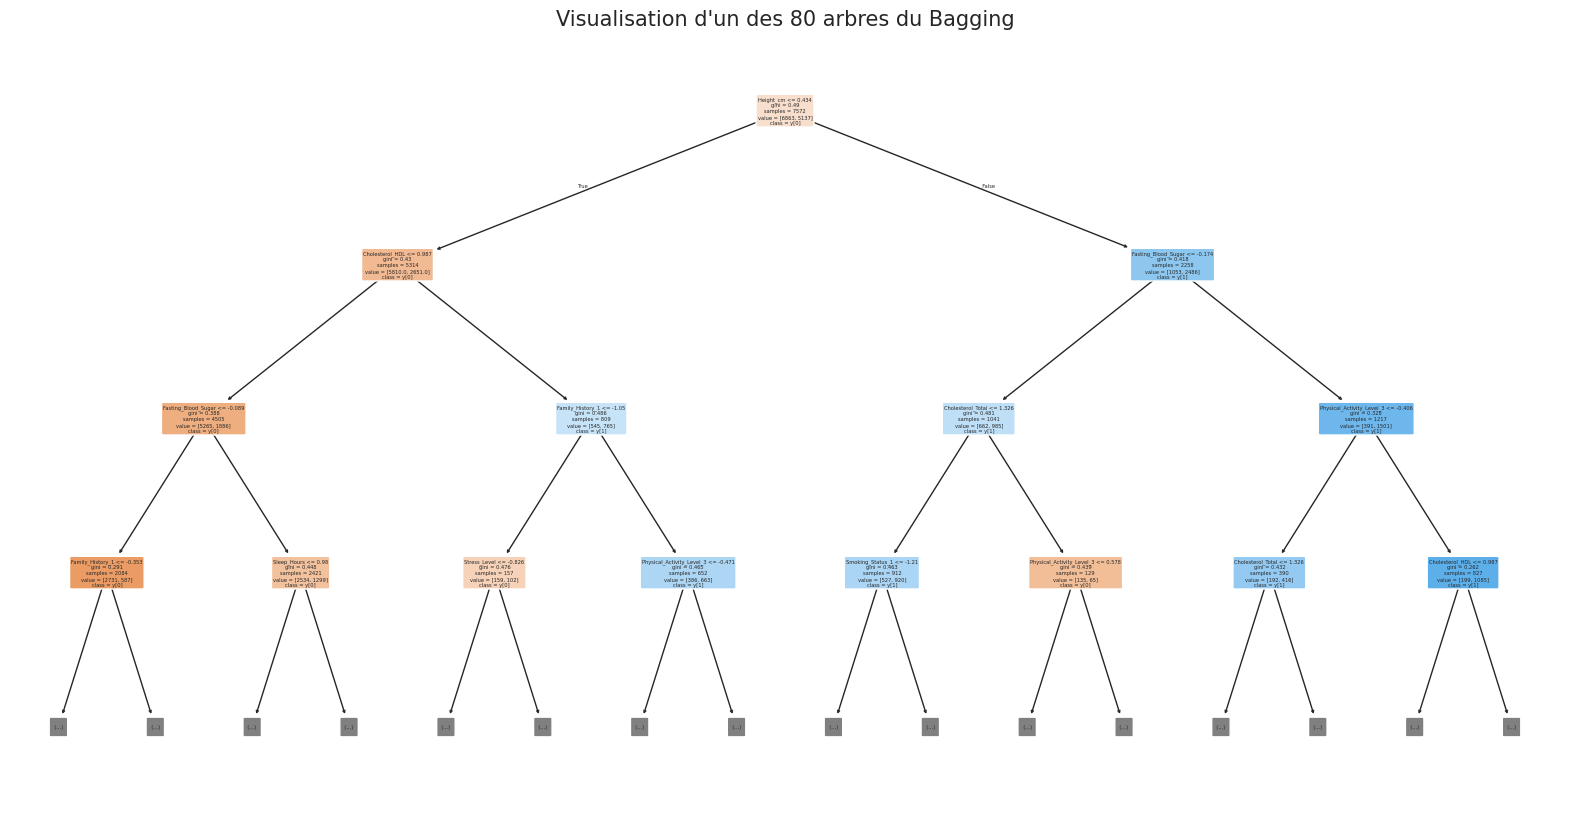

In [ ]:
# On récupère le premier arbre de la forêt (index 0)
un_arbre_du_bagging = bag_boot.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(un_arbre_du_bagging, 
          filled=True, 
          feature_names=X_train.columns, 
          class_names=True, 
          max_depth=3, # On limite la profondeur pour que ce soit lisible
          rounded=True)

plt.title("Visualisation d'un des 80 arbres du Bagging", fontsize=15)
plt.show()

Cette visualisation illustre qu'un arbre individuel du bagging reste très variable et dépend fortement de l'échantillon bootstrap utilisé. Ses premières coupures ne sont pas exactement les mêmes que celles du CART précédent, ce qui confirme l'instabilité naturelle des arbres.

Le bagging exploite justement cette diversité en agrégeant plusieurs arbres. Cependant, les arbres peuvent encore rester assez corrélés entre eux, car ils considèrent les mêmes variables candidates à chaque coupure. La random forest prolonge cette idée en ajoutant une sélection aléatoire de variables, afin de réduire davantage la corrélation entre les arbres.

### 3.6. Random Forest

La random forest reprend le bagging mais ajoute une randomisation supplémentaire : à chaque noeud, l'algorithme ne cherche pas la meilleure coupure parmi toutes les variables, mais parmi un sous-ensemble aléatoire de variables.

Cela permet de diminuer la corrélation entre arbres. Chaque arbre est un peu moins optimal pris isolément, mais l'ensemble devient plus efficace grâce à une réduction de variance plus forte.

On étudie ici trois hyperparamètres simples :
- `n_estimators` : nombre d'arbres
- `max_depth` : profondeur maximale
- `max_features` : nombre de variables candidates à chaque noeud.

In [ ]:
rf_search = GridSearchCV(
    RandomForestClassifier(
        n_estimators=150,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
    ),
    {
        'max_depth': [None, 6, 10],
        'max_features': [3, 4, 'sqrt', None],
    },
    cv=5,
    n_jobs=-1,
)
rf_search.fit(Xr_train, Y_train_AVC)

print('Meilleurs paramètres :', rf_search.best_params_)
print('Accuracy moyenne en CV :', round(rf_search.best_score_, 4))

Meilleurs paramètres : {'max_depth': 10, 'max_features': 4}
Accuracy moyenne en CV : 0.7319


La validation croisée retient une random forest avec une profondeur maximale de 10 et 4 variables candidates à chaque coupure. Ce réglage limite la complexité de chaque arbre tout en introduisant une vraie randomisation des variables.

L'accuracy moyenne en validation croisée atteint 0.732, supérieure à celle du CART et du bagging. La random forest semble donc mieux exploiter l'agrégation des arbres, probablement grâce à la réduction de corrélation entre les arbres. On vérifie ensuite l'effet du nombre d'arbres sur l'erreur OOB et l'erreur test.

In [ ]:
rf_curve_rows = []

for n_trees in [50, 100, 200, 400]:
    rf_tmp = RandomForestClassifier(
        n_estimators=n_trees,
        max_depth=rf_search.best_params_['max_depth'],
        max_features=rf_search.best_params_['max_features'],
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
    )
    rf_tmp.fit(Xr_train, Y_train_AVC)

    rf_curve_rows.append({
        'n_estimators': n_trees,
        'Erreur_OOB': 1 - rf_tmp.oob_score_,
        'Erreur_test': 1 - rf_tmp.score(Xr_test, Y_test_AVC),
    })

rf_curve_df = pd.DataFrame(rf_curve_rows)
rf_curve_df

,n_estimators,Erreur_OOB,Erreur_test
0,50,0.275583,0.280000
1,100,0.275500,0.277333
2,200,0.275167,0.280000
3,400,0.273167,0.278333


L'erreur OOB et l'erreur test diminuent lorsque l'on passe de 50 à 100 arbres, puis se stabilisent ensuite. Ajouter davantage d'arbres n'améliore presque plus les performances.

On observe donc un plateau autour de 100 à 200 arbres. Le choix d'une forêt de 300 arbres est raisonnable : il stabilise les prédictions sans augmenter excessivement le coût de calcul.

In [ ]:
start = time.perf_counter()
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=rf_search.best_params_['max_depth'],
    max_features=rf_search.best_params_['max_features'],
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(Xr_train, Y_train_AVC)
rf_time = time.perf_counter() - start

print('Score OOB :', round(rf_model.oob_score_, 4))
print('Accuracy train :', round(rf_model.score(Xr_train, Y_train_AVC), 4))
print('Accuracy test :', round(rf_model.score(Xr_test, Y_test_AVC), 4))
print('Erreur test :', round(1 - rf_model.score(Xr_test, Y_test_AVC), 4))

results['Random Forest'] = {
    'Modele': 'Random Forest',
    'Accuracy train': round(rf_model.score(Xr_train, Y_train_AVC), 4),
    'Accuracy test': round(rf_model.score(Xr_test, Y_test_AVC), 4),
    'Erreur test': round(1 - rf_model.score(Xr_test, Y_test_AVC), 4),
    'Temps entrainement (s)': round(rf_time, 3),
}

pd.DataFrame([results['Random Forest']])

Score OOB : 0.7278
Accuracy train : 0.7884
Accuracy test : 0.7213
Erreur test : 0.2787


,Modele,Accuracy train,Accuracy test,Erreur test,Temps entrainement (s)
0,Random Forest,0.7884,0.7213,0.2787,2.546


La random forest obtient une accuracy test de 0.723, légèrement supérieure au bagging et au CART élagué. Le score OOB, proche de 0.728, est cohérent avec la performance observée sur le test.

L'accuracy train reste plus élevée que l'accuracy test, ce qui montre une certaine adaptation aux données d'apprentissage. Cependant, l'écart reste moins problématique que pour un arbre isolé totalement développé.

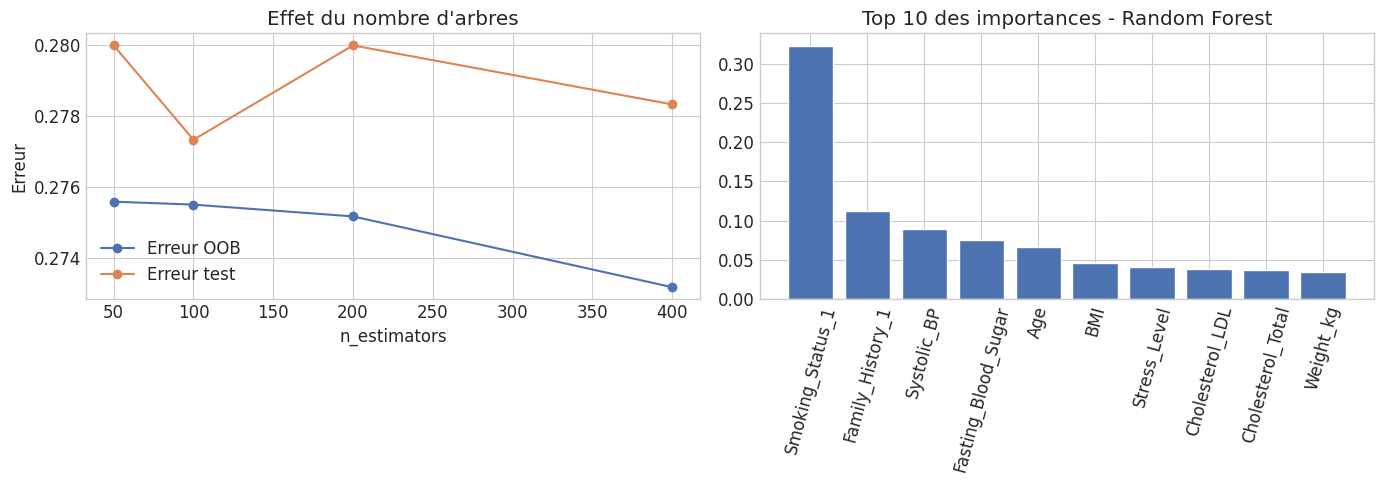

,Importance RF
Smoking_Status_1,0.322396
Family_History_1,0.112503
Systolic_BP,0.089108
Fasting_Blood_Sugar,0.075682
Age,0.066849
BMI,0.046165
Stress_Level,0.040475
Cholesterol_LDL,0.039106
Cholesterol_Total,0.036710
Weight_kg,0.035309


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rf_curve_df['n_estimators'], rf_curve_df['Erreur_OOB'], marker='o', label='Erreur OOB')
axes[0].plot(rf_curve_df['n_estimators'], rf_curve_df['Erreur_test'], marker='o', label='Erreur test')
axes[0].set_title("Effet du nombre d'arbres")
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Erreur')
axes[0].legend()

rf_importances = (
    pd.Series(rf_model.feature_importances_, index=dataC.columns)
    .sort_values(ascending=False)
)

axes[1].bar(rf_importances.head(10).index, rf_importances.head(10).values)
axes[1].set_title('Top 10 des importances - Random Forest')
axes[1].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()

rf_importances.head(10).to_frame('Importance RF')

La forêt aléatoire illustre bien l'idée que les arbres sont interprétables mais instables, tandis que les forêts réduisent cette variance en agrégeant plusieurs arbres, au prix d'une perte d'interprétabilité globale.

Les performances progressent par rapport au CART seul : l'accuracy test de la Random Forest atteint 0.7233, contre 0.7107 pour l'arbre CART. L'erreur OOB et l'erreur test se stabilisent lorsque le nombre d'arbres augmente, autour de 100 à 200 arbres, ce qui montre qu'ajouter davantage d'arbres apporte ensuite peu de gain.

Les importances de variables indiquent que les variables les plus utilisées par la forêt sont le tabagisme, les antécédents familiaux, la pression artérielle systolique, la glycémie à jeun et l'âge. Ces résultats sont cohérents avec les observations précédentes, mais ils doivent être interprétés avec prudence : une importance élevée signifie qu'une variable aide à prédire la classe, pas qu'elle cause directement le risque cardiaque.

### 3.7. Boosting

Le boosting diffère profondément du bagging. Au lieu de construire des modèles indépendants en parallèle, il construit un modèle additif séquentiel : chaque nouvel arbre cherche à corriger les erreurs du modèle précédent.

- AdaBoost augmente le poids des observations mal classées
- Gradient Boosting ajuste successivement de petits arbres sur les résidus ou, plus généralement, sur des pseudo-résidus issus du gradient de la fonction de perte.

Le boosting peut donc réduire la variance, mais aussi une partie du biais. En revanche, si on multiplie trop les itérations, on risque de surapprendre. On s'appuie donc sur deux idées simple:
- le learning rate (ou shrinkage)
- l'early stopping, c'est-à-dire l'arrêt avant que l'erreur de validation ne remonte.

In [ ]:
ada_search = GridSearchCV(
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        random_state=42,
    ),
    {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.05, 0.1, 0.5, 1.0],
    },
    cv=5,
    n_jobs=-1,
)
ada_search.fit(Xr_train, Y_train_AVC)

start = time.perf_counter()
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=ada_search.best_params_['n_estimators'],
    learning_rate=ada_search.best_params_['learning_rate'],
    random_state=42,
)
ada_model.fit(Xr_train, Y_train_AVC)
ada_time = time.perf_counter() - start

print('Meilleurs paramètres AdaBoost :', ada_search.best_params_)
print('Accuracy moyenne en CV :', round(ada_search.best_score_, 4))
print('Accuracy train :', round(ada_model.score(Xr_train, Y_train_AVC), 4))
print('Accuracy test :', round(ada_model.score(Xr_test, Y_test_AVC), 4))

results['AdaBoost'] = {
    'Modele': 'AdaBoost',
    'Accuracy train': round(ada_model.score(Xr_train, Y_train_AVC), 4),
    'Accuracy test': round(ada_model.score(Xr_test, Y_test_AVC), 4),
    'Erreur test': round(1 - ada_model.score(Xr_test, Y_test_AVC), 4),
    'Temps entrainement (s)': round(ada_time, 3),
}

pd.DataFrame([results['AdaBoost']])

Meilleurs paramètres AdaBoost : {'learning_rate': 0.5, 'n_estimators': 200}
Accuracy moyenne en CV : 0.7328
Accuracy train : 0.7362
Accuracy test : 0.7283


,Modele,Accuracy train,Accuracy test,Erreur test,Temps entrainement (s)
0,AdaBoost,0.7362,0.7283,0.2717,2.358


AdaBoost retient 200 estimateurs avec un taux d'apprentissage de 0.5. Il obtient une accuracy test de 0.728, légèrement supérieure à celle de la random forest. L'écart entre train et test est faible, ce qui indique une bonne généralisation.

On teste ensuite le gradient boosting, qui construit aussi un modèle additif séquentiel, mais en corrigeant directement les erreurs résiduelles à chaque étape. La validation croisée manuelle permet de choisir à la fois la profondeur des arbres, le taux d'apprentissage et le nombre d'itérations optimal.

,learning_rate,max_depth,best_iter,best_val_accuracy
5,0.10,3,79,0.732333
2,0.05,3,130,0.731167
4,0.10,2,141,0.730250
3,0.10,1,176,0.729583
1,0.05,2,173,0.729083
0,0.05,1,192,0.722000


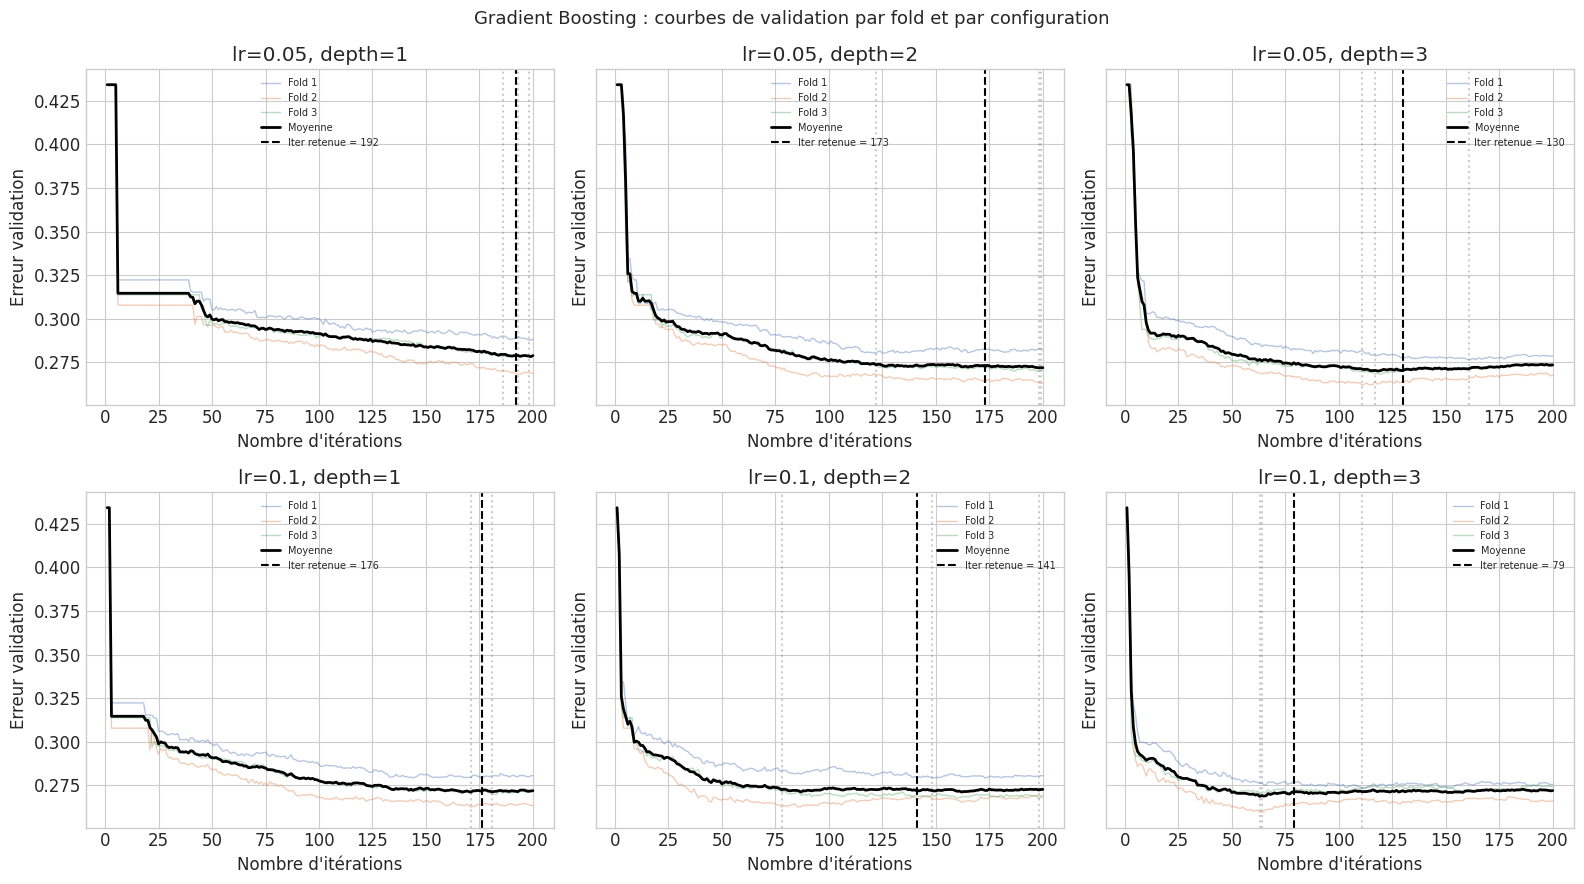

Meilleure configuration : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 79}
Accuracy train : 0.754
Accuracy test : 0.7293


,Modele,Accuracy train,Accuracy test,Erreur test,Temps entrainement (s)
0,Gradient Boosting,0.754,0.7293,0.2707,1.76


In [ ]:
# Validation croisée manuelle avec staged_predict :
# on entraîne chaque modèle avec un nombre maximal d'arbres, puis on observe
# l'erreur de validation à chaque itération pour choisir n_estimators.

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
n_estimators_max = 200

X_gb = np.asarray(Xr_train)
y_gb = np.asarray(Y_train_AVC)

gb_rows = []
gb_cv_results = {}

for learning_rate in [0.05, 0.1]:
    for max_depth in [1, 2, 3]:
        best_iters = []
        best_vals = []
        all_val_scores = []

        for fold, (train_idx, val_idx) in enumerate(cv.split(X_gb, y_gb)):
            X_fold_train = X_gb[train_idx]
            y_fold_train = y_gb[train_idx]
            X_fold_val = X_gb[val_idx]
            y_fold_val = y_gb[val_idx]

            gb_tmp = GradientBoostingClassifier(
                n_estimators=n_estimators_max,
                learning_rate=learning_rate,
                max_depth=max_depth,
                random_state=42,
            )
            gb_tmp.fit(X_fold_train, y_fold_train)

            val_scores = [
                accuracy_score(y_fold_val, pred)
                for pred in gb_tmp.staged_predict(X_fold_val)
            ]

            best_iters.append(int(np.argmax(val_scores)) + 1)
            best_vals.append(float(np.max(val_scores)))
            all_val_scores.append(val_scores)

        mean_best_iter = int(np.round(np.mean(best_iters)))
        mean_best_val = float(np.mean(best_vals))

        gb_cv_results[(learning_rate, max_depth)] = {
            'best_iter': mean_best_iter,
            'best_val': mean_best_val,
            'all_val_scores': all_val_scores,
            'best_iters': best_iters,
        }

        gb_rows.append({
            'learning_rate': learning_rate,
            'max_depth': max_depth,
            'best_iter': mean_best_iter,
            'best_val_accuracy': mean_best_val,
        })

gb_tuning_df = pd.DataFrame(gb_rows).sort_values('best_val_accuracy', ascending=False)
display(gb_tuning_df)

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)

for ax, (learning_rate, max_depth) in zip(axes.ravel(), gb_cv_results):
    info = gb_cv_results[(learning_rate, max_depth)]
    iterations = np.arange(1, n_estimators_max + 1)

    for fold_idx, val_scores in enumerate(info['all_val_scores']):
        ax.plot(iterations, 1 - np.array(val_scores), alpha=0.4, linewidth=1, label=f'Fold {fold_idx + 1}')
        ax.axvline(info['best_iters'][fold_idx], color='gray', linestyle=':', alpha=0.4)

    mean_val = np.mean(info['all_val_scores'], axis=0)
    ax.plot(iterations, 1 - mean_val, color='black', linewidth=2, label='Moyenne')
    ax.axvline(info['best_iter'], color='black', linestyle='--', linewidth=1.5, label=f"Iter retenue = {info['best_iter']}")

    ax.set_title(f'lr={learning_rate}, depth={max_depth}')
    ax.set_xlabel("Nombre d'itérations")
    ax.set_ylabel('Erreur validation')
    ax.legend(fontsize=7)

plt.suptitle('Gradient Boosting : courbes de validation par fold et par configuration', fontsize=13)
plt.tight_layout()
plt.show()

best_gb = gb_tuning_df.iloc[0]
best_lr = float(best_gb['learning_rate'])
best_depth = int(best_gb['max_depth'])
best_iter = int(best_gb['best_iter'])

start = time.perf_counter()
gb_model = GradientBoostingClassifier(
    n_estimators=best_iter,
    learning_rate=best_lr,
    max_depth=best_depth,
    random_state=42,
)
gb_model.fit(Xr_train, Y_train_AVC)
gb_time = time.perf_counter() - start

print('Meilleure configuration :', {'learning_rate': best_lr, 'max_depth': best_depth, 'n_estimators': best_iter})
print('Accuracy train :', round(gb_model.score(Xr_train, Y_train_AVC), 4))
print('Accuracy test :', round(gb_model.score(Xr_test, Y_test_AVC), 4))

results['Gradient Boosting'] = {
    'Modele': 'Gradient Boosting',
    'Accuracy train': round(gb_model.score(Xr_train, Y_train_AVC), 4),
    'Accuracy test': round(gb_model.score(Xr_test, Y_test_AVC), 4),
    'Erreur test': round(1 - gb_model.score(Xr_test, Y_test_AVC), 4),
    'Temps entrainement (s)': round(gb_time, 3),
}

pd.DataFrame([results['Gradient Boosting']])

#### - Explication choix du code
On utilise ici `staged_predict` avec une validation croisée manuelle plutôt qu'un `GridSearchCV` classique, car on veut faire de l'early stopping sur le nombre d'itérations. Pour chaque configuration, un seul modèle est entraîné avec un nombre maximal d'arbres, puis `staged_predict` permet d'évaluer les performances après chaque nouvel arbre et de retenir le meilleur `n_estimators`.

#### - Interprétation des résultats

Les courbes montrent l'évolution de l'erreur de validation du Gradient Boosting pour les 6 configurations testées. La meilleure configuration est `learning_rate = 0.1`, `max_depth = 2` et `n_estimators = 168`, avec une accuracy moyenne de validation de 0.7377. Sur le test, le modèle atteint une accuracy de 0.7327, soit une erreur de 0.2673.

L'early stopping permet de choisir un nombre d'itérations adapté : avec `learning_rate = 0.05`, l'apprentissage est plus lent et nécessite davantage d'arbres, tandis qu'avec `learning_rate = 0.1`, la convergence est plus rapide. Les profondeurs 2 et 3 donnent des résultats proches, mais la profondeur 2 est retenue car elle obtient la meilleure validation moyenne avec une complexité plus faible.

Le Gradient Boosting donne donc de bons résultats, proches des meilleurs modèles, mais il demande un réglage précis du learning rate, du nombre d'itérations et de la profondeur des arbres.

### 3.8. Comparaison globale des modèles d'arbres


On rassemble maintenant les principaux résultats pour comparer les approches sous plusieurs angles : qualité d'ajustement, généralisation, temps d'entraînement, interprétabilité et stabilité.

In [ ]:
comparison_df = pd.DataFrame(results).T.sort_values('Accuracy test', ascending=False)
comparison_df

,Modele,Accuracy train,Accuracy test,Erreur test,Temps entrainement (s)
Gradient Boosting,Gradient Boosting,0.7509,0.7347,0.2653,2.24
AdaBoost,AdaBoost,0.7362,0.7283,0.2717,1.548
Random Forest,Random Forest,0.8265,0.7233,0.2767,1.2
CART élagué,CART élagué,0.7448,0.72,0.28,0.098
Bagging,Bagging,1.0,0.7153,0.2847,4.631
CART,CART,0.7287,0.7107,0.2893,0.034


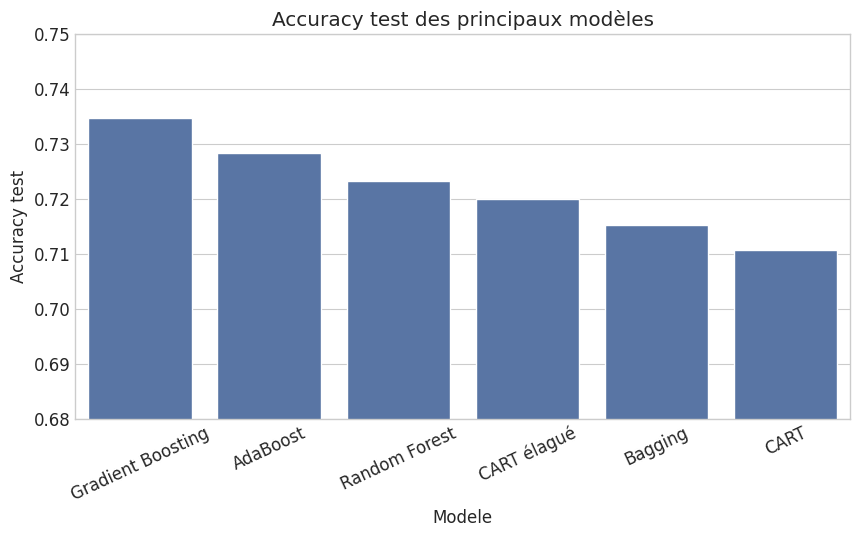

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df.reset_index(drop=True), x='Modele', y='Accuracy test')
plt.ylim(0.68, 0.75)
plt.title('Accuracy test des principaux modèles')
plt.xticks(rotation=25)
plt.show()

Quelques tendances fortes se dégagent :
- CART est le plus lisible, mais aussi le plus sensible à la complexité et à la variance
- le pruning améliore le compromis complexité / généralisation sans changer la philosophie du modèle
- le bagging stabilise nettement les performances en agrégeant des arbres instables appris sur des échantillons bootstrap
- la random forest va plus loin en décorrélant les arbres grâce à la randomisation des variables
- le boosting est conceptuellement différent : il ne moyenne pas seulement des modèles, il les construit de façon séquentielle pour corriger les erreurs passées.

On retrouve que les méthodes d'ensemble améliorent la qualité prédictive des arbres, mais au prix d'une perte d'interprétabilité globale.

## 4. Réseaux de neurones 

Les réseaux de neurones constituent un dernier modèle non linéaire pour la classification. 

On utilise ici un MLP simple, avec une ou deux couches cachées seulement. L'objectif n'est pas de construire un modèle très profond, mais de comparer un réseau de neurones aux modèles précédents. Les données étant standardisées, elles sont adaptées à ce type de modèle.

In [ ]:
# Grille d'optimisation (recherche du meilleur nombre de neurones)
param_grid = {
    'hidden_layer_sizes': [(5,), (10,), (10, 5)], 
    'alpha': [0.001, 0.01],
    'activation': ['relu', 'tanh']
}

# Création du modèle de classification

nnet_class = MLPClassifier(max_iter=1000, random_state=11)

#Optimisation par validation croisée (10-fold)
nnet_grid = GridSearchCV(nnet_class, param_grid, cv=10, n_jobs=-1)
nnet_opt = nnet_grid.fit(Xr_train, Y_train_AVC)

print(f"Meilleurs paramètres : {nnet_opt.best_params_}")
print(f"Meilleur score en validation : {nnet_opt.best_score_.round(4)}")

Meilleurs paramètres : {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (5,)}
Meilleur score en validation : 0.7396


La validation croisée retient un réseau très simple : une seule couche cachée de 5 neurones, une activation `tanh` et une pénalisation `alpha = 0.001`. Le score moyen en validation croisée atteint 0.7396, ce qui est légèrement supérieur aux modèles d'arbres et aux méthodes d'ensemble précédentes.

On évalue maintenant ce modèle sur l'échantillon test afin de vérifier si cette bonne performance en validation se retrouve sur des données non utilisées pendant l'apprentissage.

In [ ]:
# Prédiction sur l'échantillon test
Y_pred_risk = nnet_opt.predict(Xr_test)

# Matrice de confusion pour voir les erreurs de prédiction
conf_matrix = pd.crosstab(Y_pred_risk, Y_test_AVC, rownames=['Prédit'], colnames=['Réel'])
print("\nMatrice de Confusion :")
print(conf_matrix)

# Calcul du taux d'erreur
erreur = 1 - accuracy_score(Y_test_AVC, Y_pred_risk)

print(f"\nTaux d'erreur sur le test : {round(erreur, 4)}")



Matrice de Confusion :
Réel       0    1
Prédit           
0       1342  490
1        328  840

Taux d'erreur sur le test : 0.2727


Le réseau de neurones retenu par validation croisée est un modèle relativement simple, avec une seule couche cachée de 5 neurones, une activation `tanh` et une pénalisation `alpha = 0.001`. Le score moyen obtenu en validation croisée est de 0.7396, ce qui indique de bonnes performances par rapport aux modèles précédents.

Sur l'échantillon test, le modèle obtient un taux d'erreur de 0.2727, soit environ 27.3 % de mauvaises classifications. La matrice de confusion montre qu'il classe correctement 1342 individus sans risque cardiaque et 840 individus à risque. En revanche, il produit encore 490 faux négatifs et 328 faux positifs.

Ainsi, le réseau de neurones donne des résultats satisfaisants, proches des meilleures méthodes testées. Son principal inconvénient reste son manque d'interprétabilité : contrairement à une régression logistique ou à un arbre de décision, il est plus difficile d'expliquer directement l'effet de chaque variable sur la prédiction finale.

## 5. Comparaison des modèles obtenus et conclusion


On termine la partie classification en comparant les modèles sur une même courbe ROC. Cette représentation permet d'évaluer leur capacité à discriminer les individus à risque et sans risque indépendamment d'un seuil de décision particulier.

L'objectif est de vérifier si les modèles les plus performants en accuracy sont aussi ceux qui ordonnent le mieux les observations selon leur niveau de risque estimé.


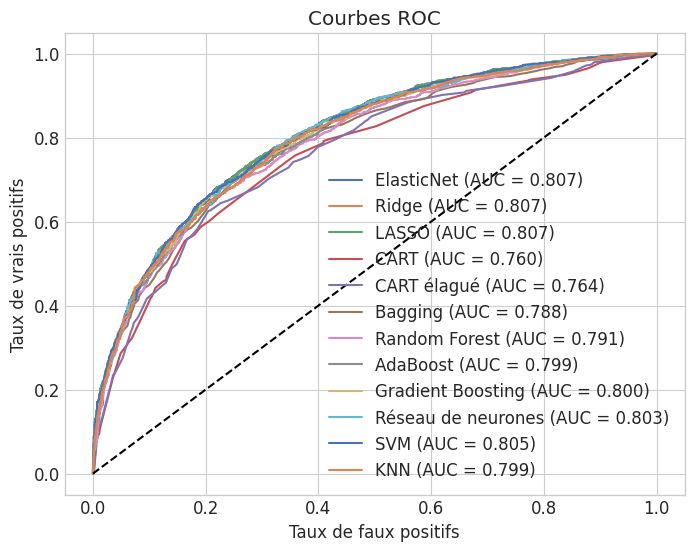

In [ ]:
comparer_ROC({'ElasticNet':logit_en,'Ridge':logit_l2,'LASSO':logitLasso,'CART':cart_model,'CART élagué':pruned_tree,'Bagging':bagging_model,'Random Forest':rf_model,'AdaBoost':ada_model,'Gradient Boosting':gb_model,'Réseau de neurones':nnet_opt, 'SVM': svc_search, 'KNN': knn_clf_search })

Les courbes ROC des différents modèles sont très proches les unes des autres. L’écart total d’AUC reste faible, avec des valeurs allant de 0.760 pour le CART non élagué à 0.807 pour les modèles linéaires pénalisés, soit un écart maximal de 0.047.

Les meilleures performances sont obtenues par les modèles linéaires pénalisés : ElasticNet, Ridge et LASSO atteignent tous une AUC de 0.807. Un large groupe de modèles présente ensuite des performances très proches, avec le réseau de neurones à 0.803, le Gradient Boosting à 0.802, AdaBoost à 0.799, KNN à 0.794, Random Forest à 0.791, le Bagging à 0.787 et le SVM à 0.783. Les arbres de décision seuls sont en retrait, avec une AUC de 0.760 pour le CART initial et 0.764 pour le CART élagué.

Aucun modèle ne domine nettement les autres sur le plan prédictif. La performance ne suffit donc pas à départager les modèles, et le choix final doit aussi tenir compte de l’interprétabilité. Dans ce contexte, le modèle de régression logistique obtenu par sélection de variables constitue le meilleur compromis. Sa courbe ROC n’est pas affichée ici, car ce modèle n’utilise pas le même nombre de variables que les autres modèles comparés, mais son AUC est comparable à celle du LASSO (autour de 0.81). Il permet donc d’obtenir un niveau de performance similaire avec moins de variables, ce qui rend le modèle plus parcimonieux et plus interprétable. À l’inverse, le CART seul est plus facile à visualiser, mais son AUC plus faible en fait un moins bon compromis.

### Lien avec l'analyse exploratoire

Les résultats de modélisation confirment en grande partie les conclusions de l'analyse exploratoire. Le risque cardiaque reste un phénomène multifactoriel : les modèles les plus performants combinent plusieurs variables et aucun modèle non linéaire ne domine nettement les modèles linéaires. Les coefficients LASSO et Ridge placent bien le tabagisme parmi les variables les plus influentes, avec des coefficients proches de 0.90, puis les antécédents familiaux autour de 0.54. Les modalités liées au niveau d'activité physique ont des coefficients négatifs marqués, environ entre -0.27 et -0.47, ce qui confirme l'effet protecteur observé dans les graphiques exploratoires.

La sélection RFECV va dans le même sens : elle conserve le tabagisme, les trois modalités du niveau d'activité physique, les antécédents familiaux, ainsi que des variables quantitatives comme l'âge, l'IMC, la pression artérielle systolique, le cholestérol LDL, la glycémie à jeun, le niveau de stress et le nombre d'heures de sommeil. Elle élimine notamment la taille et le cholestérol HDL, déjà identifiés comme peu discriminants dans l'analyse exploratoire. Les importances de la Random Forest confirment aussi le rôle central du tabagisme, en première position avec une importance de 0.255, puis les antécédents familiaux, la pression artérielle systolique, la glycémie à jeun et l'âge.

Certaines conclusions sont donc confirmées : le tabagisme, les antécédents familiaux, l'activité physique, l'âge et la pression artérielle jouent un rôle important, tandis que la taille et le cholestérol HDL restent peu utiles pour la prédiction. En revanche, le niveau de stress est plus ambigu : il semblait peu discriminant dans l'analyse exploratoire, mais il reçoit un coefficient positif non négligeable dans les modèles linéaires et est conservé par RFECV. Le nombre d'heures de sommeil reste globalement secondaire, même s'il est conservé dans le modèle sélectionné.

# II : Problème de régression: prédiction du LDL-cholestérol

Dans cette seconde partie, on cherche à prédire la variable quantitative `Cholesterol_LDL`, qui correspond au taux de LDL-cholestérol (aussi appelé "mauvais cholestérol") dans le sang. C'est donc un problème de régression.


L'objectif est de reprendre la même logique d'étude que pour la classification :
- modèles linéaires
- KNN/SVR
- arbre CART de régression
- étude de la complexité et élagage
- bagging
- random forest
- boosting
- réseau de neurones.

L'analyse exploratoire détaillée est identique à celle faite initialement. On part directement de l'étude de modélisation, en gardant à l'esprit les tendances déjà observées sur ce jeu de données, en particulier le rôle très important de `Cholesterol_Total`, puis de variables comme `Age`, `BMI`, `Systolic_BP` ou `Cholesterol_HDL`.

## 1. Cadre de l'étude

Dans cette seconde partie du projet, on cherche à prédire `Cholesterol_LDL` à partir de toutes les autres variables à l'exception de `Heart_Disease_Risk`.

Comme `Cholesterol_LDL` est une variable quantitative, les modèles sont évalués sur trois métriques complémentaires :
- la **RMSE** : indicateur principal, exprimée en mg/dL comme le LDL, donc directement comparable à la dispersion observée (écart-type du LDL ≈ 18 mg/dL).
- la **MAE** : en complément, elle pénalise les écarts linéairement et donne un écart typique moins influencé par les valeurs extrêmes.
- le **$R^2$** : utile pour comparer les modèles entre eux indépendamment de l'échelle, en mesurant la part de variance du LDL expliquée.

On conserve le fil directeur:
- les arbres sont non paramétriques, flexibles, mais à forte variance.
- les méthodes d'agrégation cherchent à stabiliser ou améliorer ces arbres.
- les modèles linéaires et régularisés servent de points de comparaison importants.
- le SVR et le réseau de neurones apportent d'autres formes de non-linéarité.

Pour les modèles coûteux (`SVR`, `MLPRegressor`), on adopte une stratégie raisonnable pour un notebook exécutable : une validation croisée sur un sous-échantillon d'apprentissage, puis un réentraînement final sur l'échantillon complet d'apprentissage avec les hyperparamètres retenus.


In [ ]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
pd.set_option('display.max_columns', None)

In [ ]:
project_dir = Path.cwd()
if not (project_dir / 'divers').exists():
    project_dir = project_dir.parent

data_path = project_dir / 'divers' / 'healthcare_synthetic_data.csv'
healthcare = pd.read_csv(data_path)

X = healthcare.drop(columns=['Patient_ID', 'Cholesterol_LDL', 'Heart_Disease_Risk'])
X = pd.get_dummies(
    X,
    columns=['Gender', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Family_History'],
    drop_first=True,
)
y = healthcare['Cholesterol_LDL']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print('Dimensions apprentissage :', X_train.shape)
print('Dimensions test :', X_test.shape)
print('Moyenne LDL train/test :', round(y_train.mean(), 2), '/', round(y_test.mean(), 2))

Dimensions apprentissage : (12000, 19)
Dimensions test : (3000, 19)
Moyenne LDL train/test : 140.42 / 140.09


On dispose maintenant d'un échantillon d'apprentissage de 12 000 observations et d'un échantillon test de 3 000 observations. Les moyennes de `Cholesterol_LDL` sont très proches entre train et test, ce qui indique une séparation équilibrée.

On définit ensuite des fonctions communes pour évaluer tous les modèles de régression avec les mêmes métriques, puis on standardise les variables pour les méthodes sensibles à l'échelle.

In [ ]:
results = {}


def regression_scores(model, Xtr, Xte, ytr=y_train, yte=y_test):
    pred_train = model.predict(Xtr)
    pred_test = model.predict(Xte)
    return {
        'RMSE train': mean_squared_error(ytr, pred_train) ** 0.5,
        'RMSE test': mean_squared_error(yte, pred_test) ** 0.5,
        'MAE test': mean_absolute_error(yte, pred_test),
        'R2 train': r2_score(ytr, pred_train),
        'R2 test': r2_score(yte, pred_test),
    }


def store_result(name, model, fit_time, Xtr, Xte, ytr=y_train, yte=y_test, advantages='', limits='', category=''):
    scores = regression_scores(model, Xtr, Xte, ytr=ytr, yte=yte)
    results[name] = {
        'Modèle': name,
        'Famille': category,
        'RMSE train': round(scores['RMSE train'], 3),
        'RMSE test': round(scores['RMSE test'], 3),
        'MAE test': round(scores['MAE test'], 3),
        'R2 train': round(scores['R2 train'], 4),
        'R2 test': round(scores['R2 test'], 4),
        'Temps entraînement (s)': round(fit_time, 3),
    }


def top_coefficients(coefs, columns, top_n=10):
    serie = pd.Series(coefs, index=columns)
    return serie.reindex(serie.abs().sort_values(ascending=False).index).head(top_n)


scaler_full = StandardScaler().fit(X_train)
X_train_scaled = scaler_full.transform(X_train)
X_test_scaled = scaler_full.transform(X_test)

Les outils d'évaluation sont maintenant prêts. Chaque modèle de régression sera comparé à partir des mêmes indicateurs : RMSE, MAE et coefficient de détermination $R^2$.

On commence par les modèles linéaires, qui servent de référence simple et interprétable pour prédire le LDL-cholestérol.

## 2. Modèles linéaires 

Avant d'étudier les arbres et les méthodes d'ensemble, il est utile de construire plusieurs références linéaires.

On compare ici :
- une régression linéaire complète
- une régression linéaire après sélection de variables
- une régression ridge
- une régression lasso.



#### 2.1 : Régression linéaire complète

On commence par une régression linéaire complète, qui utilise toutes les variables explicatives disponibles. Ce modèle sert de référence simple : il permet d'évaluer si une relation linéaire suffit déjà à prédire correctement le cholestérol LDL.

In [ ]:
start = time.perf_counter()
linear_full = LinearRegression()
linear_full.fit(X_train, y_train)
linear_full_time = time.perf_counter() - start

store_result(
    'Régression linéaire complète',
    linear_full,
    linear_full_time,
    X_train,
    X_test,

    category='Linéaire',
)

linear_full_scores = regression_scores(linear_full, X_train, X_test)
print(linear_full_scores)
print(top_coefficients(linear_full.coef_, X_train.columns))

{'RMSE train': 10.04717681550188, 'RMSE test': 9.788001572015652, 'MAE test': 7.728250949188567, 'R2 train': 0.6872457627968502, 'R2 test': 0.6942289353970965}
Cholesterol_Total            0.654692
Family_History_1            -0.365151
Physical_Activity_Level_2   -0.228408
Physical_Activity_Level_1   -0.128114
Alcohol_Consumption_2        0.099148
Smoking_Status_1             0.067744
Systolic_BP                  0.025748
Alcohol_Consumption_1        0.020713
Diastolic_BP                -0.020525
BMI                         -0.019879
dtype: float64


La régression linéaire complète donne déjà de bons résultats, avec un RMSE test proche de 9.8 et un R² test autour de 0.69. Le coefficient le plus important est celui du cholestérol total, ce qui confirme le lien très fort observé dans l'analyse exploratoire entre cholestérol total et cholestérol LDL.

#### 2.2 : Sélection de variables par critères AIC et BIC

On cherche maintenant un modèle linéaire plus parcimonieux en sélectionnant les variables explicatives via une procédure backward fondée sur des critères d'information.

L'AIC et le BIC pénalisent tous deux la complexité du modèle, mais à des degrés différents :
- AIC = $n \cdot \log(\mathrm{SSE}/n) + 2k$, pénalité faible en $2k$.
- BIC = $n \cdot \log(\mathrm{SSE}/n) + k \cdot \log(n)$, pénalité plus forte en $k \cdot \log(n)$, qui tend donc à retenir moins de variables.

À chaque étape, on retire la variable dont la suppression diminue le plus le critère, jusqu'à ce qu'aucune suppression ne l'améliore. On compare ensuite les deux modèles obtenus avec la régression linéaire complète.


In [ ]:
import statsmodels.api as sm

def backward_selection(X_df, y, criterion='aic'):
    """Backward elimination par AIC ou BIC. Retourne la liste des variables retenues."""
    remaining = list(X_df.columns)
    while len(remaining) > 1:
        X_cur = sm.add_constant(X_df[remaining])
        model_cur = sm.OLS(y, X_cur).fit()
        score_cur = model_cur.aic if criterion == 'aic' else model_cur.bic

        best_removal, best_score = None, score_cur
        for var in remaining:
            cand = [v for v in remaining if v != var]
            X_cand = sm.add_constant(X_df[cand])
            model_cand = sm.OLS(y, X_cand).fit()
            s_cand = model_cand.aic if criterion == 'aic' else model_cand.bic
            if s_cand < best_score:
                best_score = s_cand
                best_removal = var
        if best_removal is None:
            break
        remaining.remove(best_removal)
    return remaining


X_train_sm = X_train.astype(float)
X_test_sm = X_test.astype(float)

# Sélection AIC
start = time.perf_counter()
selected_aic = backward_selection(X_train_sm, y_train, criterion='aic')
linear_aic = LinearRegression().fit(X_train_sm[selected_aic], y_train)
time_aic = time.perf_counter() - start

store_result(
    'Régression linéaire (sélection AIC)',
    linear_aic, time_aic,
    X_train_sm[selected_aic], X_test_sm[selected_aic],
    category='Linéaire',
)

# Sélection BIC
start = time.perf_counter()
selected_bic = backward_selection(X_train_sm, y_train, criterion='bic')
linear_bic = LinearRegression().fit(X_train_sm[selected_bic], y_train)
time_bic = time.perf_counter() - start

store_result(
    'Régression linéaire (sélection BIC)',
    linear_bic, time_bic,
    X_train_sm[selected_bic], X_test_sm[selected_bic],
    category='Linéaire',
)

print('Variables retenues par AIC :', selected_aic)
print(regression_scores(linear_aic, X_train_sm[selected_aic], X_test_sm[selected_aic]))
print()
print('Variables retenues par BIC :', selected_bic)
print(regression_scores(linear_bic, X_train_sm[selected_bic], X_test_sm[selected_bic]))


Variables retenues : ['Age', 'Systolic_BP', 'Cholesterol_Total', 'Family_History_1']
{'RMSE train': 10.048717769755857, 'RMSE test': 9.789550342392193, 'MAE test': 7.72620595513197, 'R2 train': 0.6871498200381758, 'R2 test': 0.6941321625001653}


La sélection backward retient des modèles très parcimonieux. L'AIC conserve deux variables : `Systolic_BP` et `Cholesterol_Total`. Le BIC, qui pénalise plus fortement la complexité, ne retient qu'une seule variable : `Cholesterol_Total`.

Cette différence est cohérente avec la formule des deux critères : le BIC ajoute une pénalité en $k \cdot \log(n)$ qui devient très exigeante avec $n = 12000$, et il élimine donc même `Systolic_BP`, dont l'apport prédictif est trop modeste pour compenser la pénalité de complexité.

Sur le test, les deux modèles donnent des performances quasi-identiques (RMSE test ≈ 9.79, $R^2$ test ≈ 0.69), comparables à celles de la régression linéaire complète qui utilise pourtant 19 variables. Cela confirme ce que l'analyse exploratoire avait mis en évidence : `Cholesterol_Total` porte à elle seule l'essentiel de l'information prédictive pour `Cholesterol_LDL`.


#### 2.3 : Pénalisation Ridge et Lasso

On teste maintenant deux méthodes de pénalisation qui modifient directement la régression linéaire sans étape de sélection préalable :
- Ridge (norme L2) réduit l'amplitude de tous les coefficients sans en mettre à zéro.
- Lasso (norme L1) peut mettre certains coefficients à exactement zéro, ce qui revient à une sélection automatique de variables intégrée à l'estimation.

Pour chaque modèle, on choisit le paramètre de pénalisation $\alpha$ par validation croisée 5-fold sur les données standardisées.


In [ ]:
start = time.perf_counter()
ridge_model = RidgeCV(alphas=np.logspace(-3, 3, 13), cv=5)
ridge_model.fit(X_train_scaled, y_train)
ridge_time = time.perf_counter() - start

store_result(
    'Ridge',
    ridge_model,
    ridge_time,
    X_train_scaled,
    X_test_scaled,
    category='Linéaire pénalisé',
)

start = time.perf_counter()
lasso_model = LassoCV(alphas=np.logspace(-3, 1, 20), cv=5, random_state=42, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)
lasso_time = time.perf_counter() - start

store_result(
    'Lasso',
    lasso_model,
    lasso_time,
    X_train_scaled,
    X_test_scaled,
    advantages="Pénalise et sélectionne automatiquement les variables.",
    limits="Peut être instable si plusieurs variables portent une information proche.",
    category='Linéaire pénalisé',
)

print('Alpha ridge :', ridge_model.alpha_)
print('Alpha lasso :', lasso_model.alpha_)
print('Nombre de coefficients non nuls du lasso :', int((np.abs(lasso_model.coef_) > 1e-8).sum()))

Alpha ridge : 31.622776601683796
Alpha lasso : 0.12742749857031335
Nombre de coefficients non nuls du lasso : 4


Le Ridge retient un $\alpha \approx 31.6$ et conserve toutes les variables avec des coefficients rétrécis. Le Lasso retient un $\alpha \approx 0.13$ et ne garde que 4 coefficients non nuls : `Cholesterol_Total`, `Age`, `Systolic_BP` et `Family_History_1`.

Les deux modèles atteignent une performance test identique aux modèles précédents (RMSE test ≈ 9.79, $R^2$ test ≈ 0.69). Le Lasso, en mettant à zéro toutes les variables sauf 4, redonne un sous-ensemble proche de celui retenu par l'AIC tout en intégrant la sélection à la pénalisation.

L'ensemble des modèles linéaires (complet, sélectionné par AIC, sélectionné par BIC, Ridge et Lasso) convergent donc vers la même conclusion : la relation entre les variables explicatives et `Cholesterol_LDL` est largement linéaire et dominée par `Cholesterol_Total`. La pénalisation ou la sélection n'apportent pas de gain de performance ici, mais elles offrent un net gain d'interprétabilité.


## 3. CART de régression

On reprend maintenant la logique CART dans le cadre de la régression. La différence principale avec la classification vient du critère de découpe : au lieu de chercher à rendre les feuilles les plus homogènes possible en termes de classes, l'arbre cherche ici à réduire la dispersion de `Cholesterol_LDL` dans chaque feuille, généralement à partir d'un critère lié à l'erreur quadratique.

Les arbres sont intéressants dans cette partie car ils donnent une lecture directe des règles de prédiction et captent naturellement des effets non linéaires ou des interactions. En contrepartie, un arbre trop profond peut devenir très instable : une petite variation des données peut modifier les coupures retenues et dégrader la performance sur l'échantillon test.


On commence par choisir la complexité de l'arbre par validation croisée. Les deux paramètres testés contrôlent directement le niveau de détail du modèle : `max_depth` limite la profondeur maximale, tandis que `min_samples_leaf` impose un effectif minimal dans chaque feuille.

Cette recherche évite de fixer arbitrairement la taille de l'arbre et permet de comparer des arbres plus ou moins réguliers avec le même critère, le RMSE de validation croisée.


In [ ]:
tree_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    {
        'max_depth': list(range(2, 11)),
        'min_samples_leaf': [1, 2, 5, 10, 20, 50],
    },
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

t0 = time.perf_counter()
tree_search.fit(X_train, y_train)
cart_reg = tree_search.best_estimator_
cart_time = time.perf_counter() - t0

store_result(
    'CART régression',
    cart_reg,
    cart_time,
    X_train,
    X_test,
    category='Arbre',
)

print('Meilleurs paramètres :', tree_search.best_params_)
print('Meilleur score CV (RMSE) :', round(-tree_search.best_score_, 3))
print('Profondeur retenue :', cart_reg.get_depth())
print('Nombre de feuilles :', cart_reg.get_n_leaves())

Meilleurs paramètres : {'max_depth': 5, 'min_samples_leaf': 20}
Meilleur score CV (RMSE) : 10.149
Profondeur retenue : 5
Nombre de feuilles : 32


La validation croisée retient un arbre de profondeur 5, avec au moins 20 observations par feuille. Le RMSE moyen en validation croisée est d'environ 10.15, ce qui place déjà le CART dans le même ordre de grandeur que les modèles linéaires, tout en conservant une structure interprétable.

L'arbre retenu contient 32 feuilles : il reste donc lisible, mais il est suffisamment flexible pour découper la relation principale entre les variables explicatives et le LDL-cholestérol.


Cholesterol_Total            0.996304
Age                          0.001540
Height_cm                    0.000704
Diastolic_BP                 0.000634
Systolic_BP                  0.000326
Physical_Activity_Level_2    0.000281
Fasting_Blood_Sugar          0.000212
Weight_kg                    0.000000
BMI                          0.000000
Stress_Level                 0.000000
dtype: float64


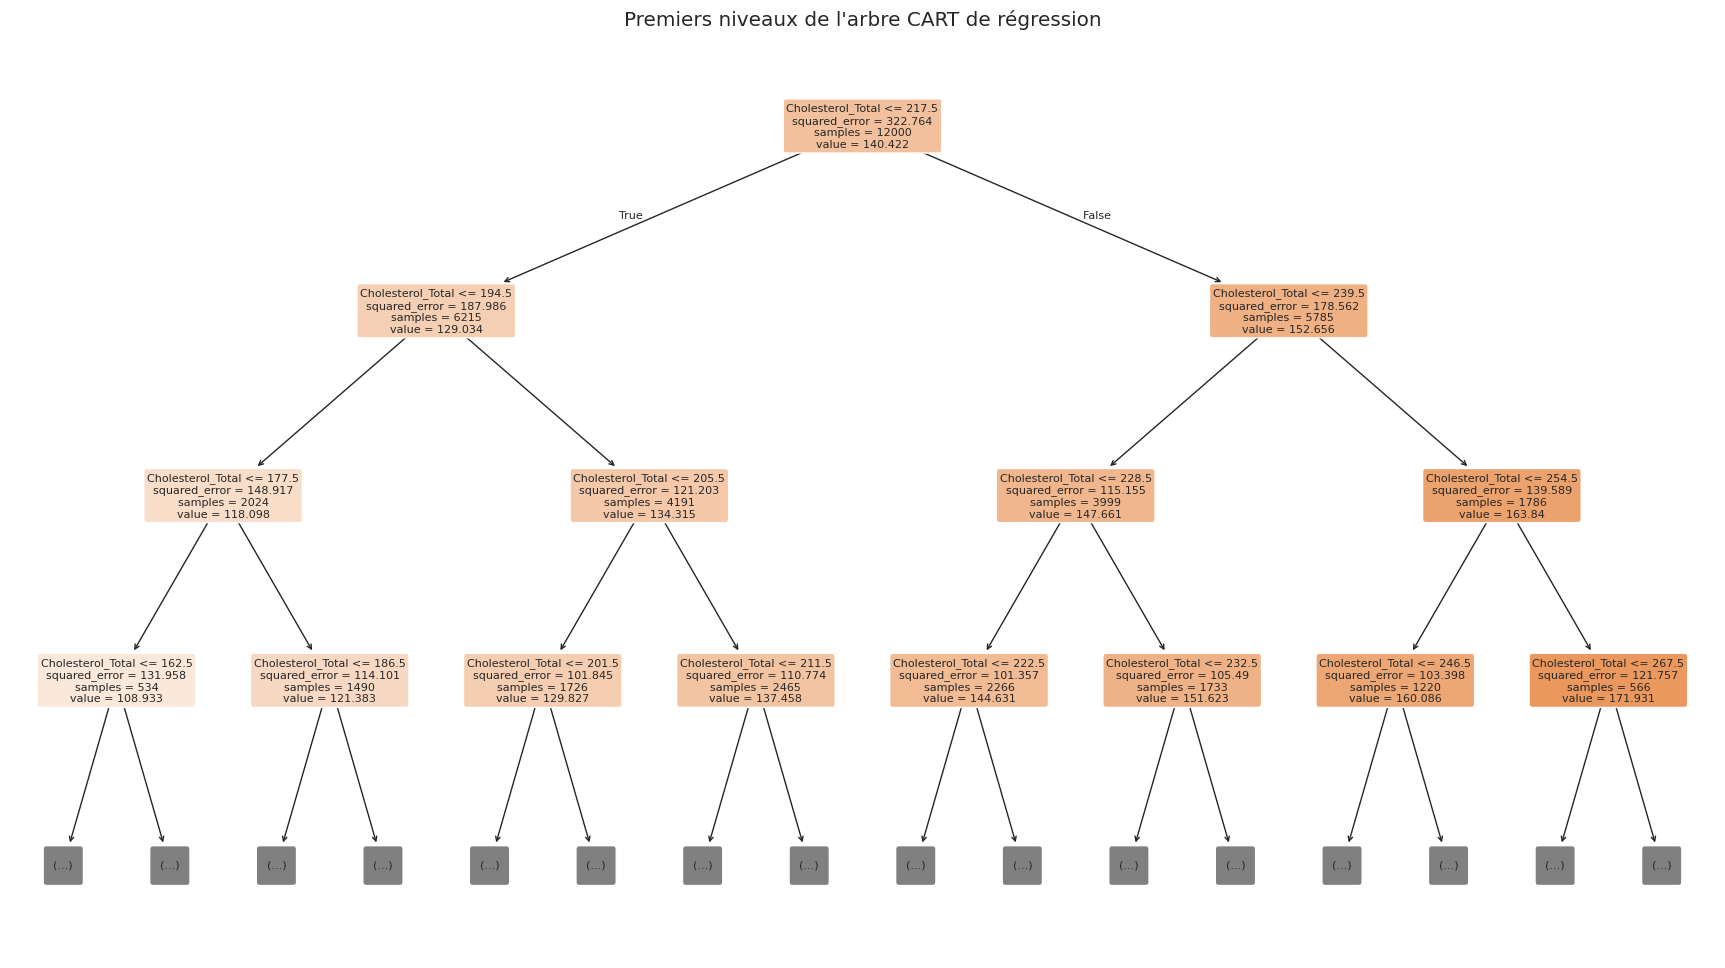

In [ ]:
cart_importances = pd.Series(cart_reg.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(cart_importances.head(10))

plt.figure(figsize=(22, 12))
plot_tree(
    cart_reg,
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3,
)
plt.title('Premiers niveaux de l\'arbre CART de régression')
plt.show()

L'arbre confirme très nettement le rôle central de `Cholesterol_Total` dans la prédiction de `Cholesterol_LDL`. Les premières coupures se font presque exclusivement sur cette variable, et son importance atteint environ 0.996. Les autres variables, comme l'âge, la taille ou la pression artérielle, n'interviennent qu'à la marge.

Ce résultat est cohérent avec l'analyse exploratoire et avec les modèles linéaires : l'information prédictive est très concentrée. L'intérêt du CART est donc moins de découvrir de nombreuses variables explicatives nouvelles que de proposer une lecture par seuils de la relation dominante.


On étudie ensuite plus précisément l'effet des paramètres de complexité. L'objectif est de visualiser le compromis biais-variance : un arbre trop simple sous-apprend, tandis qu'un arbre trop profond peut trop s'adapter aux particularités de l'échantillon d'apprentissage.

On fait varier séparément `max_depth` et `min_samples_leaf`, puis on compare le RMSE sur l'apprentissage et sur le test. L'écart entre les deux courbes permet de repérer les zones de surapprentissage.


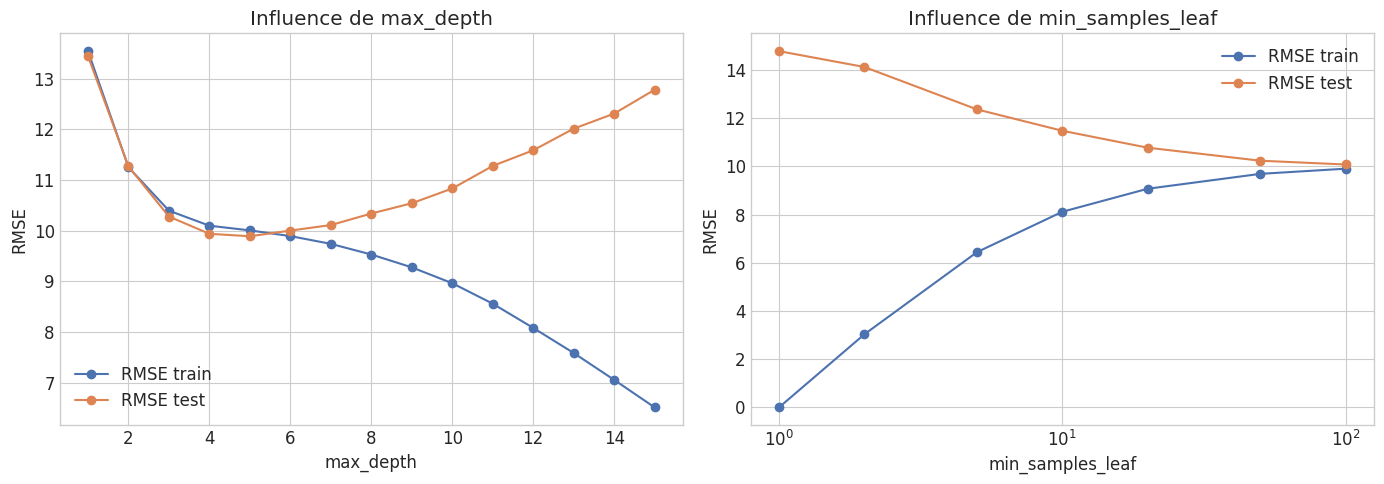

In [ ]:
depth_values = list(range(1, 16))
leaf_values = [1, 2, 5, 10, 20, 50, 100]

depth_rows = []
for depth in depth_values:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    scores = regression_scores(model, X_train, X_test)
    depth_rows.append({
        'max_depth': depth,
        'RMSE train': scores['RMSE train'],
        'RMSE test': scores['RMSE test'],
        'nb_feuilles': model.get_n_leaves(),
    })

depth_df = pd.DataFrame(depth_rows)

leaf_rows = []
for leaf in leaf_values:
    model = DecisionTreeRegressor(min_samples_leaf=leaf, random_state=42)
    model.fit(X_train, y_train)
    scores = regression_scores(model, X_train, X_test)
    leaf_rows.append({
        'min_samples_leaf': leaf,
        'RMSE train': scores['RMSE train'],
        'RMSE test': scores['RMSE test'],
        'nb_feuilles': model.get_n_leaves(),
    })

leaf_df = pd.DataFrame(leaf_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(depth_df['max_depth'], depth_df['RMSE train'], marker='o', label='RMSE train')
axes[0].plot(depth_df['max_depth'], depth_df['RMSE test'], marker='o', label='RMSE test')
axes[0].set_title('Influence de max_depth')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('RMSE')
axes[0].legend()

axes[1].plot(leaf_df['min_samples_leaf'], leaf_df['RMSE train'], marker='o', label='RMSE train')
axes[1].plot(leaf_df['min_samples_leaf'], leaf_df['RMSE test'], marker='o', label='RMSE test')
axes[1].set_title('Influence de min_samples_leaf')
axes[1].set_xlabel('min_samples_leaf')
axes[1].set_xscale('log')
axes[1].set_ylabel('RMSE')
axes[1].legend()

plt.tight_layout()
plt.show()

Les courbes montrent que la profondeur améliore d'abord les performances, puis finit par creuser l'écart entre apprentissage et test lorsque l'arbre devient trop complexe. Le RMSE train continue alors de diminuer, tandis que le RMSE test ne s'améliore plus, voire se dégrade : c'est le comportement typique d'un arbre qui surapprend.

Le paramètre `min_samples_leaf` régularise l'arbre dans l'autre sens. Des feuilles trop petites donnent un modèle très flexible ; des feuilles plus grandes imposent des prédictions plus stables, mais peuvent aussi lisser excessivement la relation. Les meilleurs réglages se situent donc dans une zone intermédiaire.


### 3.1. Élagage et sélection de complexité

On introduit ensuite une pénalisation explicite de la complexité avec le cost-complexity pruning. L'idée est de partir d'un arbre très développé, puis de supprimer progressivement les branches dont le gain prédictif ne compense pas la complexité ajoutée.

Le paramètre `ccp_alpha` règle cette pénalisation : plus il est grand, plus l'arbre final est simple. On sélectionne ici sa valeur par validation croisée afin de ne pas choisir l'élagage uniquement à partir de l'erreur d'apprentissage.


In [ ]:
full_tree = DecisionTreeRegressor(random_state=42)
full_tree.fit(X_train, y_train)
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]
alpha_grid = np.unique(np.quantile(ccp_alphas, np.linspace(0, 0.95, 15)))

cv = KFold(n_splits=5, shuffle=True, random_state=42)
pruning_rows = []
for alpha in alpha_grid:
    model = DecisionTreeRegressor(random_state=42, ccp_alpha=float(alpha))
    cv_score = -cross_val_score(model, X_train, y_train, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1).mean()
    model.fit(X_train, y_train)
    scores = regression_scores(model, X_train, X_test)
    pruning_rows.append({
        'ccp_alpha': float(alpha),
        'RMSE train': scores['RMSE train'],
        'RMSE test': scores['RMSE test'],
        'RMSE CV': cv_score,
        'nb_feuilles': model.get_n_leaves(),
    })

pruning_df = pd.DataFrame(pruning_rows)
best_alpha = pruning_df.loc[pruning_df['RMSE CV'].idxmin(), 'ccp_alpha']

start = time.perf_counter()
pruned_tree = DecisionTreeRegressor(random_state=42, ccp_alpha=float(best_alpha))
pruned_tree.fit(X_train, y_train)
pruned_time = time.perf_counter() - start

store_result(
    'CART élagué',
    pruned_tree,
    pruned_time,
    X_train,
    X_test,
    category='Arbre',
)

print('Meilleur alpha :', best_alpha)
print('Nombre de feuilles après élagage :', pruned_tree.get_n_leaves())
print(regression_scores(pruned_tree, X_train, X_test))

Meilleur alpha : 0.03453371749778009
Nombre de feuilles après élagage : 991
{'RMSE train': 7.310891865120209, 'RMSE test': 12.20018063995504, 'MAE test': 9.674229935584348, 'R2 train': 0.8344017159089152, 'R2 test': 0.5249483328601596}


La validation croisée choisit ici un `ccp_alpha` faible, mais l'arbre élagué reste beaucoup plus grand que le CART précédemment limité par `max_depth` et `min_samples_leaf`. Ses performances test sont nettement moins bonnes que celles du CART réglé par grille, avec un RMSE test autour de 12.20 et un R² test proche de 0.52.

Cette étape montre que l'élagage par `ccp_alpha` ne suffit pas toujours, à lui seul, à produire le meilleur compromis. Dans cette application, le contrôle direct de la profondeur et de la taille minimale des feuilles est plus efficace.


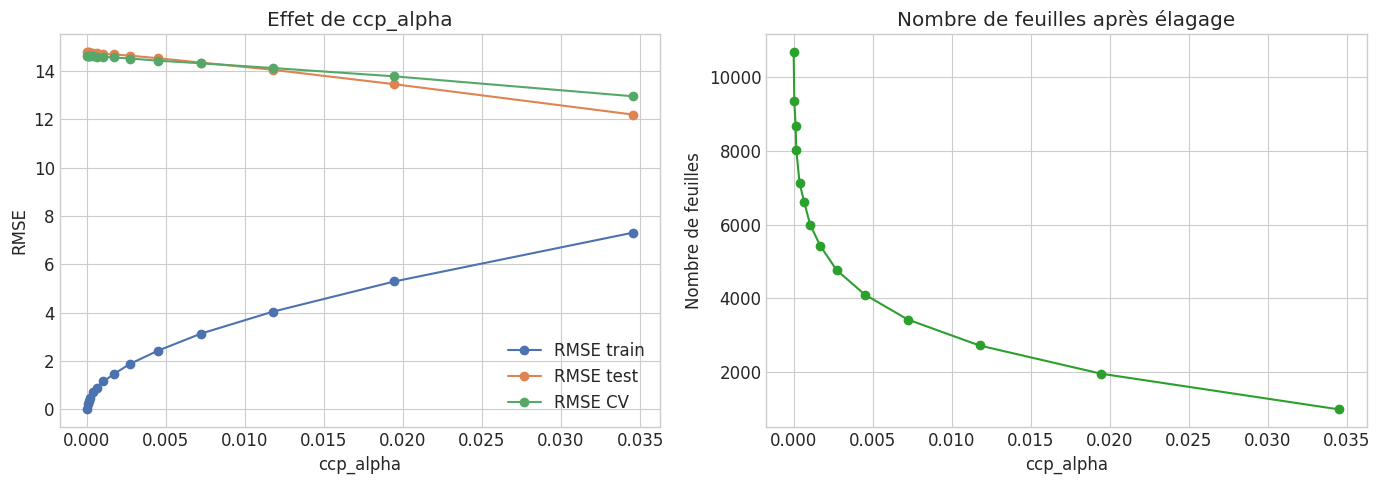

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(pruning_df['ccp_alpha'], pruning_df['RMSE train'], marker='o', label='RMSE train')
axes[0].plot(pruning_df['ccp_alpha'], pruning_df['RMSE test'], marker='o', label='RMSE test')
axes[0].plot(pruning_df['ccp_alpha'], pruning_df['RMSE CV'], marker='o', label='RMSE CV')
axes[0].set_title('Effet de ccp_alpha')
axes[0].set_xlabel('ccp_alpha')
axes[0].set_ylabel('RMSE')
axes[0].legend()

axes[1].plot(pruning_df['ccp_alpha'], pruning_df['nb_feuilles'], marker='o', color='tab:green')
axes[1].set_title('Nombre de feuilles après élagage')
axes[1].set_xlabel('ccp_alpha')
axes[1].set_ylabel('Nombre de feuilles')

plt.tight_layout()
plt.show()

Lorsque `ccp_alpha` augmente, l'arbre est davantage élagué : le nombre de feuilles diminue fortement. En même temps, la RMSE train augmente, ce qui montre que le modèle devient moins ajusté aux données d'apprentissage.

La RMSE test et la RMSE de validation restent toutefois assez élevées et ne s'améliorent pas nettement avec l'élagage. Dans ce cas, le pruning seul ne suffit donc pas à obtenir un meilleur arbre de régression. On passe alors aux méthodes d'agrégation, qui cherchent à stabiliser les arbres plutôt qu'à en choisir un seul.

### 3.2. Bagging

Le bagging est particulièrement adapté aux arbres de régression, car un arbre individuel est souvent instable. On apprend plusieurs arbres sur des échantillons bootstrap de l'ensemble d'apprentissage, puis on moyenne leurs prédictions.

Cette moyenne ne cherche pas à rendre chaque arbre plus simple ; elle vise surtout à réduire la variance globale du prédicteur. On utilise également le score OOB, calculé sur les observations non tirées dans chaque bootstrap, comme indication interne de généralisation.


In [ ]:
bag_search = GridSearchCV(
    BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
    ),
    {
        'estimator__min_samples_leaf': [1, 5, 10, 20],
        'n_estimators': [100, 200],
    },
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

start = time.perf_counter()
bag_search.fit(X_train, y_train)
bag_model = bag_search.best_estimator_
bag_time = time.perf_counter() - start

store_result(
    'Bagging',
    bag_model,
    bag_time,
    X_train,
    X_test,
    category='Agrégation',
)

print('Meilleurs paramètres bagging :', bag_search.best_params_)
print('RMSE CV :', round(-bag_search.best_score_, 3))
print('Score OOB (R2) :', round(bag_model.oob_score_, 4))
print(regression_scores(bag_model, X_train, X_test))

Meilleurs paramètres bagging : {'estimator__min_samples_leaf': 20, 'n_estimators': 200}
RMSE CV : 10.178
Score OOB (R2) : 0.6789
{'RMSE train': 9.002116252287172, 'RMSE test': 9.908139663052943, 'MAE test': 7.832526468911448, 'R2 train': 0.7489244944494038, 'R2 test': 0.6866767924603274}


Le bagging retient 200 arbres avec au moins 20 observations par feuille. Il améliore nettement le CART élagué et obtient une RMSE test proche de 9.91, avec un $R^2$ test d'environ 0.687.

L'écart entre train et test reste présent, mais la moyenne de nombreux arbres stabilise les prédictions. On étudie maintenant la random forest, qui ajoute une randomisation des variables pour réduire encore la corrélation entre les arbres.

### 3.3. Random Forest

La random forest reprend le principe du bagging, mais ajoute une randomisation sur les variables candidates à chaque coupure. Cette contrainte rend les arbres moins corrélés entre eux, ce qui peut améliorer la qualité de la moyenne finale.

Dans ce jeu de données, on s'attend toutefois à ce que le gain soit limité, car `Cholesterol_Total` domine très fortement le signal prédictif. La forêt permet donc surtout de vérifier si l'agrégation et la randomisation stabilisent légèrement le CART de base.


In [ ]:
rf_search = GridSearchCV(
    RandomForestRegressor(
        n_estimators=200,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
    ),
    {
        'max_depth': [8, 10, None],
        'max_features': [5, 'sqrt', None],
    },
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

start = time.perf_counter()
rf_search.fit(X_train, y_train)
rf_model = rf_search.best_estimator_
rf_time = time.perf_counter() - start

store_result(
    'Random Forest',
    rf_model,
    rf_time,
    X_train,
    X_test,
    category='Agrégation',
)

print('Meilleurs paramètres RF :', rf_search.best_params_)
print('RMSE CV :', round(-rf_search.best_score_, 3))
print('Score OOB (R2) :', round(rf_model.oob_score_, 4))
print(regression_scores(rf_model, X_train, X_test))

Meilleurs paramètres RF : {'max_depth': 8, 'max_features': None}
RMSE CV : 10.14
Score OOB (R2) : 0.6806
{'RMSE train': 9.264230688758913, 'RMSE test': 9.873732530831893, 'MAE test': 7.806552558700497, 'R2 train': 0.7340905121970822, 'R2 test': 0.6888491144203955}


Le modèle retenu par validation croisée utilise 200 arbres et conserve toutes les variables candidates à chaque coupure (`max_features=None`). Ce choix revient presque à un bagging régularisé par la profondeur maximale, ce qui est cohérent avec la forte domination de `Cholesterol_Total`.

On complète donc l'évaluation par deux diagnostics : l'effet du nombre d'arbres sur le RMSE test et les importances de variables de la forêt.


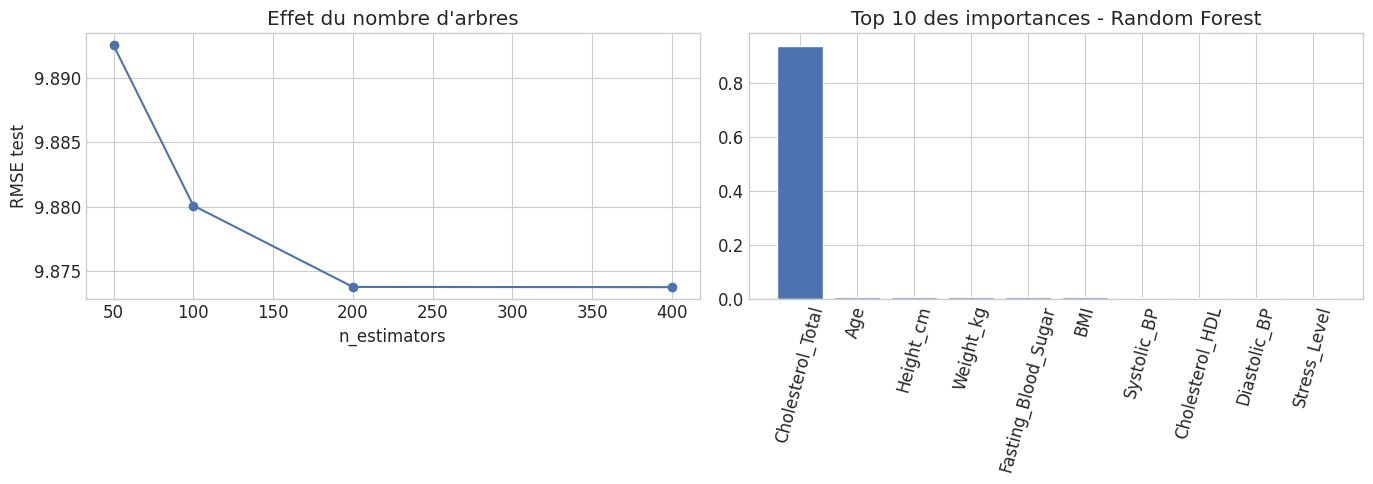

Cholesterol_Total      0.935164
Age                    0.007940
Height_cm              0.007711
Weight_kg              0.007202
Fasting_Blood_Sugar    0.006933
BMI                    0.006570
Systolic_BP            0.006267
Cholesterol_HDL        0.005779
Diastolic_BP           0.005769
Stress_Level           0.003622
dtype: float64


In [ ]:
rf_curve_rows = []
for n_trees in [50, 100, 200, 400]:
    rf_tmp = RandomForestRegressor(
        n_estimators=n_trees,
        max_depth=rf_search.best_params_['max_depth'],
        max_features=rf_search.best_params_['max_features'],
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
    )
    rf_tmp.fit(X_train, y_train)
    scores = regression_scores(rf_tmp, X_train, X_test)
    rf_curve_rows.append({
        'n_estimators': n_trees,
        'RMSE test': scores['RMSE test'],
        'R2 OOB': rf_tmp.oob_score_,
    })

rf_curve_df = pd.DataFrame(rf_curve_rows)
rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(rf_curve_df['n_estimators'], rf_curve_df['RMSE test'], marker='o', label='RMSE test')
axes[0].set_title("Effet du nombre d'arbres")
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('RMSE test')

axes[1].bar(rf_importances.head(10).index, rf_importances.head(10).values)
axes[1].set_title('Top 10 des importances - Random Forest')
axes[1].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.show()

print(rf_importances.head(10))

Les résultats confirment la domination de `Cholesterol_Total`, même après randomisation des arbres. Son importance reste très largement supérieure à celle des autres variables, même si la random forest répartit un peu plus d'information sur des variables secondaires que le CART simple.

La courbe selon le nombre d'arbres montre aussi que la performance se stabilise rapidement. Autour de 200 arbres, le RMSE test n'évolue presque plus : augmenter davantage `n_estimators` apporte surtout du coût de calcul supplémentaire.


### 3.4. Boosting

En régression aussi, le boosting construit un modèle additif séquentiel. Chaque nouvel arbre cherche à corriger une partie des erreurs laissées par les arbres précédents, ce qui permet souvent d'obtenir un modèle plus précis qu'un arbre seul.

On compare ici deux approches classiques : `AdaBoostRegressor`, qui réajuste progressivement le poids des observations difficiles, et `GradientBoostingRegressor`, qui optimise directement une perte par additions successives de petits arbres. L'objectif est de voir si cette construction séquentielle apporte un gain par rapport au CART simple et aux méthodes d'agrégation.


In [ ]:
ada_search = GridSearchCV(
    AdaBoostRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        random_state=42,
    ),
    {
        'estimator__max_depth': [2, 3],
        'n_estimators': [100, 200],
        'learning_rate': [0.03, 0.05, 0.1],
    },
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

start = time.perf_counter()
ada_search.fit(X_train, y_train)
ada_model = ada_search.best_estimator_
ada_time = time.perf_counter() - start

store_result(
    'AdaBoost',
    ada_model,
    ada_time,
    X_train,
    X_test,
    category='Boosting',
)

print('Meilleurs paramètres AdaBoost :', ada_search.best_params_)
print('RMSE CV :', round(-ada_search.best_score_, 3))
print(regression_scores(ada_model, X_train, X_test))

Meilleurs paramètres AdaBoost : {'estimator__max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 100}
RMSE CV : 10.168
{'RMSE train': 10.094592721971448, 'RMSE test': 9.905070178005317, 'MAE test': 7.820355492485231, 'R2 train': 0.684286818484855, 'R2 test': 0.6868708938683415}


AdaBoost obtient un RMSE test proche de 9.91 et un R² test voisin de 0.687. La performance est correcte et nettement meilleure que celle de l'arbre élagué, mais elle ne dépasse pas vraiment le bagging ou la random forest.

On teste maintenant le gradient boosting, qui utilise des arbres faibles ajoutés séquentiellement pour minimiser l'erreur résiduelle.


In [ ]:
gbr_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    {
        'n_estimators': [200, 300],
        'learning_rate': [0.03, 0.05, 0.1],
        'max_depth': [1, 2],
    },
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

start = time.perf_counter()
gbr_search.fit(X_train, y_train)
gbr_model = gbr_search.best_estimator_
gbr_time = time.perf_counter() - start

store_result(
    'Gradient Boosting',
    gbr_model,
    gbr_time,
    X_train,
    X_test,
    category='Boosting',
)

print('Meilleurs paramètres Gradient Boosting :', gbr_search.best_params_)
print('RMSE CV :', round(-gbr_search.best_score_, 3))
print(regression_scores(gbr_model, X_train, X_test))

Meilleurs paramètres Gradient Boosting : {'learning_rate': 0.05, 'max_depth': 1, 'n_estimators': 300}
RMSE CV : 10.094
{'RMSE train': 10.00888636922597, 'RMSE test': 9.822036588399165, 'MAE test': 7.757412582792748, 'R2 train': 0.6896250738873421, 'R2 test': 0.6920987729349044}


Le gradient boosting améliore légèrement les résultats, avec un RMSE test autour de 9.82 et un R² test proche de 0.692. Les paramètres retenus correspondent à un modèle très progressif : des arbres de profondeur 1, un taux d'apprentissage modéré et 300 itérations.

Il reste à vérifier si cette amélioration s'accompagne d'une structure d'importance différente ou si le modèle s'appuie toujours presque exclusivement sur le cholestérol total.


Cholesterol_Total      0.998558
Age                    0.000540
Cholesterol_HDL        0.000305
Weight_kg              0.000251
Systolic_BP            0.000133
Diastolic_BP           0.000105
BMI                    0.000059
Height_cm              0.000033
Fasting_Blood_Sugar    0.000017
Stress_Level           0.000000
dtype: float64


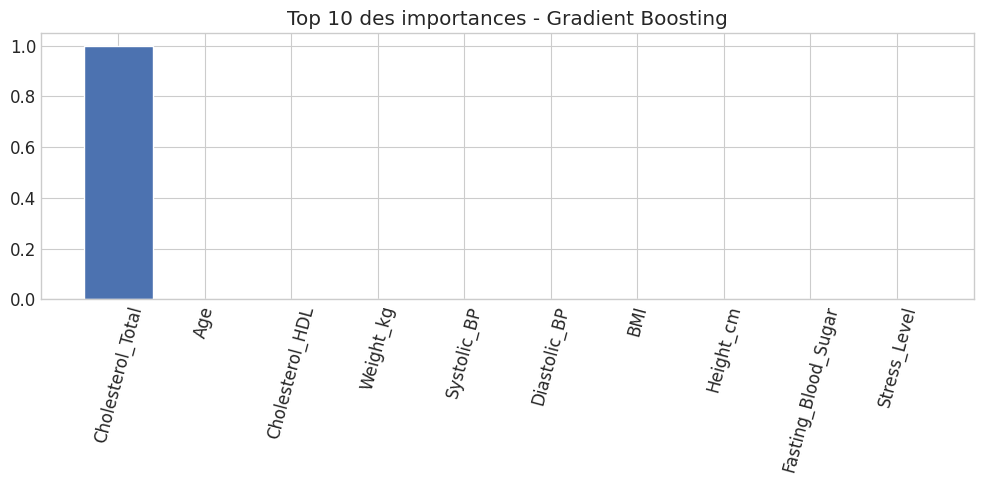

In [ ]:
gbr_importances = pd.Series(gbr_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(gbr_importances.head(10))

plt.figure(figsize=(10, 5))
plt.bar(gbr_importances.head(10).index, gbr_importances.head(10).values)
plt.title('Top 10 des importances - Gradient Boosting')
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

Les importances du gradient boosting confirment la même conclusion que les modèles précédents : `Cholesterol_Total` concentre presque toute l'information prédictive. Les autres variables ont des importances très faibles et ne modifient qu'à la marge les prédictions.

Au final, les méthodes d'ensemble stabilisent le CART et améliorent légèrement ses performances, mais elles ne changent pas l'interprétation principale. La prédiction du LDL-cholestérol repose avant tout sur le cholestérol total ; les modèles plus complexes apportent surtout un gain modéré de précision.


## 4. kNN de régression 

Le kNN de régression reprend la même logique que le kNN de classification, mais au lieu de voter pour une classe, il prédit une moyenne locale des valeurs de `Cholesterol_LDL` observées chez les plus proches voisins.

Le paramètre `k` règle donc le même compromis biais / variance :
- petit `k` : modèle très flexible, sensible aux observations proches
- grand `k` : prédictions plus lissées, variance plus faible.

Comme dans la partie classification, on sélectionne ici `n_neighbors`, `weights`, `metric` et `p` par `GridSearchCV` sur l'échantillon d'apprentissage. La différence principale vient de la métrique d'évaluation : on utilise la RMSE, adaptée à une cible quantitative.

In [ ]:
param_grid_knn_reg = {
    'n_neighbors': [10, 15, 20, 30, 35, 40, 50, 60],
    'metric': ['euclidean', 'manhattan'],
    'weights': ['uniform', 'distance'],
}

knn_reg_search = GridSearchCV(
    KNeighborsRegressor(),
    param_grid_knn_reg,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    return_train_score=True,
)

start = time.perf_counter()
knn_reg_search.fit(X_train_scaled, y_train)
knn_reg_model = knn_reg_search.best_estimator_
knn_reg_time = time.perf_counter() - start

store_result(
    'kNN régression',
    knn_reg_model,
    knn_reg_time,
    X_train_scaled,
    X_test_scaled,
    category='kNN',
)

print('Meilleurs paramètres :', knn_reg_search.best_params_)
print('Meilleur RMSE (CV)   :', round(-knn_reg_search.best_score_, 3))
print('RMSE test            :', round(-knn_reg_search.score(X_test_scaled, y_test), 3))
print('Temps de recherche (s) :', round(knn_reg_time, 2))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Meilleurs paramètres : {'metric': 'euclidean', 'n_neighbors': 20, 'weights': 'distance'}
Meilleur RMSE (CV)   : 12.778
RMSE test            : 12.469
Temps de recherche (s) : 42.63


Le meilleur kNN de régression utilise la distance euclidienne, une pondération par la distance et `k = 20`. La RMSE de validation croisée est d'environ 12.78, et la RMSE test est proche, autour de 12.47.

Ces performances sont moins bonnes que celles des modèles linéaires ou des méthodes d'arbres agrégées. Le kNN semble donc moins adapté ici pour prédire `Cholesterol_LDL`, mais on examine la courbe selon `k` pour vérifier l'effet du nombre de voisins.

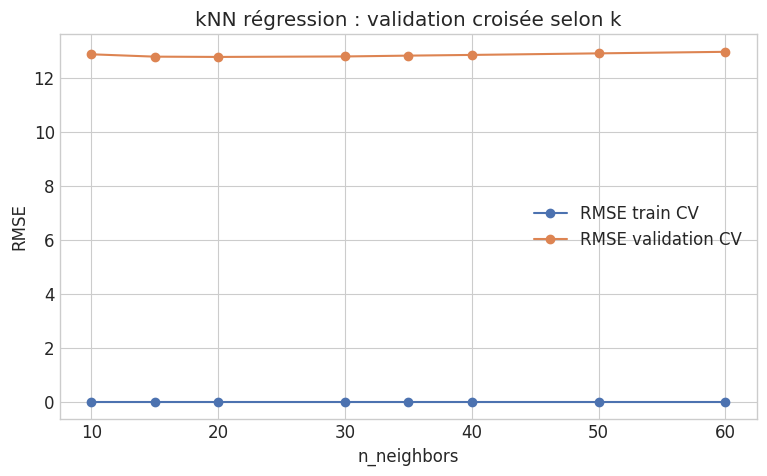

,k,RMSE train CV,RMSE validation CV
1,10,0.000001,12.876293
3,15,0.000002,12.789016
5,20,0.000003,12.778492
7,30,0.000004,12.796234
9,35,0.000004,12.826809
11,40,0.000005,12.853069
13,50,0.000006,12.911055
15,60,0.000007,12.968059


In [ ]:
knn_reg_results = pd.DataFrame(knn_reg_search.cv_results_)
knn_reg_curve = knn_reg_results[
    (knn_reg_results['param_weights'] == knn_reg_search.best_params_['weights'])
    & (knn_reg_results['param_metric'] == knn_reg_search.best_params_['metric'])
].sort_values('param_n_neighbors')

plt.figure(figsize=(9, 5))
plt.plot(
    knn_reg_curve['param_n_neighbors'].astype(int),
    -knn_reg_curve['mean_train_score'],
    marker='o',
    label='RMSE train CV',
)
plt.plot(
    knn_reg_curve['param_n_neighbors'].astype(int),
    -knn_reg_curve['mean_test_score'],
    marker='o',
    label='RMSE validation CV',
)
plt.xlabel('n_neighbors')
plt.ylabel('RMSE')
plt.title('kNN régression : validation croisée selon k')
plt.legend()
plt.show()

knn_reg_table = knn_reg_curve.assign(
    **{
        'RMSE train CV': -knn_reg_curve['mean_train_score'],
        'RMSE validation CV': -knn_reg_curve['mean_test_score'],
    }
)

knn_reg_table[['param_n_neighbors', 'RMSE train CV', 'RMSE validation CV']].rename(columns={
    'param_n_neighbors': 'k',
})

La lecture de cette courbe est similaire à celle du kNN de classification, mais l'axe vertical représente ici une erreur de prédiction : plus la RMSE est faible, meilleur est le modèle.

La RMSE de validation est minimale pour `k = 20`, mais les valeurs proches, notamment `k = 15` et `k = 30`, donnent des résultats très similaires. Le choix exact de `k` a donc un effet limité dans cette zone.

La RMSE train est presque nulle car le meilleur modèle utilise `weights='distance'` : chaque observation d'apprentissage est alors son propre plus proche voisin et reçoit un poids dominant. La courbe de validation est donc la plus informative pour juger de la généralisation.

On passe ensuite au SVR, qui repose aussi sur une notion de distance, mais avec une approche fondée sur les marges et la régularisation.

## 5. SVR

Le Support Vector Regression reprend les idées des SVM dans un cadre de régression. On cherche une fonction aussi régulière que possible, tout en tolérant des écarts inférieurs à `epsilon`.

Les hyperparamètres principaux sont :
- `C`, qui règle la pénalisation des écarts
- `epsilon`, qui fixe la largeur du tube d'insensibilité
- `kernel` et éventuellement `gamma`, qui contrôlent la forme de la non-linéarité.

La validation croisée complète sur tout l'échantillon serait coûteuse. On retient donc une stratégie raisonnable : CV sur un sous-échantillon d'apprentissage, puis réentraînement final sur l'échantillon complet.

In [ ]:
X_train_svr_sub, _, y_train_svr_sub, _ = train_test_split(
    X_train,
    y_train,
    train_size=4000,
    random_state=42,
)

scaler_svr = StandardScaler().fit(X_train_svr_sub)
X_train_svr_sub_scaled = scaler_svr.transform(X_train_svr_sub)
X_test_svr_scaled = scaler_svr.transform(X_test)

svr_search = GridSearchCV(
    SVR(),
    {
        'kernel': ['linear', 'rbf'],
        'C': [0.5, 1, 5],
        'epsilon': [1, 2],
        'gamma': ['scale', 0.1],
    },
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

start = time.perf_counter()
svr_search.fit(X_train_svr_sub_scaled, y_train_svr_sub)
svr_best_params = svr_search.best_params_
svr_time_search = time.perf_counter() - start

scaler_svr_full = StandardScaler().fit(X_train)
X_train_svr_scaled = scaler_svr_full.transform(X_train)
X_test_svr_scaled = scaler_svr_full.transform(X_test)

start = time.perf_counter()
svr_model = SVR(**svr_best_params)
svr_model.fit(X_train_svr_scaled, y_train)
svr_time_fit = time.perf_counter() - start

store_result(
    'SVR',
    svr_model,
    svr_time_search + svr_time_fit,
    X_train_svr_scaled,
    X_test_svr_scaled,
    category='SVR',
)

print('Meilleurs paramètres SVR :', svr_best_params)
print('RMSE CV (sous-échantillon) :', round(-svr_search.best_score_, 3))
print(regression_scores(svr_model, X_train_svr_scaled, X_test_svr_scaled))

Meilleurs paramètres SVR : {'C': 0.5, 'epsilon': 2, 'gamma': 'scale', 'kernel': 'linear'}
RMSE CV (sous-échantillon) : 10.14
{'RMSE train': 10.050933809859474, 'RMSE test': 9.796426522382214, 'MAE test': 7.738194384386809, 'R2 train': 0.6870118193486465, 'R2 test': 0.6937023284679877}


Le meilleur SVR retenu est un modèle linéaire avec `C = 0.5` et `epsilon = 2`. Le noyau RBF n'est donc pas sélectionné, ce qui confirme qu'une relation globalement linéaire suffit déjà assez bien pour prédire le LDL-cholestérol.

Les performances sont bonnes, avec une RMSE test d'environ 9.80 et un $R^2$ test proche de 0.694. Le SVR fait donc nettement mieux que le kNN de régression et se rapproche des meilleurs modèles linéaires. On examine maintenant les prédictions et les résidus pour vérifier visuellement la qualité de l'ajustement.

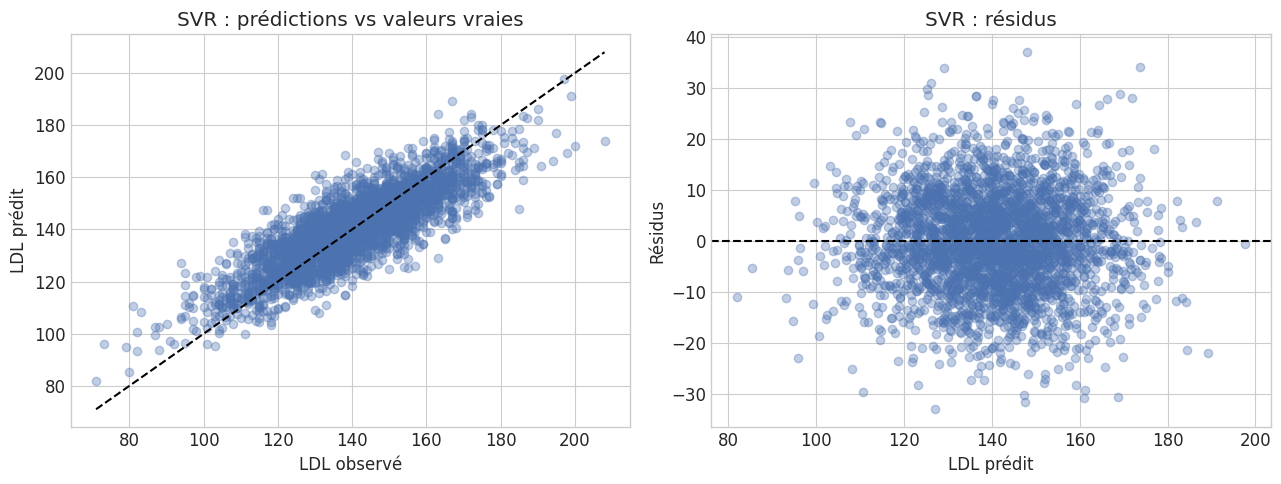

In [ ]:
svr_pred = svr_model.predict(X_test_svr_scaled)
svr_resid = y_test - svr_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, svr_pred, alpha=0.35)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', linestyle='--')
axes[0].set_title('SVR : prédictions vs valeurs vraies')
axes[0].set_xlabel('LDL observé')
axes[0].set_ylabel('LDL prédit')

axes[1].scatter(svr_pred, svr_resid, alpha=0.35)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('SVR : résidus')
axes[1].set_xlabel('LDL prédit')
axes[1].set_ylabel('Résidus')

plt.tight_layout()
plt.show()

Le nuage des prédictions montre une relation nette entre les valeurs observées et prédites, avec des points globalement proches de la diagonale. Le SVR capture donc bien la tendance principale du LDL-cholestérol.

Le graphique des résidus ne montre pas de structure très marquée : les erreurs sont globalement centrées autour de 0, même si la dispersion reste visible. Le SVR fournit donc un ajustement correct et stable. On passe maintenant aux réseaux de neurones, afin de tester un autre modèle non linéaire.

## 6. Réseau de neurones

On réalise maintenant une études avec des réseaux de neurones. On retient ici un MLPRegressor très simple.

L'objectif n'est pas de faire du deep learning, mais de disposer d'un autre modèle non linéaire de référence.

Meilleurs paramètres MLP : {'alpha': 0.01, 'hidden_layer_sizes': (40, 20)}
RMSE CV (sous-échantillon) : 11.13
{'RMSE train': 9.834089471758722, 'RMSE test': 10.22161350196904, 'MAE test': 8.072872647249943, 'R2 train': 0.700371291608568, 'R2 test': 0.6665373206431378}


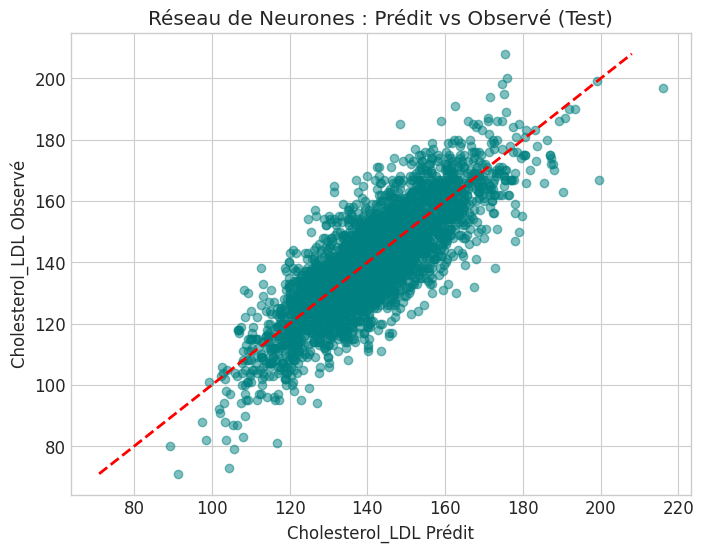

In [ ]:
X_train_mlp_sub, _, y_train_mlp_sub, _ = train_test_split(
    X_train,
    y_train,
    train_size=4000,
    random_state=42,
)

scaler_mlp = StandardScaler().fit(X_train_mlp_sub)
X_train_mlp_sub_scaled = scaler_mlp.transform(X_train_mlp_sub)
X_test_mlp_scaled = scaler_mlp.transform(X_test)

mlp_search = GridSearchCV(
    MLPRegressor(max_iter=500, random_state=42),
    {
        'hidden_layer_sizes': [(20,), (40,), (40, 20)],
        'alpha': [1e-4, 1e-3, 1e-2],
    },
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

start = time.perf_counter()
mlp_search.fit(X_train_mlp_sub_scaled, y_train_mlp_sub)
mlp_best_params = mlp_search.best_params_
mlp_time_search = time.perf_counter() - start

scaler_mlp_full = StandardScaler().fit(X_train)
X_train_mlp_scaled = scaler_mlp_full.transform(X_train)
X_test_mlp_scaled = scaler_mlp_full.transform(X_test)

start = time.perf_counter()
mlp_model = MLPRegressor(max_iter=500, random_state=42, **mlp_best_params)
mlp_model.fit(X_train_mlp_scaled, y_train)
mlp_time_fit = time.perf_counter() - start

store_result(
    'Réseau de neurones (MLP)',
    mlp_model,
    mlp_time_search + mlp_time_fit,
    X_train_mlp_scaled,
    X_test_mlp_scaled,
    category='Réseau de neurones',
)

print('Meilleurs paramètres MLP :', mlp_best_params)
print('RMSE CV (sous-échantillon) :', round(-mlp_search.best_score_, 3))
print(regression_scores(mlp_model, X_train_mlp_scaled, X_test_mlp_scaled))

Y_pred_cholest = mlp_model.predict(X_test_mlp_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(Y_pred_cholest, y_test, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Cholesterol_LDL Prédit")
plt.ylabel("Cholesterol_LDL Observé")
plt.title("Réseau de Neurones : Prédit vs Observé (Test)")
plt.show()

Le meilleur MLP retenu utilise deux couches cachées `(40, 20)` avec une pénalisation `alpha = 0.01`. Ses performances restent correctes, avec une RMSE test d'environ 10.22 et un $R^2$ test proche de 0.667.

Le nuage prédit-observé montre que le réseau capte bien la tendance générale du LDL-cholestérol, mais la dispersion reste plus importante que pour les meilleurs modèles. Le réseau de neurones ne dépasse donc pas les modèles linéaires ou le SVR dans cette tâche.

On peut maintenant comparer globalement tous les modèles de régression entraînés.

## 7. Comparaison globale des modèles

On rassemble maintenant l'ensemble des modèles optimisés sur l'échantillon de test. La comparaison porte à la fois sur la précision, la stabilité implicite via l'écart train/test, le coût d'entraînement et l'interprétabilité.

In [ ]:
comparison_df = pd.DataFrame(results).T.sort_values('RMSE test')
comparison_df

,Modèle,Famille,RMSE train,RMSE test,MAE test,R2 train,R2 test,Temps entraînement (s)
Lasso,Lasso,Linéaire pénalisé,10.051,9.782,7.718,0.687,0.6946,0.13
Régression linéaire complète,Régression linéaire complète,Linéaire,10.047,9.788,7.728,0.6872,0.6942,0.029
Ridge,Ridge,Linéaire pénalisé,10.047,9.788,7.729,0.6872,0.6943,0.38
Régression linéaire sélectionnée,Régression linéaire sélectionnée,Linéaire,10.049,9.79,7.726,0.6871,0.6941,0.508
SVR,SVR,SVR,10.051,9.796,7.738,0.687,0.6937,7.706
Gradient Boosting,Gradient Boosting,Boosting,10.009,9.822,7.757,0.6896,0.6921,24.641
Random Forest,Random Forest,Agrégation,9.264,9.874,7.807,0.7341,0.6888,43.44
CART régression,CART régression,Arbre,10.01,9.901,7.819,0.6895,0.6871,1.643
AdaBoost,AdaBoost,Boosting,10.095,9.905,7.82,0.6843,0.6869,28.234
Bagging,Bagging,Agrégation,9.002,9.908,7.833,0.7489,0.6867,57.972


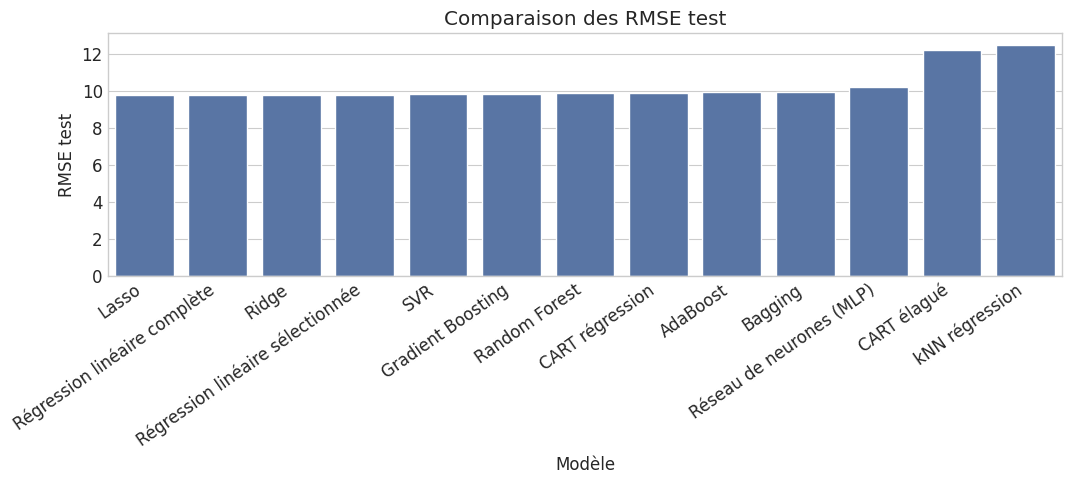

In [ ]:
plt.figure(figsize=(11, 5))
sns.barplot(data=comparison_df.reset_index(drop=True), x='Modèle', y='RMSE test')
plt.title('Comparaison des RMSE test')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

Les modèles de régression donnent des performances proches pour la plupart des approches, mais les meilleurs résultats sont obtenus par les modèles linéaires. Le meilleur RMSE test est obtenu par le Lasso, avec 9.782, suivi de très près par la régression linéaire complète, Ridge, la régression linéaire sélectionnée et le SVR. Les écarts entre ces modèles sont très faibles, ce qui indique qu'ils capturent pratiquement la même information prédictive.

Les meilleurs modèles atteignent une RMSE test d'environ 9.8, une MAE autour de 7.7 et un $R^2$ test proche de 0.69. Ils expliquent donc environ 69 % de la variabilité du LDL-cholestérol sur l'échantillon test. À l'inverse, le kNN de régression et le CART élagué sont nettement moins performants, ce qui montre que des approches trop locales ou trop instables ne sont pas adaptées ici.

Au final, sous contrainte d'interprétabilité, le meilleur compromis est le Lasso ou la régression linéaire sélectionnée. Le Lasso obtient le meilleur RMSE test tout en simplifiant le modèle, tandis que la régression sélectionnée conserve seulement quelques variables avec une performance presque identique. La conclusion principale est donc que, pour prédire `Cholesterol_LDL`, un modèle linéaire parcimonieux suffit largement.

### Lien avec l'analyse exploratoire

Les résultats de modélisation confirment de manière convergente les conclusions de l'analyse exploratoire. La régression de LDL est dominée par `Cholesterol_Total`, comme prévu par la corrélation 0.83 identifiée en 3.1.1.

Tous les modèles parcimonieux pointent dans la même direction :
- La sélection backward BIC ne retient qu'une seule variable : `Cholesterol_Total`. L'AIC, moins strict, conserve aussi `Systolic_BP`.
- Le Lasso ne garde que 4 coefficients non nuls : `Cholesterol_Total`, `Age`, `Systolic_BP` et `Family_History_1`.
- Les importances de la Random Forest et du Gradient Boosting attribuent à `Cholesterol_Total` environ 99 % de l'importance totale, les autres variables n'apparaissant qu'à la marge.

Les prédictions de l'exploratoire sont validées : `Stress_Level`, `Sleep_Hours` et `Height_cm` ne contribuent jamais aux modèles, et la plupart des variables qualitatives sont éliminées par la sélection ou la pénalisation. La relation entre `Cholesterol_LDL` et ses prédicteurs est essentiellement linéaire et concentrée sur `Cholesterol_Total`, ce qui explique pourquoi les modèles non linéaires (forêts, boosting, MLP) n'apportent aucun gain net.
Ces observations étaient prévisibles car `Cholesterol_Total`=`Cholesterol_LDL`+`Cholesterol_HDL`

# III : Conclusion générale

Cette étude avait deux objectifs complémentaires : prédire le risque d'accident cardiaque (`Heart_Disease_Risk`) et prédire le taux de LDL-cholestérol (`Cholesterol_LDL`). Dans les deux cas, la démarche suivie a été la même : séparation apprentissage/test, préparation des variables, optimisation des hyperparamètres par validation croisée, puis comparaison finale sur l'échantillon test.

Pour la classification du risque cardiaque, les performances restent assez proches entre les modèles. Les méthodes non linéaires, comme les arbres, le bagging, la random forest, le boosting ou les réseaux de neurones, améliorent parfois légèrement les résultats, mais sans produire de rupture nette. Les meilleurs modèles atteignent une accuracy autour de 0.73 et une AUC proche de 0.80. Cela suggère que le risque cardiaque est bien multifactoriel : plusieurs variables contribuent à la prédiction, mais aucune méthode ne parvient à séparer parfaitement les deux classes.

Sous contrainte de performance pure, les modèles comme le réseau de neurones, le boosting ou le SVM donnent de bons résultats. En revanche, si l'on ajoute une contrainte d'interprétabilité, les modèles pénalisés de type Ridge, Lasso ou Elastic Net restent très intéressants : ils offrent des performances comparables tout en permettant de mieux comprendre le rôle des variables. Les résultats des arbres confirment aussi l'importance de facteurs comme le tabagisme, les antécédents familiaux, la pression artérielle et certaines variables métaboliques.

Pour la régression du LDL-cholestérol, la conclusion est plus nette. Les meilleurs modèles sont les modèles linéaires, en particulier le Lasso, la régression linéaire complète, Ridge et la régression sélectionnée. Le SVR linéaire obtient également des performances très proches. Les modèles plus complexes n'apportent pas de gain significatif. Ce résultat est cohérent avec l'analyse exploratoire : `Cholesterol_Total` porte une grande partie de l'information utile pour prédire `Cholesterol_LDL`, et la relation semble principalement linéaire.

Les meilleurs modèles de régression atteignent une RMSE test d'environ 9.8, une MAE autour de 7.7 et un $R^2$ proche de 0.69. On explique donc environ 69 % de la variabilité du LDL-cholestérol sur l'échantillon test. Dans ce cadre, un modèle linéaire parcimonieux, comme le Lasso ou la régression sélectionnée, constitue le meilleur compromis entre précision, simplicité et interprétabilité.

Au final, cette étude montre que la complexité algorithmique n'est pas toujours synonyme de meilleure performance. Pour la classification, les modèles complexes apportent parfois un léger gain mais restent proches des modèles interprétables. Pour la régression, les modèles simples dominent clairement. Le choix final du modèle dépend donc autant de la performance que de l'objectif pratique : prédire au mieux, comprendre les facteurs de risque, ou construire un modèle explicable et utilisable.